
# Exploratory Data Analysis (EDA)

## Project
Predicting Student Dropout Risk in Online Learning Platforms

## Objective
The objective of this Exploratory Data Analysis (EDA) is to understand the Open University Learning Analytics Dataset (OULAD), assess data quality, identify patterns associated with student engagement and performance, and discover relationships that may influence student dropout. The insights obtained from this analysis will guide data preprocessing, feature engineering, and predictive model development.

In [414]:
%pip install pandas numpy matplotlib seaborn kagglehub

Note: you may need to restart the kernel to use updated packages.


In [415]:
#Import Libraries
import kagglehub
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

### Download Dataset

In [416]:
path = kagglehub.dataset_download(
    "anlgrbz/student-demographics-online-education-dataoulad"
)

print("Path to dataset:", path)

Path to dataset: C:\Users\jaypr\.cache\kagglehub\datasets\anlgrbz\student-demographics-online-education-dataoulad\versions\1


### Loading the DataSet: Read CSV Files

Each file stores different information.

DataFrame	Information
df_students	Student demographics & final result
df_studentAssessment	Assessment marks
df_assessments	Assessment details
df_studentRegistration	Registration & withdrawal
df_studentVle	Student clickstream
df_vle	Learning resources
df_courses	Course information

Later, these datasets will be joined using keys such as

id_student
id_assessment
code_module
code_presentation


In [417]:
df_assessments = pd.read_csv(path + '\\assessments.csv') #assessments-Assessment details
df_assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [418]:
print(df_assessments.shape) 
print(df_assessments.info()) 

(206, 6)
<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.8 KB
None


In [419]:
df_courses = pd.read_csv(path + '\\courses.csv') #courses-Course information
df_courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [420]:
print(df_courses.shape) 
print(df_courses.info()) 

(22, 3)
<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 660.0 bytes
None


In [421]:
df_studentAssessments = pd.read_csv(path + '\\studentAssessment.csv') #studentAssessment-Student marks
df_studentAssessments.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [422]:
print(df_studentAssessments.shape)
print(df_studentAssessments.info())

(173912, 5)
<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB
None


In [423]:
df_students = pd.read_csv(path + '\\studentInfo.csv') #Student demographics & final result
df_students.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [424]:
print(df_students.shape)
print(df_students.info())

(32593, 12)
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB
None


In [425]:
df_studentRegistration = pd.read_csv(path + '\\studentRegistration.csv') #Registration & withdrawal
df_studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [426]:
print(df_studentRegistration.shape)
print(df_studentRegistration.info())

(32593, 5)
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB
None


In [427]:
df_studentVle = pd.read_csv(path + '\\studentVle.csv') #Clickstream activity
df_studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [428]:
print(df_studentVle.shape)
print(df_studentVle.info())

(10655280, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 487.8 MB
None


In [429]:
df_vle = pd.read_csv(path + '\\vle.csv') #Learning resource details
df_vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [430]:
print(df_vle.shape)
print(df_vle.info())

(6364, 6)
<class 'pandas.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   str    
 2   code_presentation  6364 non-null   str    
 3   activity_type      6364 non-null   str    
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 298.4 KB
None


In [431]:
print("="*60)
print("Dataset Shapes")
print("="*60)

print("Assessments:", df_assessments.shape)
print("Courses:", df_courses.shape)
print("Student Assessment:", df_studentAssessments.shape)
print("Student Info:", df_students.shape)
print("Student Registration:", df_studentRegistration.shape)
print("Student VLE:", df_studentVle.shape)
print("VLE:", df_vle.shape)

Dataset Shapes
Assessments: (206, 6)
Courses: (22, 3)
Student Assessment: (173912, 5)
Student Info: (32593, 12)
Student Registration: (32593, 5)
Student VLE: (10655280, 6)
VLE: (6364, 6)


### Data Quality Assessment
Objective

Before building any Machine Learning model, we ask these questions:

How big is each dataset?
What columns are available?
What is the data type of each column?
Are there missing values?
Are there duplicate rows?
Is the dataset ready for analysis?

Instead of writing the same code for all 7 datasets, we created a helper function.

Why we check shape
Why data types matter for machine learning
Why we look for missing values
Why duplicates can affect model performance
How to interpret the actual OULAD outputs (e.g., why studentVle has over 10 million rows and why date_unregistration contains many missing values).

Overall Purpose of this Function

This function answers five questions for every dataset.

Question:	
Why it matters
How big is the dataset?	Shape
What information does it contain?	Columns
What type of data is present?	Data types
Is any data missing?	Null values
Is any data duplicated?	Duplicate rows

This is exactly the objective of the Data Understanding phase in EDA.

In [432]:
# Define a helper to summarize each dataframe

def summarize_df(df, name):
    print(f"=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("dtypes:")
    print(df.dtypes)
    print("\nUnique Values:")
    print(df.nunique())
    print("\nMemory Usage:") #Added By Kiran
    print(f"{df.memory_usage(deep=True).sum()/1024**2:.2f} MB") #Added By Kiran
    print("\nnull counts:")
    print(df.isna().sum().sort_values(ascending=False).head(30))
    print("\nMissing Percentage (%):") #Added By Kiran
    missing_percent = (df.isna().sum() / len(df)) * 100 #Added By Kiran
    print(missing_percent.sort_values(ascending=False).round(2).head(30)) #Added By Kiran
    print("duplicate rows:", df.duplicated().sum())
    print("\n")

for name, df in [
    ("assessments", df_assessments),
    ("courses", df_courses),
    ("studentAssessment", df_studentAssessments),
    ("studentInfo", df_students),
    ("studentRegistration", df_studentRegistration),
    ("studentVle", df_studentVle),
    ("vle", df_vle),
]:
    summarize_df(df, name)

=== assessments ===
shape: (206, 6)
columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
dtypes:
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

Unique Values:
code_module            7
code_presentation      4
id_assessment        206
assessment_type        3
date                  74
weight                24
dtype: int64

Memory Usage:
0.04 MB

null counts:
date                 11
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
weight                0
dtype: int64

Missing Percentage (%):
date                 5.34
code_module          0.00
code_presentation    0.00
id_assessment        0.00
assessment_type      0.00
weight               0.00
dtype: float64
duplicate rows: 0


=== courses ===
shape: (22, 3)
columns: ['code_module', 'code_presentation', 'm

### Assessments Analysis

In this section we are analyzin assessments.csv in depth—not just explain the code, but answer questions like:

What is a TMA, CMA, and Exam?
Why do some assessments have 0% weight?
Why are assessment weights important for predicting dropout?
How should we interpret the histograms and count plots

This is where we begin extracting insights from the data rather than just checking its quality.

## Objective

The file assessments.csv contains information about every assessment (assignment, coursework, exam) offered in each course.

Before predicting whether a student will drop out, we need to understand:

How many assessments does each course have?
What types of assessments exist?
How much does each assessment contribute to the final grade?
When are assessments conducted?
Are there any missing values?

These questions are important because assessment workload and performance strongly influence student engagement and dropout risk.

Step 1 – Display First Five Rows: df_assessments.head()

Output

code_module	code_presentation	id_assessment	assessment_type	date	weight
AAA	2013J	1752	TMA	19	10
AAA	2013J	1753	TMA	54	20
AAA	2013J	1754	TMA	117	20
AAA	2013J	1755	TMA	166	20
AAA	2013J	1756	TMA	215	30

Understanding Every Column
1. code_module

Example
AAA
BBB
CCC
DDD

Think of this as the Course ID.Instead of writing 'Machine Learning',they simply use 'AAA'. Every course has a unique code.

2. code_presentation

Example
2013J
2014B
2014J

Means Course offering:

2013 = Year
J = January presentation
B = February presentation (presentation code used by Open University)

One course can be offered multiple times.

3. id_assessment

Example
1752
1753
1754
Every assessment has its own unique ID.

Later, 'studentAssessment.csv' uses this same ID.That's how we connect

Assessment

↓

Student Score

4. assessment_type

Example
TMA
CMA
Exam

TMA: Tutor Marked Assignment.Normal assignment.Submitted during the course.Usually contributes to the final grade.

CMA:Computer Marked Assessment.Automatically graded.Usually MCQs,Programming quizzes,Online quizzes

Exam:Final examination.Usually has the highest importance.

## Why is this important?

Later,we'll compare

Average Score

↓

Assessment Type

Maybe Students perform poorly in Exams or TMAs

That becomes a useful feature.

5. Date

Example
19
54
117

This is NOT Calendar date.It means Days from course start.

Example

19

↓

Assessment is due 19 days after the course begins.

## Why is date important?

Students who stop submitting assessments early are often at high risk of dropping out.

6. Weight

Example
10
20
30
100

Weight means Contribution towards Final Grade.

Example: Suppose Assignment 1,Weight = 20

Assignment 2,Weight = 30

Exam,Weight = 50

Total=100%




# Assessments analysis
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

Assessment Type Percentage
assessment_type
TMA     51.46
CMA     36.89
Exam    11.65
Name: proportion, dtype: float64
count    206.000000
mean      20.873786
std       30.384224
min        0.000000
25%        0.000000
50%       12.500000
75%       24.250000
max      100.000000
Name: weight, dtype: float64

Average Weight by Assessment Type
                 count    mean  median    min    max
assessment_type                    

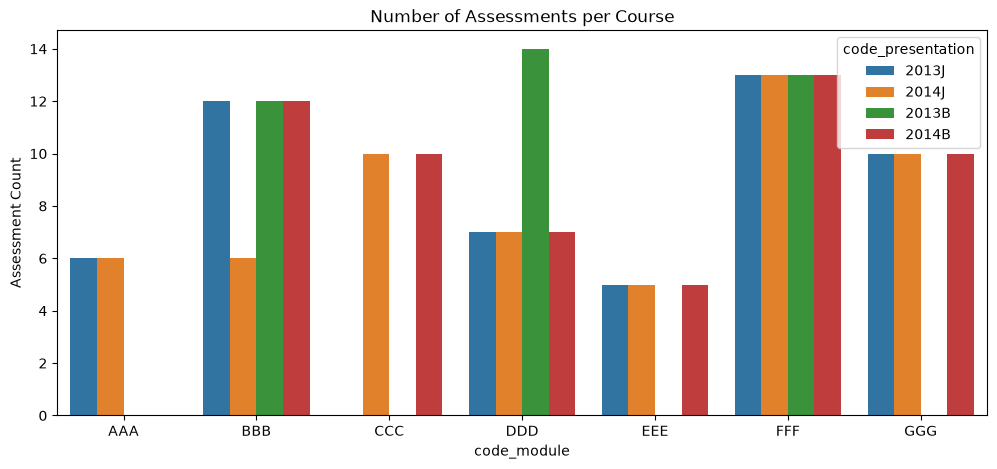

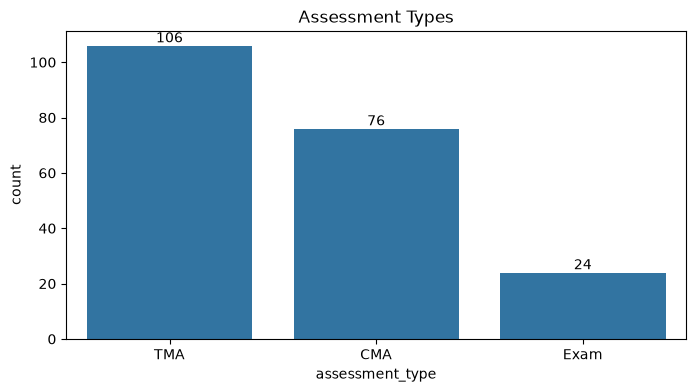

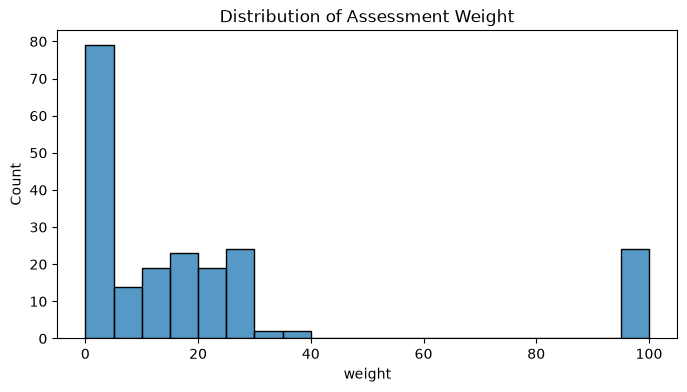

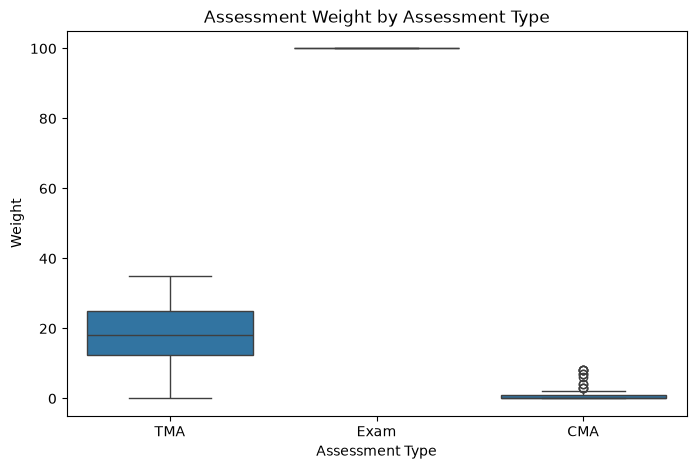

In [433]:
# Assessments analysis
print("# Assessments analysis")
print(df_assessments.head())
print(df_assessments['assessment_type'].value_counts())
print("\nAssessment Type Percentage") #Added By Kiran
print(
    round(
        df_assessments['assessment_type']
        .value_counts(normalize=True) * 100,
        2
    )
)#Added By Kiran
print(df_assessments['weight'].describe())
print("\nAverage Weight by Assessment Type") #Added By Kiran
print(
    df_assessments.groupby("assessment_type")["weight"]
                  .agg(["count", "mean", "median", "min", "max"])
                  .round(2)
) #Added By Kiran
print('missing dates:', df_assessments['date'].isna().sum())
missing = df_assessments["date"].isna().mean() * 100 #Added By Kiran
print(f"Missing Date Percentage : {missing:.2f}%") #Added By Kiran
print(df_assessments.groupby(['code_module', 'code_presentation'])['id_assessment'].nunique().sort_values(ascending=False).head(20))
#Added By Kiran
assessment_counts = (
    df_assessments
    .groupby(["code_module","code_presentation"])
    ["id_assessment"]
    .count()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=assessment_counts,
    x="code_module",
    y="id_assessment",
    hue="code_presentation"
)

plt.title("Number of Assessments per Course")
plt.ylabel("Assessment Count")
plt.show()
#######
plt.figure(figsize=(8, 4))
sns.countplot(data=df_assessments, x='assessment_type', order=df_assessments['assessment_type'].value_counts().index)
for container in plt.gca().containers: #Added By Kiran
    plt.bar_label(container)
df_assessments.groupby("assessment_type")["weight"].mean()
plt.title('Assessment Types')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_assessments['weight'].dropna().astype(float), bins=20, kde=False)
plt.title('Distribution of Assessment Weight')
plt.xlabel('weight')
plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_assessments,
    x="assessment_type",
    y="weight"
)

plt.title("Assessment Weight by Assessment Type")
plt.xlabel("Assessment Type")
plt.ylabel("Weight")
plt.show()

### Conclusion from Assessment Analysis:
The assessment analysis shows that the OULAD courses primarily rely on continuous assessment through Tutor Marked Assignments, while final examinations carry the highest individual weight. Assessment workload varies across course presentations, and most assessment dates are available for analysis. These characteristics provide valuable contextual information about course design and evaluation structure. When combined with student performance data in later stages, assessment type, timing, and weight may help identify patterns associated with student engagement and dropout risk.

### Courses Dataset Analysis
The courses.csv file stores course-level information, not student-level information.

Each row represents one course presentation.

Example:

code_module	code_presentation	module_presentation_length
AAA	2013J	268
BBB	2014B	240

Notice there is:

No student ID
No assessment score
No clickstream

It simply tells us:

Which course is being offered
Which presentation (semester)
How long the course runs

Later, this table is merged with student information using:

code_module & code_presentation

# Courses analysis
  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268
3         BBB             2014J                         262
4         BBB             2013B                         240
       code_module code_presentation  module_presentation_length
count           22                22                   22.000000
unique           7                 4                         NaN
top            BBB             2014J                         NaN
freq             4                 7                         NaN
mean           NaN               NaN                  255.545455
std            NaN               NaN                   13.654677
min            NaN               NaN                  234.000000
25%            NaN               NaN                  241.000000
50%            NaN               NaN

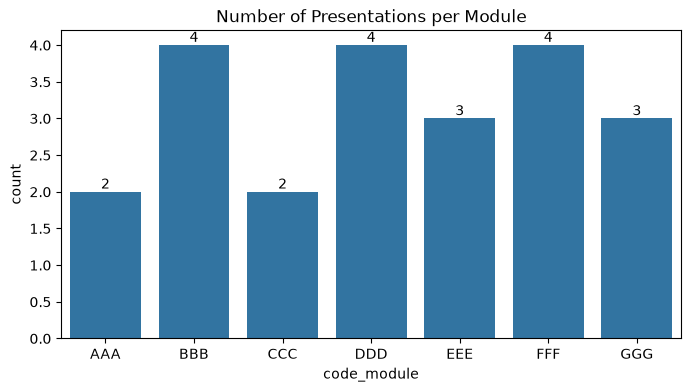

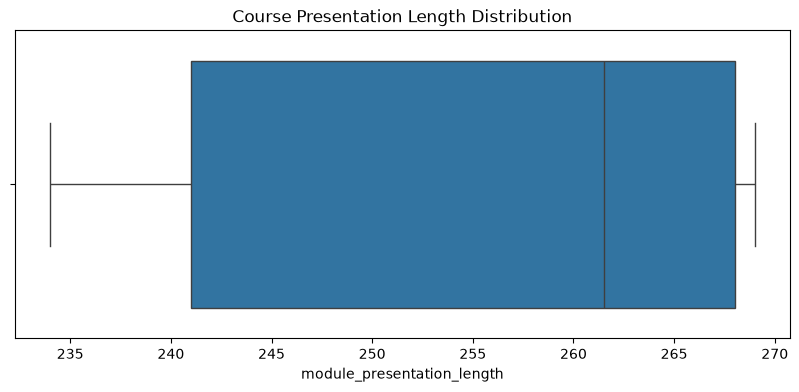

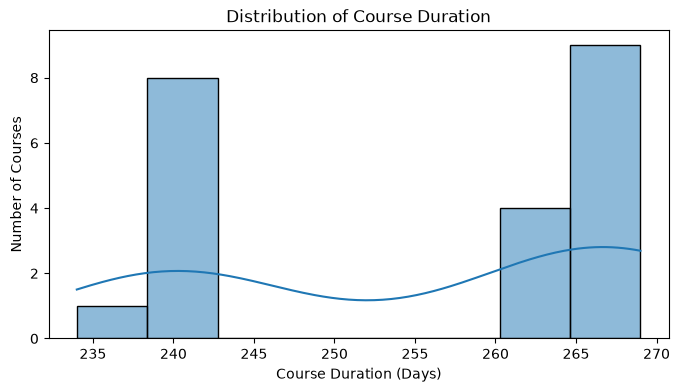

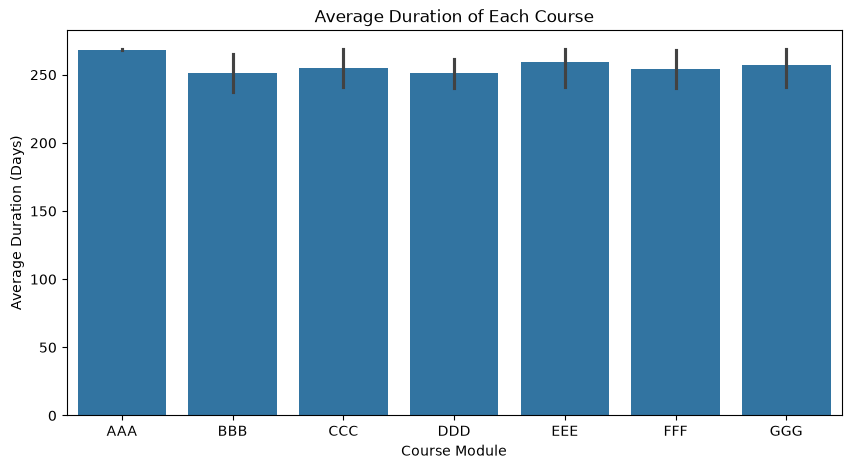

In [434]:
# Courses analysis
print("# Courses analysis")
print(df_courses.head())
print(df_courses.describe(include='all'))
print('unique module/presentation combos:', df_courses.groupby(['code_module', 'code_presentation']).size().shape[0])
print(df_courses.groupby('code_module')['module_presentation_length'].describe())

#Added By Kiran
print("\nPresentations per Module")

print(
    df_courses["code_module"]
              .value_counts()
) 

plt.figure(figsize=(8,4))

sns.countplot(
    data=df_courses,
    x="code_module"
)

plt.title("Number of Presentations per Module")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()
#Added By Kiran
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_courses, x='module_presentation_length')
plt.title('Course Presentation Length Distribution')
plt.show()

#Added By Kiran
plt.figure(figsize=(8,4))

sns.histplot(
    df_courses["module_presentation_length"],
    bins=8,
    kde=True
)

plt.title("Distribution of Course Duration")
plt.xlabel("Course Duration (Days)")
plt.ylabel("Number of Courses")
plt.show()

#Comparing Modules-Added By Kiran
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_courses,
    x="code_module",
    y="module_presentation_length",
    estimator="mean"
)

plt.title("Average Duration of Each Course")
plt.xlabel("Course Module")
plt.ylabel("Average Duration (Days)")
plt.show()


### Conclusion from Course Analysis:

Course duration ranges from 234 to 269 days with relatively small variation across modules.

Since longer courses may require sustained engagement, module duration could later be explored as a potential predictor of student dropout after merging with student-level data.

### Student Information Dataset Analysis
StudentInfo dataset contains one row per student per course presentation.

id_student	gender	age_band	highest_education	imd_band	disability	final_result
11391	M	35-55	HE Qualification	80-90%	N	Pass

This dataset contains:

Student demographics
Education background
Socioeconomic status
Disability status
Final course outcome

This is the dataset that will later become our main ML dataset.

This dataset important because almost every feature here can influence dropout.

For example,
Feature	Can affect dropout?
Age	Yes
Gender	Possibly
Education	Yes
Region	Possibly
IMD Band	Yes
Disability	Yes
Credits Studied	Yes
Final Result- Target Variable

# Student info analysis
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60  

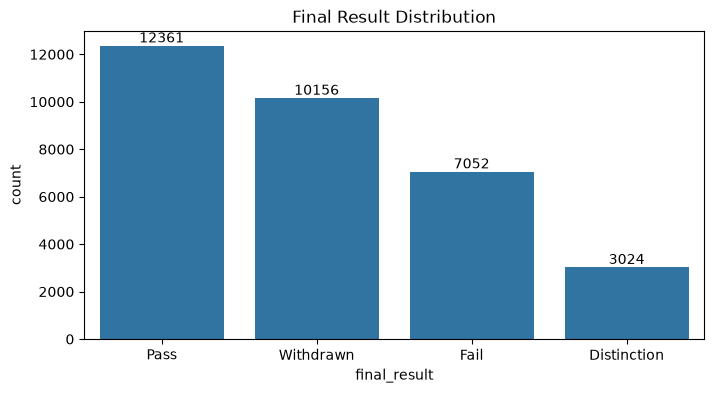

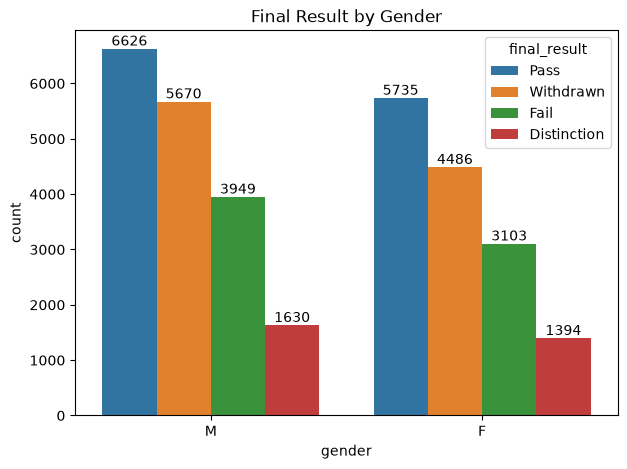

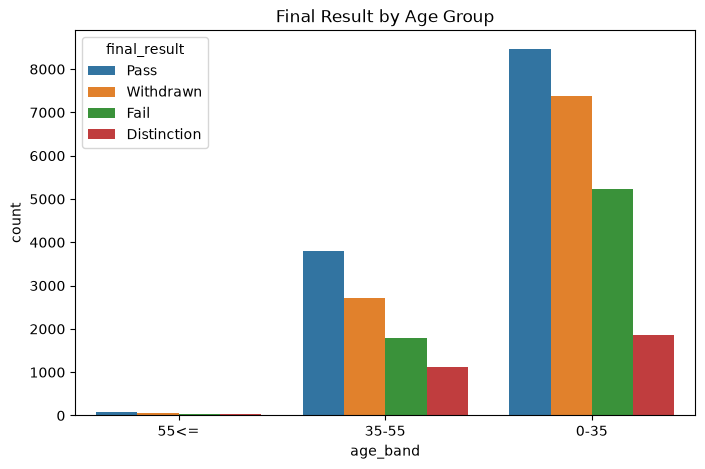

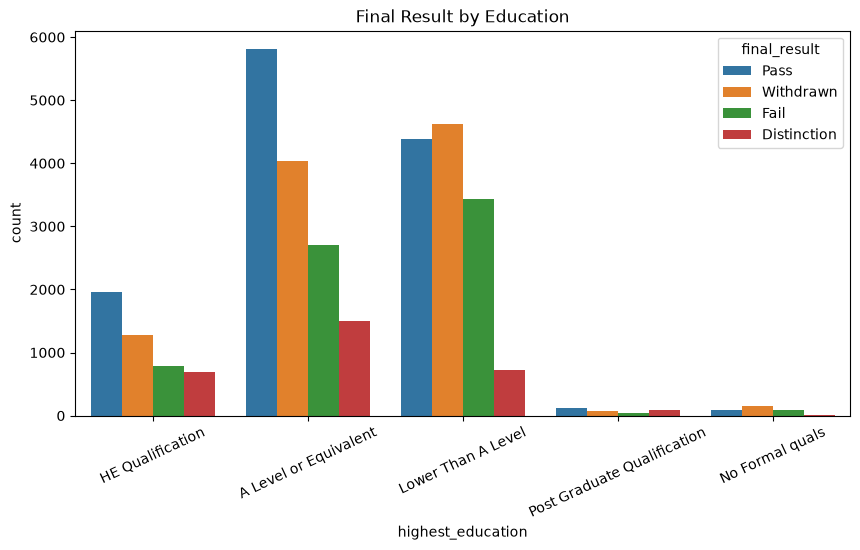

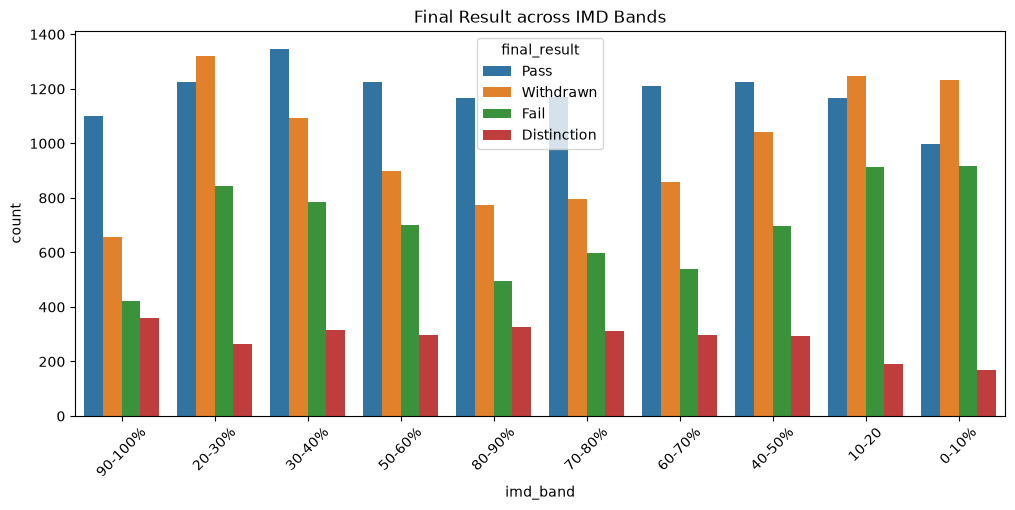

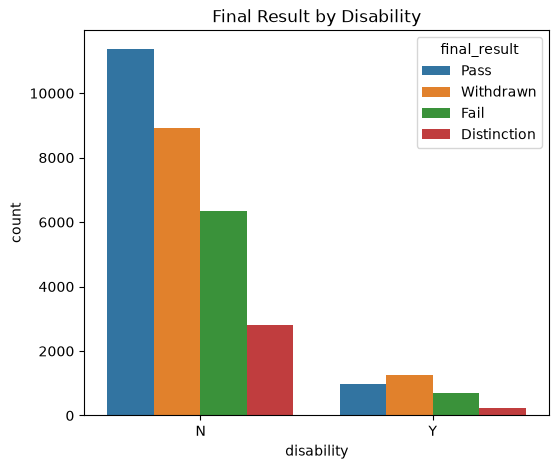

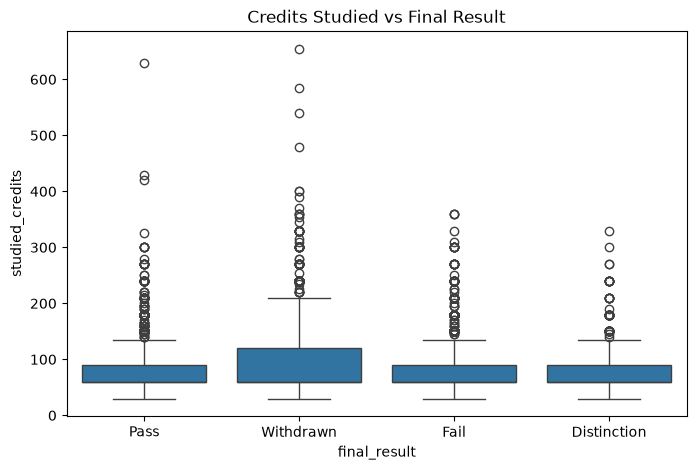

In [435]:
# Student info analysis
print("# Student info analysis")
print(df_students.head())
print('final result counts:')
print(df_students['final_result'].value_counts(dropna=False))
for col in ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability']:
    if col in df_students.columns:
        print(f'--- {col} ---')
        print(df_students[col].value_counts(dropna=False).head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=df_students, x='final_result', order=df_students['final_result'].value_counts().index)
for container in plt.gca().containers:
    plt.bar_label(container)
print("\nFinal Result Percentage")

print(
    round(
        df_students["final_result"]
        .value_counts(normalize=True)*100,
        2
    )
)
plt.title('Final Result Distribution')
plt.show()

#Gender Countplot: Added By Kiran
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_students,
    x="gender",
    hue="final_result"
)

plt.title("Final Result by Gender")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

#Age Band Plot: : Added By Kiran
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_students,
    x="age_band",
    hue="final_result"
)

plt.title("Final Result by Age Group")

plt.show()

#Education Countplot-Added By Kiran
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_students,
    x="highest_education",
    hue="final_result"
)

plt.xticks(rotation=25)
plt.title("Final Result by Education")
plt.show()

#IMD Band:Index of Multiple Deprivation-It represents Socioeconomic status.
plt.figure(figsize=(12,5))

sns.countplot(
    data=df_students,
    x="imd_band",
    hue="final_result"
)

plt.xticks(rotation=45)
plt.title("Final Result across IMD Bands")
plt.show()

#Disability
plt.figure(figsize=(6,5))

sns.countplot(
    data=df_students,
    x="disability",
    hue="final_result"
)

plt.title("Final Result by Disability")
plt.show()

#Studied Credits Histogram
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_students,
    x="final_result",
    y="studied_credits"
)

plt.title("Credits Studied vs Final Result")

plt.show()

# Student Info Analysis Conclusion:
The studentInfo.csv dataset contains demographic, educational, and academic information for 32,593 student-course enrollments. It includes variables such as gender, age, education level, socioeconomic status (IMD band), disability, previous attempts, studied credits, and the final course outcome. These variables form the foundation for predicting student success and dropout.

## Final Result Distribution
Pass         37.93%
Withdrawn    31.16%
Fail         21.64%
Distinction   9.28%
### Conclusion
Pass is the most common outcome (37.93%).
A substantial proportion (31.16%) of students withdrew before completing the course.
Around 21.64% failed, while only 9.28% achieved a distinction.

Nearly one-third of students withdrew.

## Gender Analysis
Male:   17,875
Female: 14,718
### Conclusion
Male students slightly outnumber female students.
The distribution of Pass, Fail, Withdrawn, and Distinction appears broadly similar across genders.

Gender alone does not appear to strongly differentiate academic outcomes. However, it may still contribute as one of several features in the predictive model when combined with other variables.

## Age Band Analysis
0–35 : 22,944
35–55: 9,433
55+  :   216
### Conclusion
Most students belong to the 0–35 years age group.
Very few students are older than 55 years.
The outcome distribution varies across age groups, suggesting that age may influence learning behaviour and course completion.

Age may capture differences in experience, responsibilities, or study habits, making it a potentially useful predictor of student dropout.

## Highest Education
A Level                14,045
Lower Than A Level     13,158
HE Qualification        4,730
### Conclusion
Most students entered the courses with either A Level or Equivalent or Lower Than A Level qualifications, while relatively few had higher education or postgraduate qualifications.

The distribution of final results suggests that educational background may influence dropout.

Students entering with stronger educational backgrounds may be better prepared for course requirements, making education level an informative feature for dropout prediction.

## IMD Band (Socioeconomic Status)
Missing: 1111
### Conclusion
Students are fairly evenly distributed across socioeconomic groups, with only 3.4% missing values.

The variation in final results across IMD bands suggests that socioeconomic status may influence academic outcomes and student dropout.
Socioeconomic status has been shown in educational research to affect access to resources and learning opportunities. It is therefore a valuable feature to retain for predictive modelling.

## Previous Attempts
0 previous attempts : 28,421
### Conclusion
Most students are attempting the course for the first time, while relatively few have repeated the course.

Students with previous unsuccessful attempts may exhibit different learning behaviours and academic outcomes compared with first-time learners. Previous attempts could therefore improve the predictive performance of the model.

## Studied Credits
60 credits : 16,751
### Conclusion
The majority of students are enrolled in 60-credit modules, while larger credit loads are much less common.
The boxplot indicates that students with different final outcomes may have different credit loads, suggesting that course workload could influence academic performance and dropout.

Higher study loads may increase academic pressure, whereas lighter loads may allow students to balance their studies more effectively. Studied credits may therefore contribute to dropout prediction.

## Disability
No disability : 29,429
Disability    : 3,164
### Conclusion
Most students reported no disability, with approximately 10% indicating a disability.

The countplot shows differences in the distribution of final results between the two groups, although the imbalance in group sizes should be considered when interpreting the results.

Disability status may influence the support required by students and could contribute additional predictive information when combined with other demographic and behavioural variables.

### Overall Student Information Analysis:
The student information analysis shows that the dataset contains a diverse population of learners with varying demographic, educational, and socioeconomic backgrounds. Approximately one-third of students withdrew from their courses, highlighting the importance of predicting dropout. Variables such as age, education level, socioeconomic status, previous attempts, studied credits, and disability exhibit meaningful variation across student outcomes and may serve as useful predictors in the machine learning model. While demographic variables alone may not fully explain academic success, combining them with behavioural data such as assessment performance and VLE engagement is expected to improve dropout prediction.

# Bivariate Analysis

For a predictive modeling project, we should analyze each feature against the target variable (final_result).

Instead of:

Gender distribution
Age distribution
Education distribution

We should ask:

Does gender influence outcomes?
Does age influence outcomes?
Does education influence outcomes?
Does socioeconomic status influence outcomes?
Does disability status influence outcomes?

This is called bivariate analysis, and it's much more valuable than univariate analysis because it starts uncovering relationships that the machine learning model may later learn.

## Gender vs Final Result

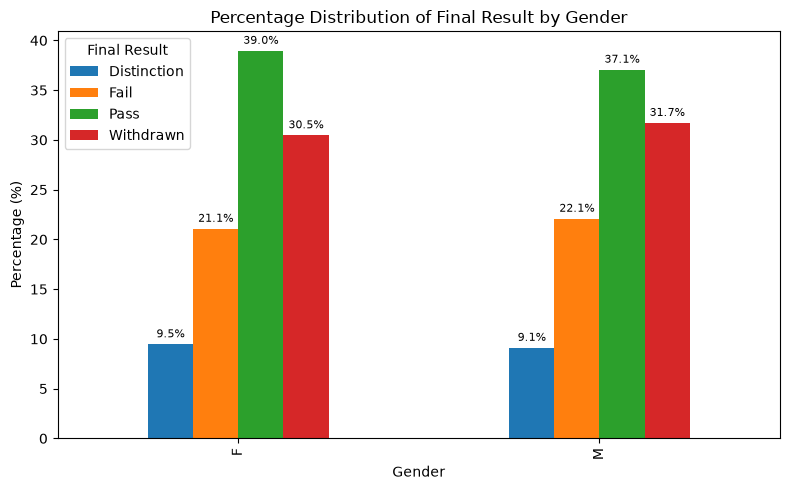

In [436]:
# Gender vs Final Result
# ==========================================================
gender_pct = pd.crosstab(
    df_students['gender'],
    df_students['final_result'],
    normalize='index'
) * 100

# Create grouped bar chart
ax = gender_pct.plot(
    kind='bar',
    figsize=(8,5)
)

# ===== Added: Display percentage labels on bars =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",      # Show one decimal place with %
        fontsize=8,
        padding=3
    )

# Formatting
plt.ylabel("Percentage (%)")
plt.xlabel("Gender")
plt.title("Percentage Distribution of Final Result by Gender")
plt.legend(title="Final Result")
plt.tight_layout()

plt.show()

2. Age vs Final Result

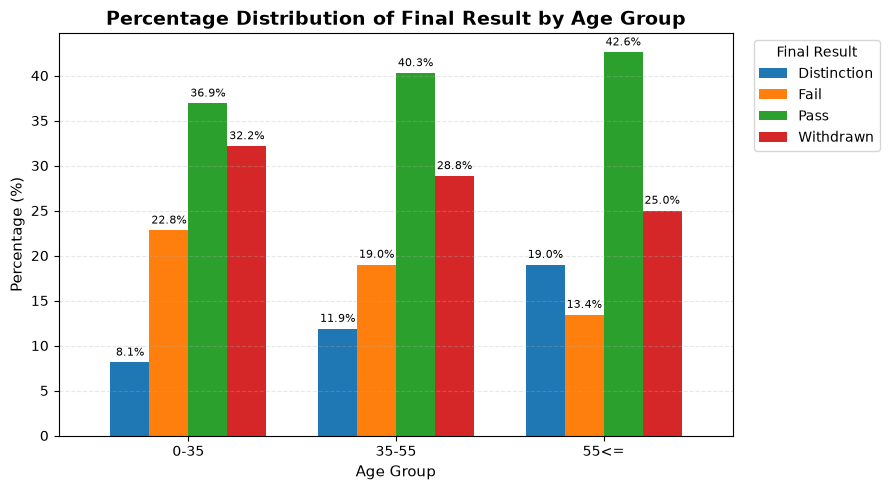

In [437]:
# Percentage of Final Result within each Age Group

age_pct = pd.crosstab(
    df_students['age_band'],
    df_students['final_result'],
    normalize='index'
) * 100

# Create grouped bar chart
ax = age_pct.plot(
    kind='bar',
    figsize=(9,5),
    width=0.75
)

# ===== Added: Display percentage labels =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=8,
        padding=3
    )

# Formatting
plt.title(
    "Percentage Distribution of Final Result by Age Group",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title="Final Result",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

3. Education vs Final Result

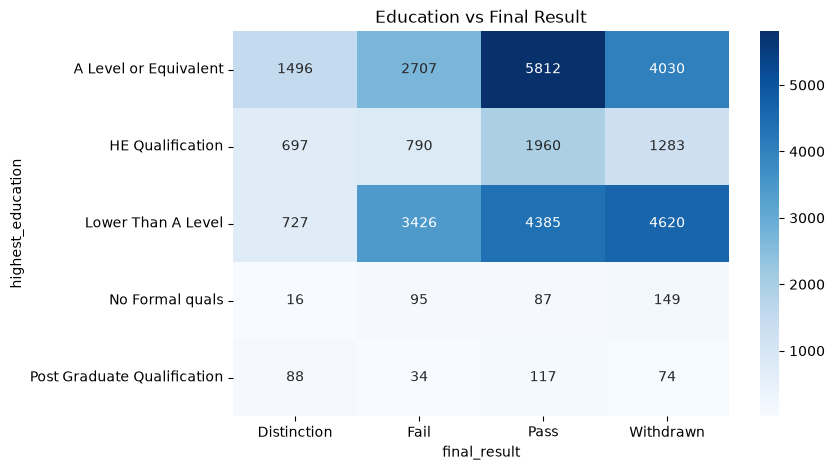

In [438]:
education = pd.crosstab( 
    df_students['highest_education'], 
    df_students['final_result'] 
    )
plt.figure(figsize=(8,5))
sns.heatmap( 
    education, 
    annot=True, 
    fmt="d", 
    cmap="Blues" 
    )
plt.title("Education vs Final Result") 
plt.show()


4. IMD Band vs Final Result

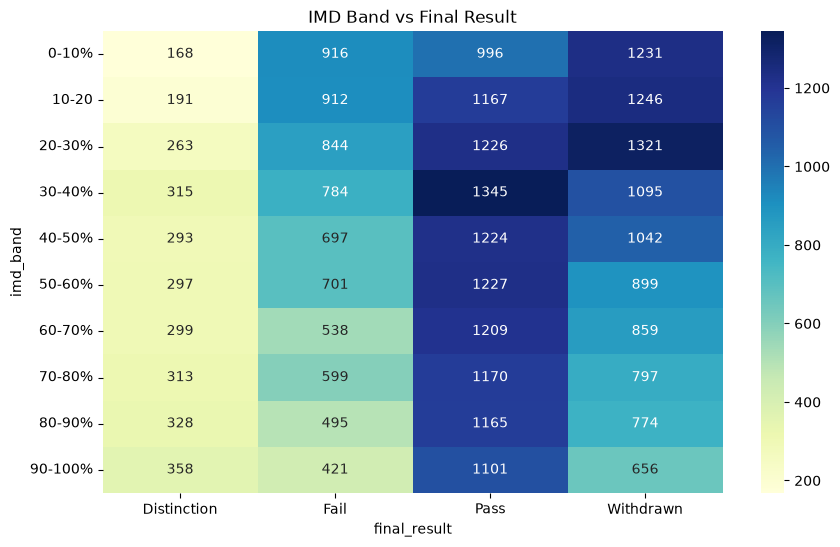

In [439]:
imd = pd.crosstab(
    df_students['imd_band'],
    df_students['final_result']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    imd,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("IMD Band vs Final Result")
plt.show()

5. Disability vs Final Result

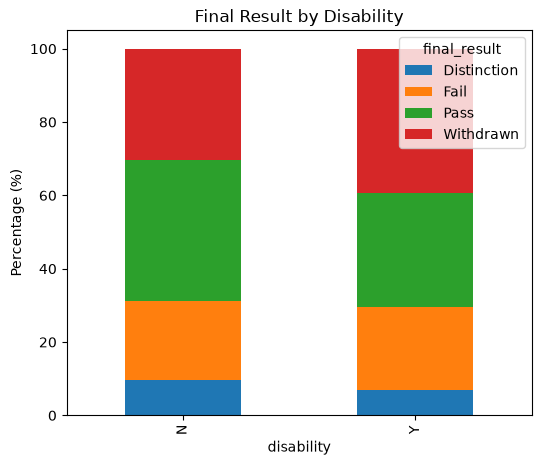

In [440]:
disability_pct = pd.crosstab(
    df_students['disability'],
    df_students['final_result'],
    normalize='index'
) * 100

disability_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5)
)

plt.title("Final Result by Disability")
plt.ylabel("Percentage (%)")
plt.show()

6. Previous Attempts vs Final Result

num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64


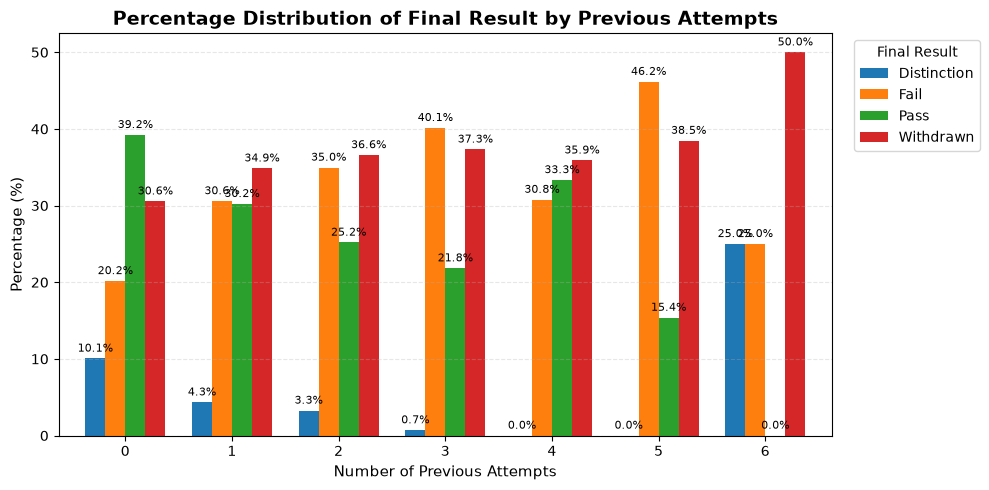

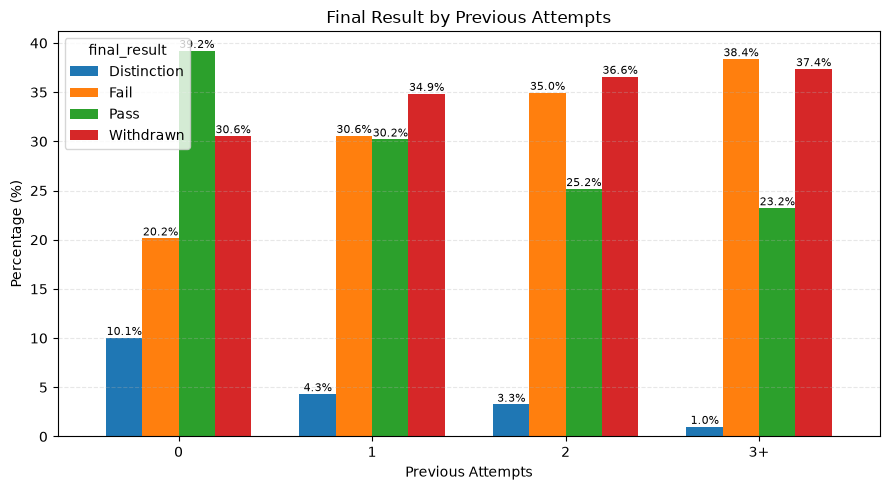

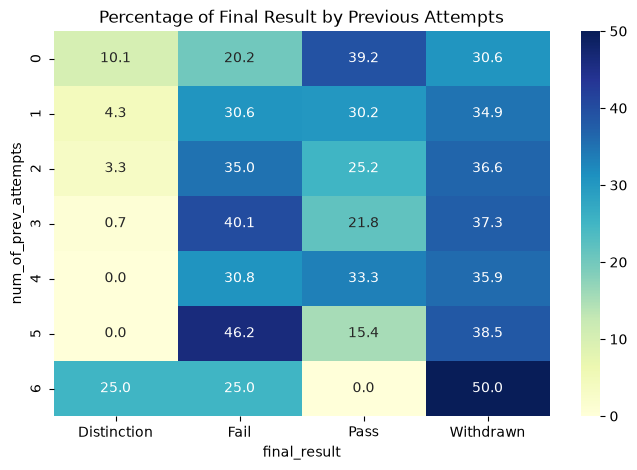

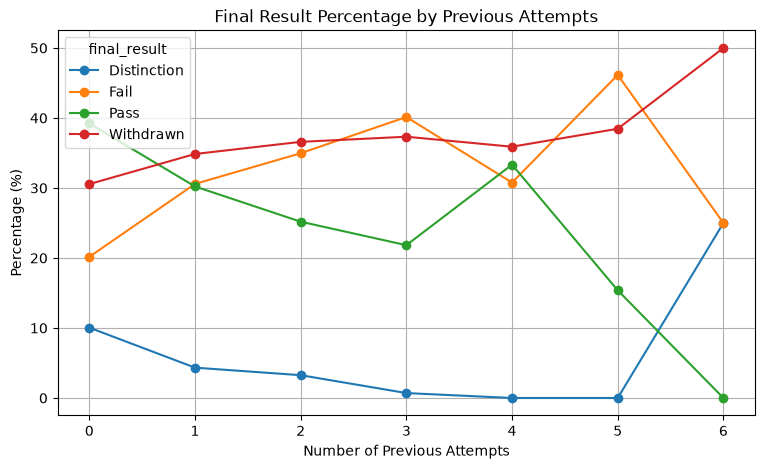

In [441]:
print(df_students['num_of_prev_attempts'].value_counts().sort_index())
# Percentage Distribution of Final Result by Previous Attempts

attempts_pct = pd.crosstab(
    df_students['num_of_prev_attempts'],
    df_students['final_result'],
    normalize='index'
) * 100

# Create grouped bar chart
ax = attempts_pct.plot(
    kind='bar',
    figsize=(10,5),
    width=0.75
)

# ===== Added: Display percentage labels =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=8,
        padding=3
    )

# Formatting
plt.title(
    "Percentage Distribution of Final Result by Previous Attempts",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Number of Previous Attempts", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title="Final Result",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

#Grouped categories
# Create grouped previous attempts
df_students["prev_attempt_group"] = (
    df_students["num_of_prev_attempts"]
    .replace({3: "3+", 4: "3+", 5: "3+", 6: "3+"})
    .astype(str)
)

attempt_pct = pd.crosstab(
    df_students["prev_attempt_group"],
    df_students["final_result"],
    normalize="index"
) * 100

ax = attempt_pct.plot(
    kind="bar",
    figsize=(9,5),
    width=0.75
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=8
    )

plt.title("Final Result by Previous Attempts")
plt.xlabel("Previous Attempts")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()
#Heatmap
attempt = pd.crosstab(
    df_students["num_of_prev_attempts"],
    df_students["final_result"],
    normalize="index"
) * 100

plt.figure(figsize=(8,5))

sns.heatmap(
    attempt,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Percentage of Final Result by Previous Attempts")
plt.show()

#Line Chart
attempt_pct = pd.crosstab(
    df_students["num_of_prev_attempts"],
    df_students["final_result"],
    normalize="index"
) * 100

attempt_pct.plot(
    marker="o",
    figsize=(9,5)
)

plt.ylabel("Percentage (%)")
plt.xlabel("Number of Previous Attempts")
plt.title("Final Result Percentage by Previous Attempts")
plt.grid(True)
plt.show()

7. Credits vs Final Result

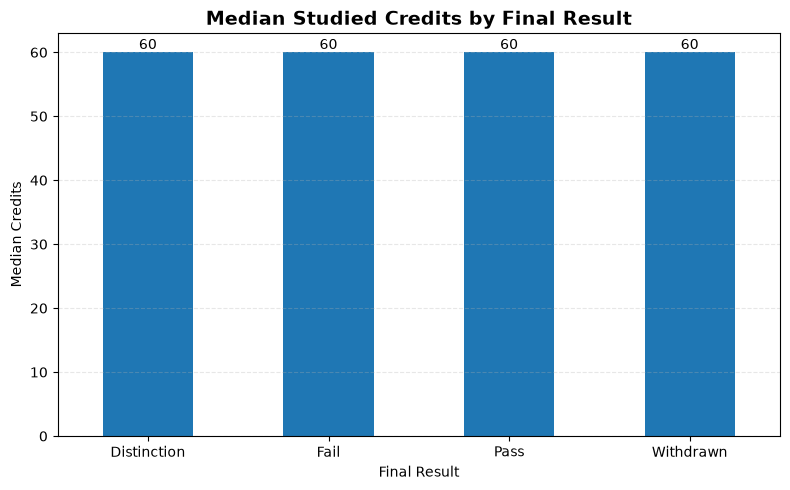

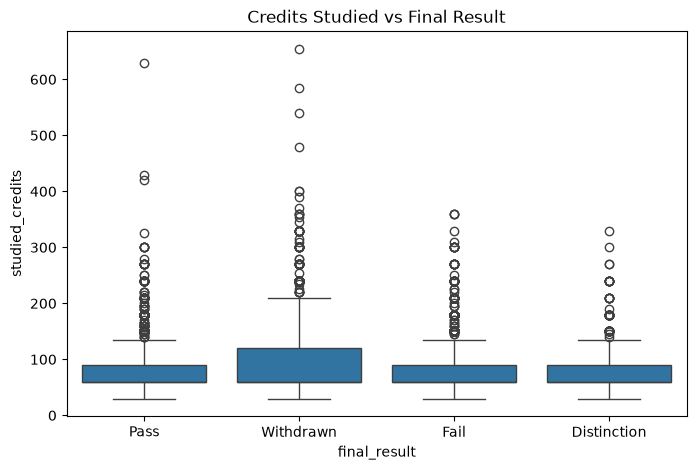

In [442]:

#Median Chart
median_credit = (
    df_students
    .groupby("final_result")["studied_credits"]
    .median()
)

ax = median_credit.plot(
    kind="bar",
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=10
    )

plt.title("Median Studied Credits by Final Result", fontsize=14, weight="bold")
plt.xlabel("Final Result")
plt.ylabel("Median Credits")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()

#Box plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_students,
    x='final_result',
    y='studied_credits'
)

plt.title("Credits Studied vs Final Result")

plt.show()

### Observation

• The median number of studied credits is similar across all final result categories.

• Students who withdrew exhibit the greatest variability in studied credits, as indicated by the wider box and longer whiskers.

• All categories contain several high-credit outliers, suggesting that a small number of students enrolled in unusually large credit loads.

• Since the distributions overlap considerably, studied credits alone do not appear to strongly differentiate student outcomes.

### Fairness Observation

The StudentInfo dataset contains sensitive demographic attributes such as gender, age, disability status, and socioeconomic status (IMD Band). These variables are important not only for predicting dropout but also for evaluating whether the machine learning model treats different student groups fairly.

In later stages of the project, fairness metrics will be evaluated to ensure that predictions are not biased toward any demographic group.

### Part 6 – Student Assessment Analysis
In OULAD (Open University Learning Analytics Dataset), is_banked indicates whether the student carried forward (banked) the result of an assessment from a previous presentation of the same module.

Think of it like this:

Scenario 1: Not Banked (is_banked = 0) ✅

A student takes a course and completes a TMA.

They receive:

Score = 82
is_banked = 0

This means:

The student completed this assessment during the current course presentation, and this is their actual score.

Scenario 2: Banked (is_banked = 1)

Suppose a student:

Completed some assignments in 2023
Didn't finish the course and withdrew

The next year, they enroll in the same module again.

Instead of asking them to repeat those completed assignments, the university may carry forward (or bank) the previous assessment scores.

For example:

Year	Assignment Score
2023	78
2024	78 (reused)

Here:

score = 78
is_banked = 1

The score wasn't earned again; it was transferred from an earlier attempt.

Simple definition for your report

is_banked indicates whether an assessment score was carried forward from a previous attempt at the same course (1) or earned during the current course presentation (0).

Why is this important?

Banked assessments may behave differently because:

The student did not retake the assessment.
The score reflects previous work rather than current performance.
It can influence analyses of student progress.

For example, you could investigate whether students with banked assessments have different final outcomes than students without them.

# Student assessment analysis
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0
       id_assessment    id_student  date_submitted      is_banked  \
count  173912.000000  1.739120e+05   173912.000000  173912.000000   
mean    26553.803556  7.051507e+05      116.032942       0.010977   
std      8829.784254  5.523952e+05       71.484148       0.104194   
min      1752.000000  6.516000e+03      -11.000000       0.000000   
25%     15022.000000  5.044290e+05       51.000000       0.000000   
50%     25359.000000  5.852080e+05      116.000000       0.000000   
75%     34883.000000  6.344980e+05      173.000000       0.000000   
max     37443.000000  2.698588e+06      

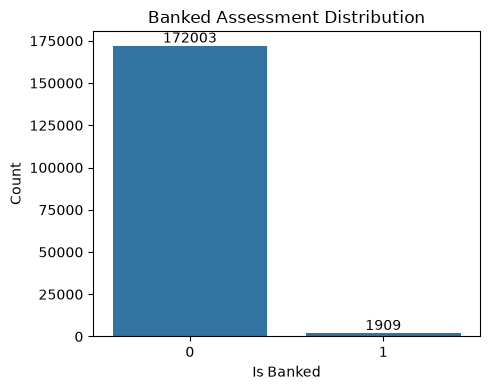

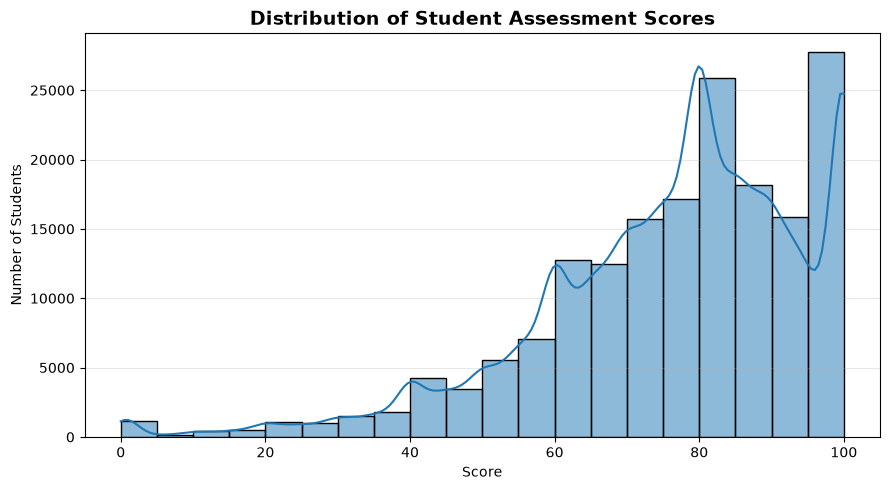

scores by assessment type:
                   count       mean        std  min   25%   50%   75%    max
assessment_type                                                             
CMA              70527.0  81.027053  17.836026  0.0  72.0  82.0  98.0  100.0
Exam              4959.0  65.572898  20.579186  0.0  51.0  67.0  82.0  100.0
TMA              98253.0  72.563392  18.432823  0.0  63.0  76.0  86.0  100.0


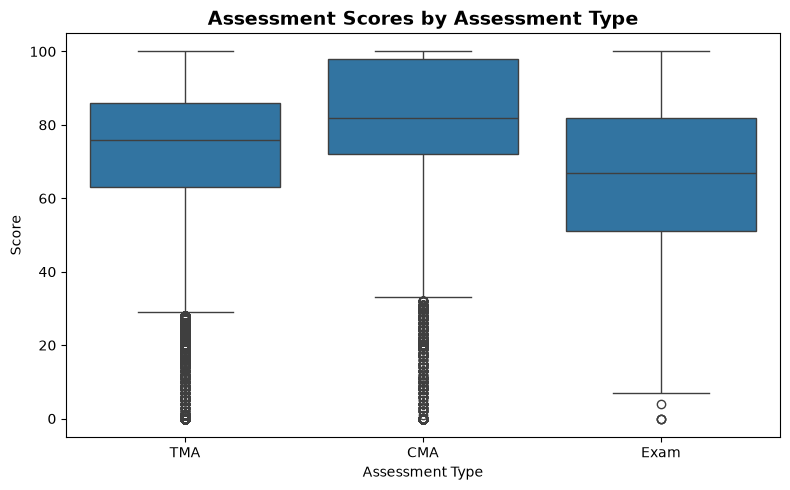

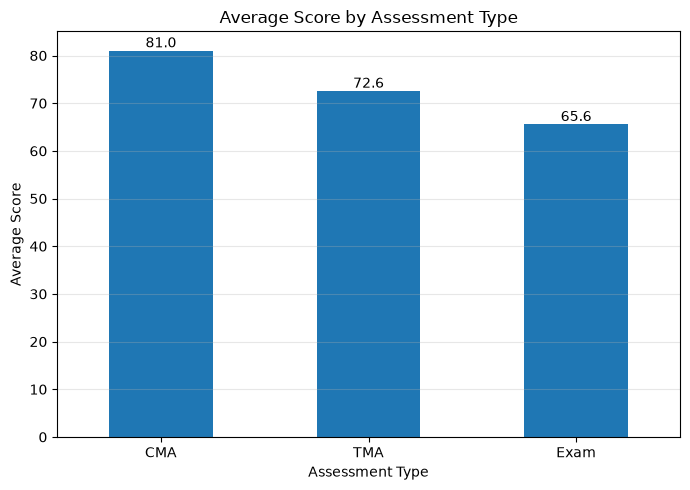

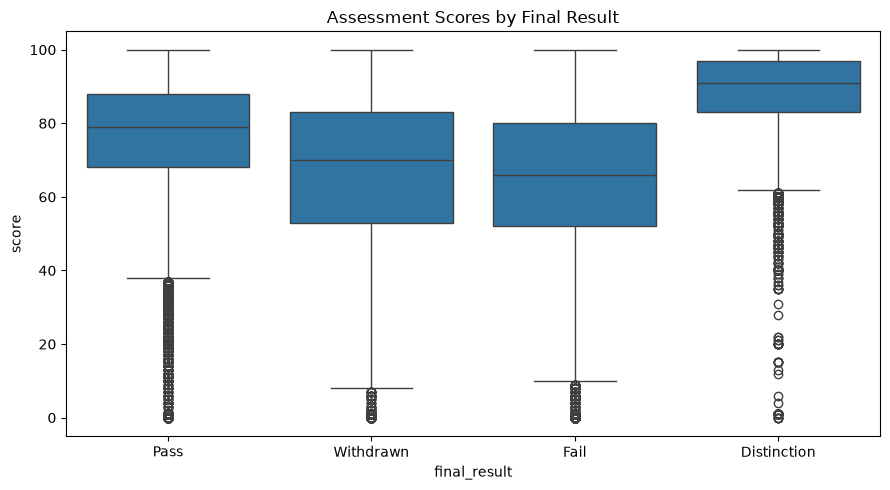

In [443]:
# Student assessment analysis
# Dataset Preview
print("# Student assessment analysis")
print(df_studentAssessments.head())
#Dataset Summary
print(df_studentAssessments.describe(include='all'))
#Missing Scores
print('missing scores:', df_studentAssessments['score'].isna().sum())
missing = df_studentAssessments['score'].isna().sum() #Added By Kiran
print(f"Missing Scores: {missing}") #Added By Kiran
print(f"Missing Percentage: {(missing/len(df_studentAssessments))*100:.2f}%") #Added By Kiran

print('banked counts:')
print(df_studentAssessments['is_banked'].value_counts(dropna=False))
#Visualization
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df_studentAssessments,
    x='is_banked'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Banked Assessment Distribution")
plt.xlabel("Is Banked")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Score Distribution
plt.figure(figsize=(9,5))

sns.histplot(
    df_studentAssessments['score'],
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Student Assessment Scores",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Merge with Assessment Table

merged_scores = df_studentAssessments.merge(df_assessments, on='id_assessment', how='left')
print('scores by assessment type:')
print(merged_scores.groupby('assessment_type')['score'].describe())

#Visualization
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=merged_scores,
    x='assessment_type',
    y='score'
)

plt.title(
    "Assessment Scores by Assessment Type",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Assessment Type")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# Average score by assessment type
avg_score = (
    merged_scores
    .groupby('assessment_type')['score']
    .mean()
    .sort_values(ascending=False)
)

ax = avg_score.plot(
    kind='bar',
    figsize=(7,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.title("Average Score by Assessment Type")
plt.xlabel("Assessment Type")
plt.ylabel("Average Score")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Comparing scores with the final result
score_result = merged_scores.merge(
    df_students[
        ['id_student',
         'code_module',
         'code_presentation',
         'final_result']
    ],
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=score_result,
    x='final_result',
    y='score'
)

plt.title("Assessment Scores by Final Result")
plt.tight_layout()
plt.show()

### Registration Anslysis

# Registration analysis
  code_module code_presentation  id_student  date_registration  \
0         AAA             2013J       11391             -159.0   
1         AAA             2013J       28400              -53.0   
2         AAA             2013J       30268              -92.0   
3         AAA             2013J       31604              -52.0   
4         AAA             2013J       32885             -176.0   

   date_unregistration  
0                  NaN  
1                  NaN  
2                 12.0  
3                  NaN  
4                  NaN  
       code_module code_presentation    id_student  date_registration  \
count        32593             32593  3.259300e+04       32548.000000   
unique           7                 4           NaN                NaN   
top            BBB             2014J           NaN                NaN   
freq          7909             11260           NaN                NaN   
mean           NaN               NaN  7.066877e+05         -69.4

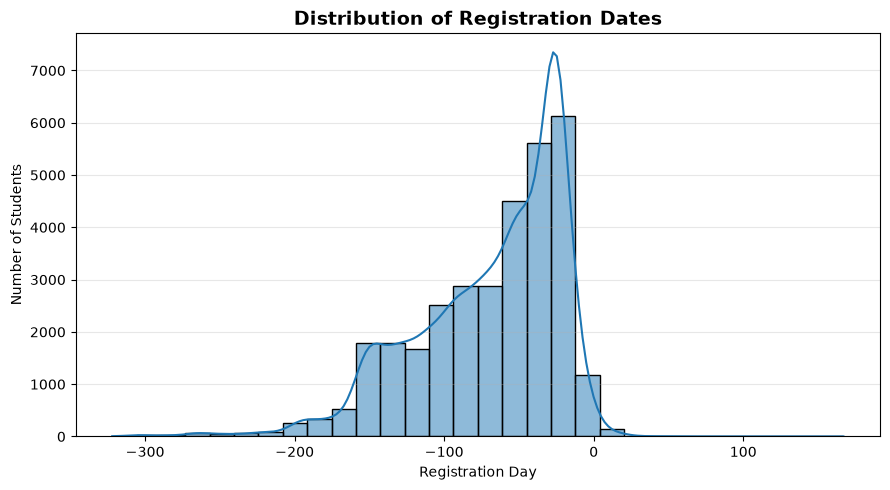

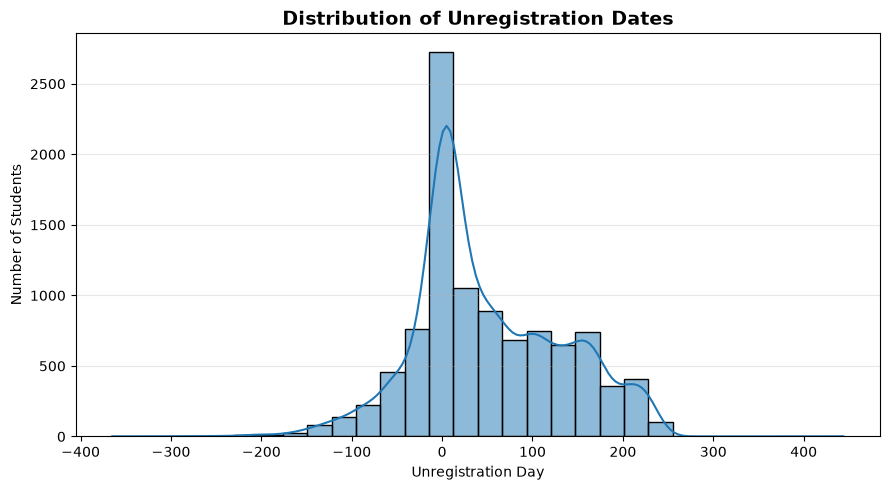

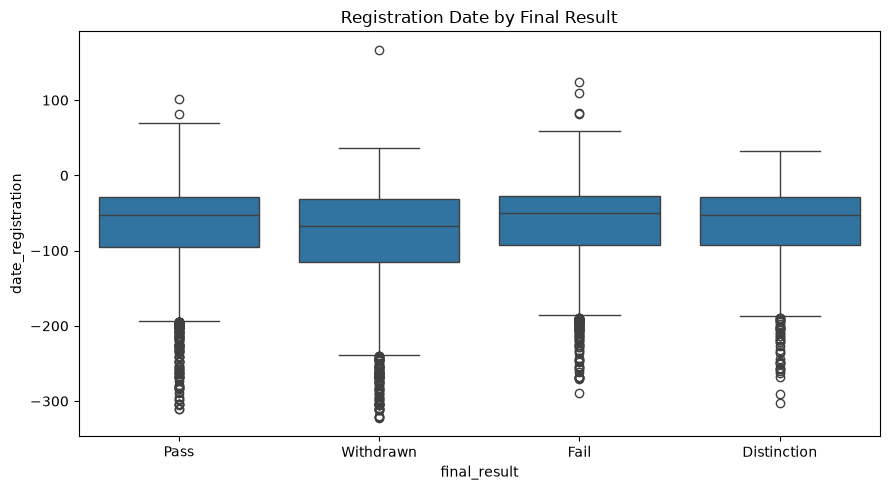

date_unregistration
True     22521
False    10072
Name: count, dtype: int64


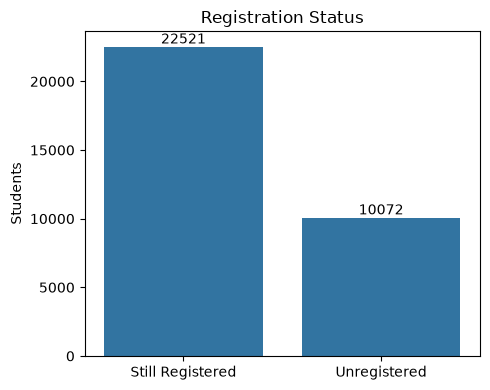

Total Students : 32593
Unregistered : 10072
Percentage : 30.90%


In [444]:
# Registration analysis
#Dataset Preview
print("# Registration analysis")
print(df_studentRegistration.head())
# Summary Statistics
print(df_studentRegistration.describe(include='all'))
# Missing Unregistration Dates
print('missing unregistration dates:', df_studentRegistration['date_unregistration'].isna().sum())

missing = df_studentRegistration['date_unregistration'].isna().sum()

print(f"Missing Unregistration Dates: {missing}")
print(f"Missing Percentage: {(missing/len(df_studentRegistration))*100:.2f}%")

# Registration Date Histogram
plt.figure(figsize=(9,5))

sns.histplot(
    df_studentRegistration['date_registration'],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Registration Dates",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Registration Day")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Unregistration Histogram
if 'date_unregistration' in df_studentRegistration.columns:
    valid_unreg = df_studentRegistration[df_studentRegistration['date_unregistration'].notna()]
    plt.figure(figsize=(9,5))

sns.histplot(
    valid_unreg['date_unregistration'],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Unregistration Dates",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Unregistration Day")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Registration vs Final Result
registration_result = df_studentRegistration.merge(
    df_students[
        [
            'id_student',
            'code_module',
            'code_presentation',
            'final_result'
        ]
    ],
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

#Compare registration Dates
plt.figure(figsize=(9,5))

sns.boxplot(
    data=registration_result,
    x='final_result',
    y='date_registration'
)

plt.title("Registration Date by Final Result")
plt.tight_layout()
plt.show()

#Registration vs Unregistration
print(df_studentRegistration['date_unregistration'].isna().value_counts())

status = df_studentRegistration['date_unregistration'].isna()

status = status.map({
    True: 'Still Registered',
    False: 'Unregistered'
})

plt.figure(figsize=(5,4))

ax = sns.countplot(
    x=status
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Registration Status")

plt.xlabel("")
plt.ylabel("Students")
plt.tight_layout()
plt.show()

# How many students actually unregistered
total = len(df_studentRegistration)

unregistered = (
    df_studentRegistration
    ['date_unregistration']
    .notna()
    .sum()
)

print(f"Total Students : {total}")
print(f"Unregistered : {unregistered}")
print(f"Percentage : {(unregistered/total)*100:.2f}%")



### Observation

• Most students have a missing `date_unregistration`, indicating they remained enrolled or completed the course.

• Registration dates are distributed across the presentation period, with some students registering much earlier than others.

• The distribution of unregistration dates helps identify when students are most likely to leave the course.

• Comparing registration dates across final result categories can reveal whether early registration is associated with better academic outcomes.

### VLE (Virtual Learning Environment)
VLE (Virtual Learning Environment) interactions measure student engagement, and engagement is usually one of the strongest predictors of student dropout.

# VLE analysis
   id_site code_module code_presentation activity_type  week_from  week_to
0   546943         AAA             2013J      resource        NaN      NaN
1   546712         AAA             2013J     oucontent        NaN      NaN
2   546998         AAA             2013J      resource        NaN      NaN
3   546888         AAA             2013J           url        NaN      NaN
4   547035         AAA             2013J      resource        NaN      NaN
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64
week_from missing: 5243
week_to mis

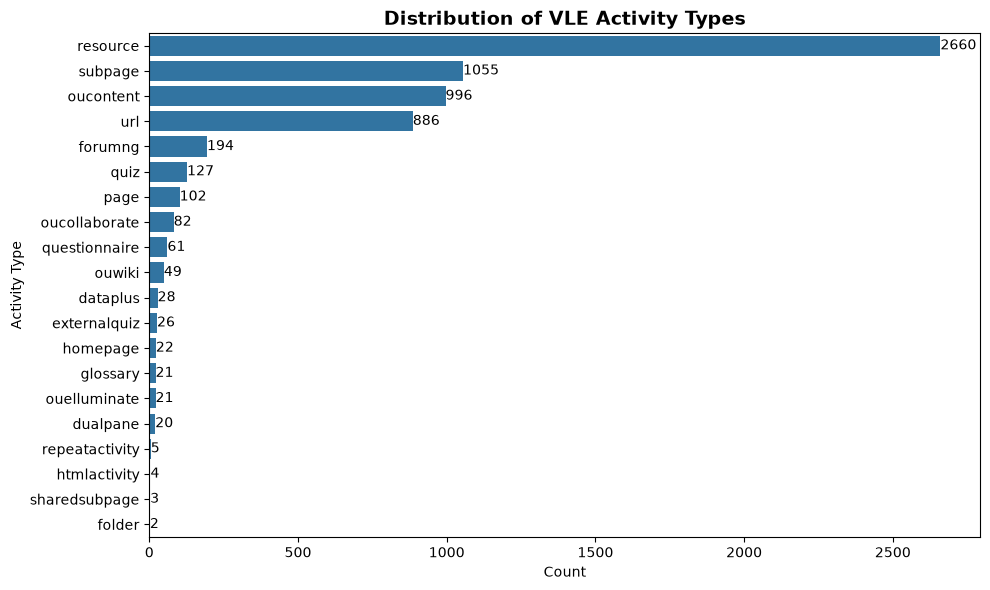

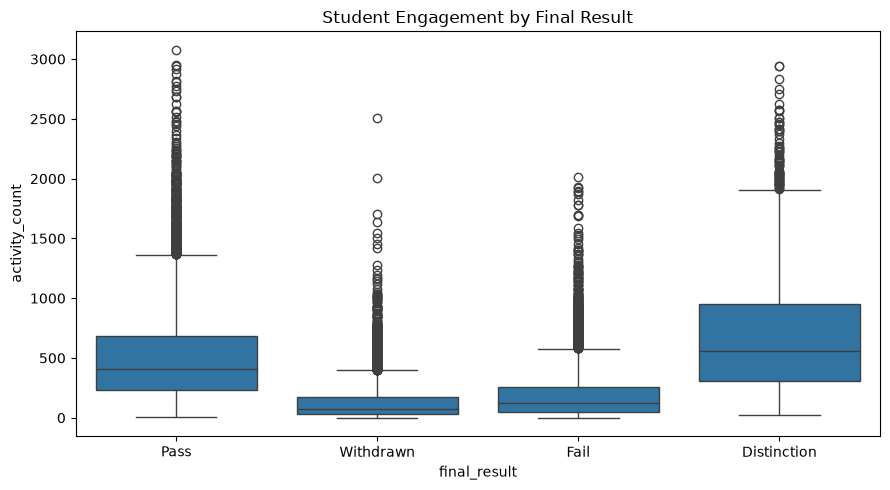

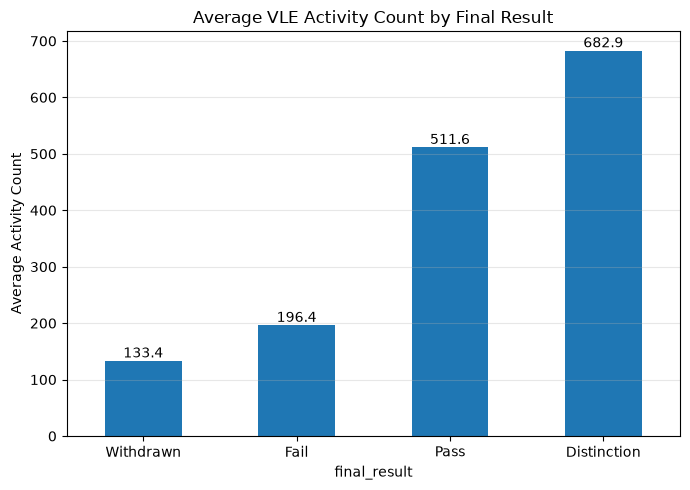

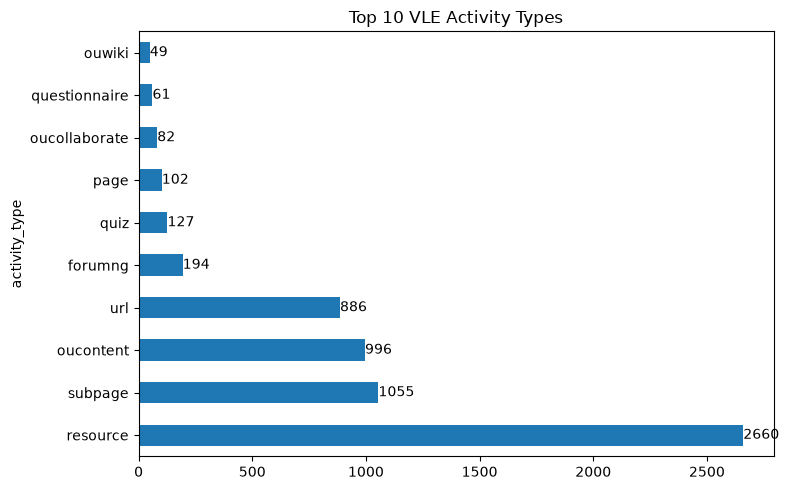

In [445]:
# VLE analysis
# VLE Dataset Preview
print("# VLE analysis")
print(df_vle.head())
# Activity Type Counts
print(df_vle['activity_type'].value_counts(dropna=False).head(20))
# Missing Values
print('week_from missing:', df_vle['week_from'].isna().sum())
print('week_to missing:', df_vle['week_to'].isna().sum())

for col in ['week_from', 'week_to']:
    missing = df_vle[col].isna().sum()

    print(f"{col} Missing: {missing}")
    print(f"{col} Missing Percentage: {(missing/len(df_vle))*100:.2f}%")

# Activity Type Count Plot
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_vle,
    y='activity_type',
    order=df_vle['activity_type'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(
        container
    )

plt.title(
    "Distribution of VLE Activity Types",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Count")
plt.ylabel("Activity Type")

plt.tight_layout()

plt.show()

# Create engagement dataframe
engagement = (
    df_studentVle
    .groupby(
        [
            'id_student',
            'code_module',
            'code_presentation'
        ]
    )
    .agg(
        activity_count=('id_site', 'count'),
        total_clicks=('sum_click', 'sum'),
        active_days=('date', 'nunique'),
        unique_resources=('id_site', 'nunique')
    )
    .reset_index()
)
# Engagement vs Final Result
engagement_result = engagement.merge(
    df_students[
        [
            'id_student',
            'code_module',
            'code_presentation',
            'final_result'
        ]
    ],
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

# Compare engagement
plt.figure(figsize=(9,5))

sns.boxplot(
    data=engagement_result,
    x='final_result',
    y='activity_count'
)

plt.title("Student Engagement by Final Result")
plt.tight_layout()
plt.show()

# Average engagemen
avg_engagement = (
    engagement_result
    .groupby('final_result')['activity_count']
    .mean()
    .sort_values()
)

ax = avg_engagement.plot(
    kind='bar',
    figsize=(7,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.title("Average VLE Activity Count by Final Result")
plt.ylabel("Average Activity Count")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Top activity types
top10 = (
    df_vle['activity_type']
    .value_counts()
    .head(10)
)

ax = top10.plot(
    kind='barh',
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 VLE Activity Types")
plt.tight_layout()
plt.show()

### Cross-dataset analysis
It starts answering the project's main question: "How do assessment scores relate to student outcomes?"

# Cross-dataset analysis
merged shape: (173912, 20)
imd_band                7697
date                    2865
score                    173
id_assessment              0
is_banked                  0
date_submitted             0
id_student                 0
code_presentation          0
assessment_type            0
weight                     0
gender                     0
code_module                0
region                     0
highest_education          0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
prev_attempt_group         0
dtype: int64
                      Missing Count  Missing %
imd_band                       7697       4.43
date                           2865       1.65
score                           173       0.10
id_assessment                     0       0.00
is_banked                         0       0.00
date_submitted                    0       0.00
id_student                

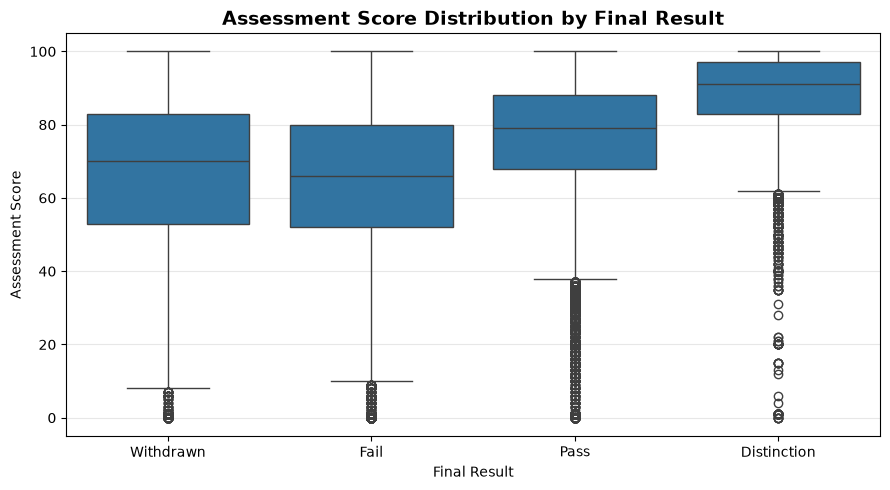

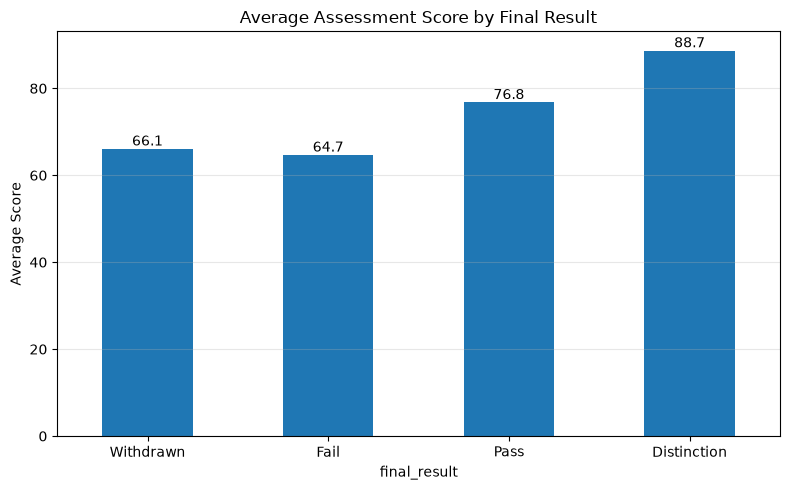

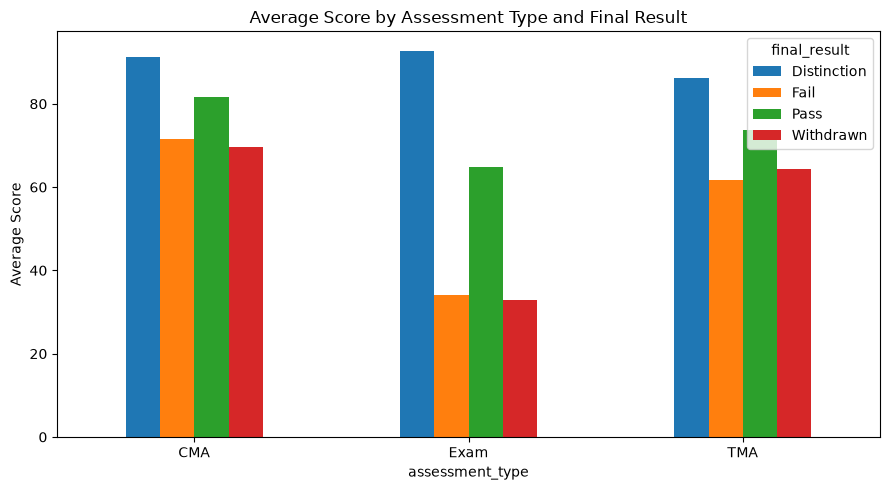

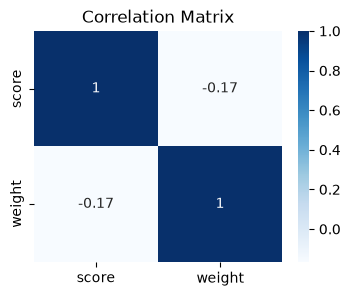

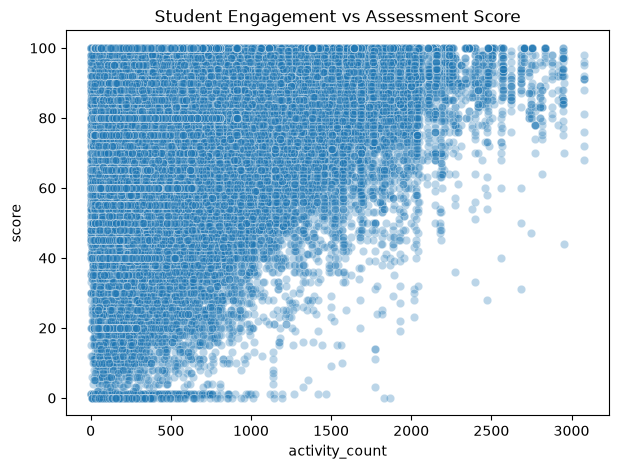

In [446]:
# Cross-dataset analysis
print("# Cross-dataset analysis")
# Merge the Datasets
merged = df_studentAssessments.merge(df_assessments, on='id_assessment', how='left')
merged = merged.merge(df_students, on=['code_module', 'code_presentation', 'id_student'], how='left')

# Check Shape
print('merged shape:', merged.shape)

# Missing Values
print(merged.isna().sum().sort_values(ascending=False).head(20))

missing = (
    merged
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    merged
    .isna()
    .mean()*100
).sort_values(ascending=False)

print(pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
}).head(20))

# Score Summary
result_score = merged.groupby('final_result')['score'].agg(['count', 'mean', 'median', 'std']).reset_index()
print(result_score)

# Score Distribution
plt.figure(figsize=(9,5))

sns.boxplot(
    data=merged,
    x='final_result',
    y='score',
    order=['Withdrawn','Fail','Pass','Distinction']
)

plt.title(
    "Assessment Score Distribution by Final Result",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Final Result")
plt.ylabel("Assessment Score")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Bar Chart
avg_score = (
    merged
    .groupby('final_result')['score']
    .mean()
    .reindex(
        ['Withdrawn','Fail','Pass','Distinction']
    )
)

ax = avg_score.plot(
    kind='bar',
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.title("Average Assessment Score by Final Result")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Compare assessment types
score_type = (
    merged
    .groupby(
        ['assessment_type',
         'final_result']
    )['score']
    .mean()
    .unstack()
)

score_type.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title(
    "Average Score by Assessment Type and Final Result"
)

plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation
corr = merged[
    [
        'score',
        'weight'
    ]
].corr()

plt.figure(figsize=(4,3))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")
plt.show()

# Student Engagement + Score: Merge VLE engagement
engagement_score = merged.merge(
    engagement,
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=engagement_score,
    x='activity_count',
    y='score',
    alpha=0.3
)

plt.title(
    "Student Engagement vs Assessment Score"
)

plt.show()

### Explore the existing variables and their relationships

### 1. Missing Value Summary (Overall Dataset)

Observation

The merged dataset contains missing values primarily in assessment scores and registration-related fields. These missing values will be handled appropriately during preprocessing.

In [447]:
print("# Missing Values in Merged Dataset")

missing = pd.DataFrame({
    'Missing Count': merged.isnull().sum(),
    'Missing Percentage': (
        merged.isnull().mean() * 100
    ).round(2)
})

missing = missing[
    missing['Missing Count'] > 0
].sort_values(
    by='Missing Percentage',
    ascending=False
)

print(missing)

# Missing Values in Merged Dataset
          Missing Count  Missing Percentage
imd_band           7697                4.43
date               2865                1.65
score               173                0.10


### 2. Correlation Matrix (Only Numeric Features)

Since this uses existing numeric columns, it belongs in EDA.

Observation

Most numeric variables exhibit weak to moderate correlations. Assessment score and assessment weight show a positive relationship, while registration-related variables exhibit comparatively weaker associations.

In [448]:
print(merged.columns.tolist())

['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score', 'code_module', 'code_presentation', 'assessment_type', 'date', 'weight', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'prev_attempt_group']


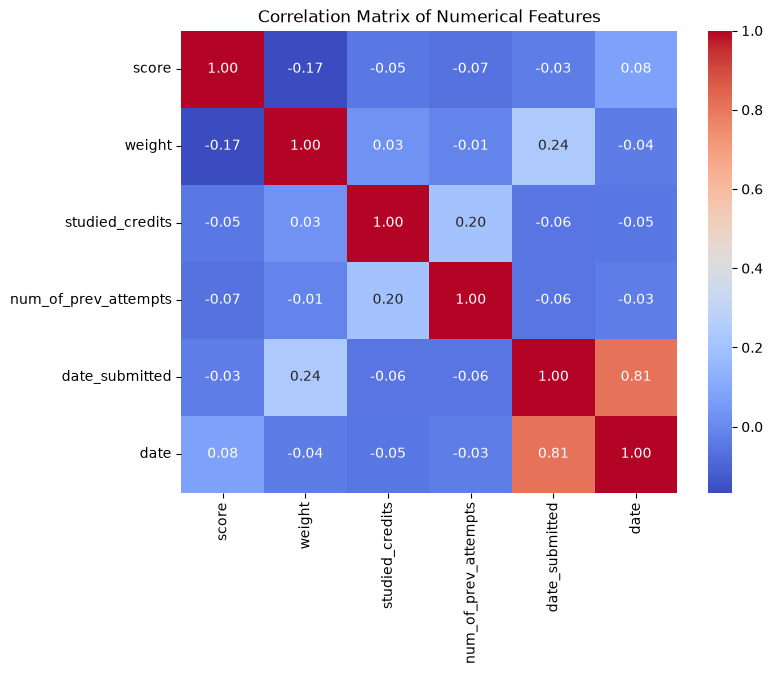

In [449]:
numeric_columns = [
    'score',
    'weight',
    'studied_credits',
    'num_of_prev_attempts',
    'date_submitted',
    'date'
]

corr = merged[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

3. Pairplot

Shows relationships among the important numeric variables.

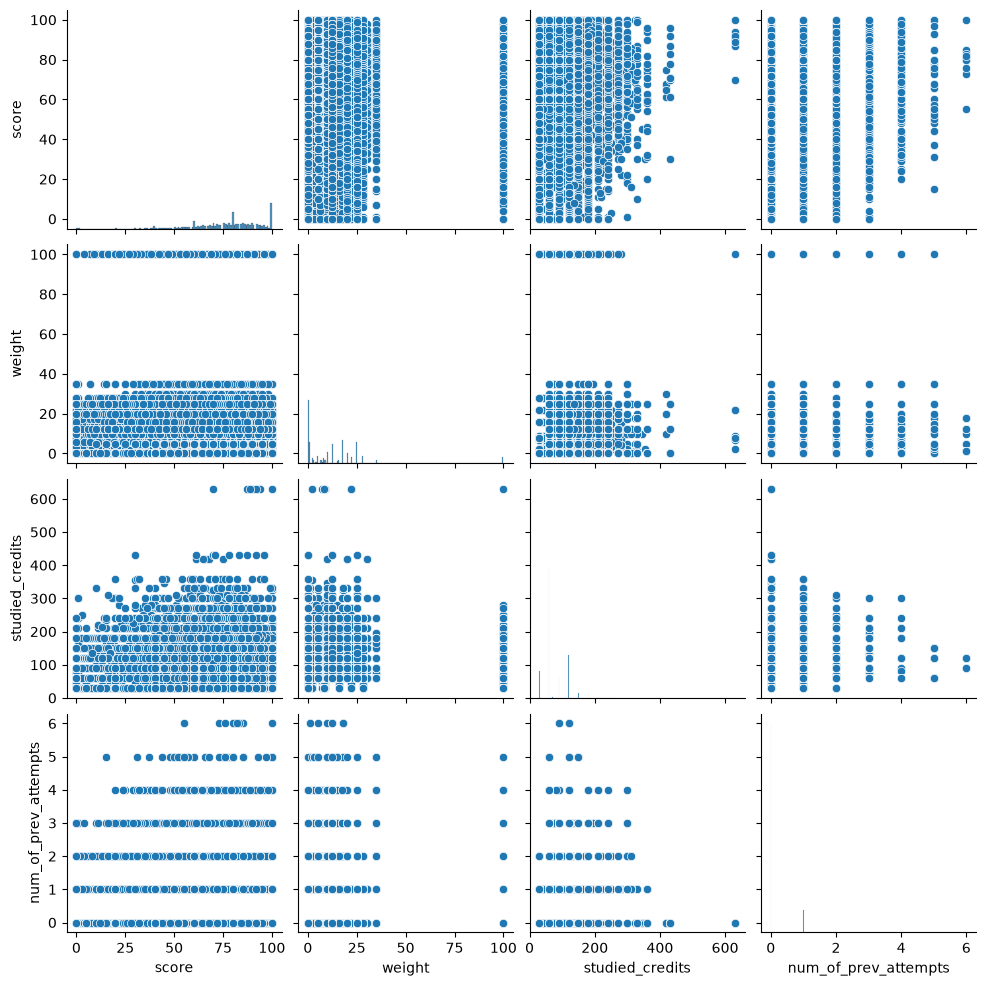

In [450]:
pairplot_data = merged[
    [
        'score',
        'weight',
        'studied_credits',
        'num_of_prev_attempts'
    ]
].dropna()

sns.pairplot(pairplot_data)

plt.show()

### 4. Module-wise Student Distribution

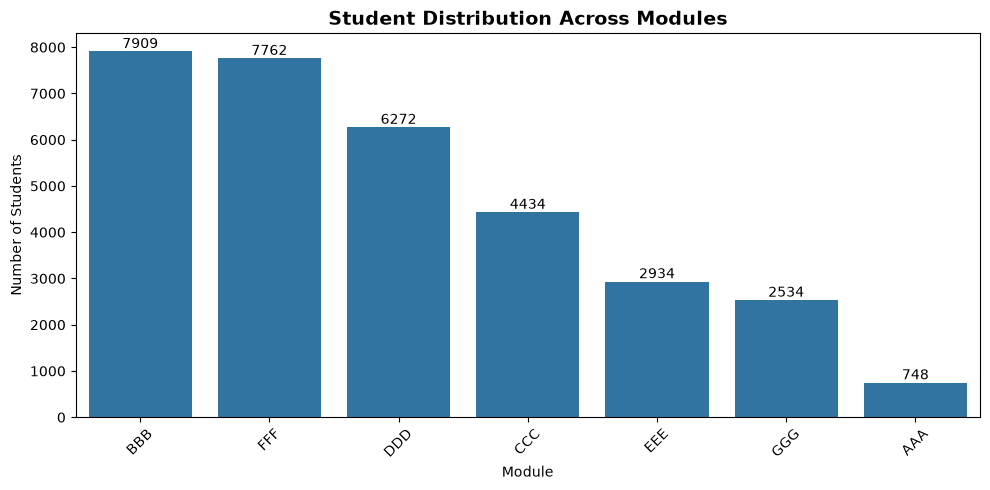

In [451]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df_students,
    x='code_module',
    order=df_students['code_module'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Student Distribution Across Modules",
    fontsize=14,
    weight='bold'
)

plt.xlabel("Module")
plt.ylabel("Number of Students")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### 5. Presentation-wise Student Distribution
Observation

Student enrollment differs across course presentations, reflecting variations in course offerings over different academic terms.

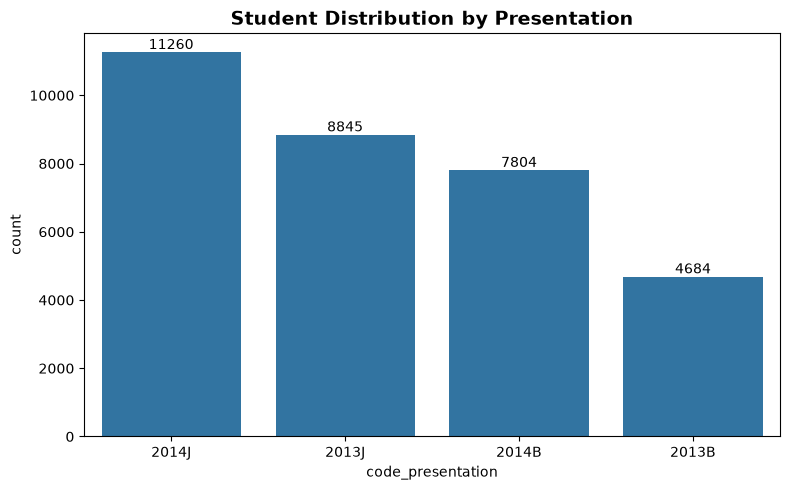

In [452]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_students,
    x='code_presentation',
    order=df_students['code_presentation'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Student Distribution by Presentation",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.show()

### 6. Module vs Final Result
Observation

Academic outcomes vary across modules, with some courses exhibiting higher pass rates while others show comparatively higher withdrawal or failure rates.

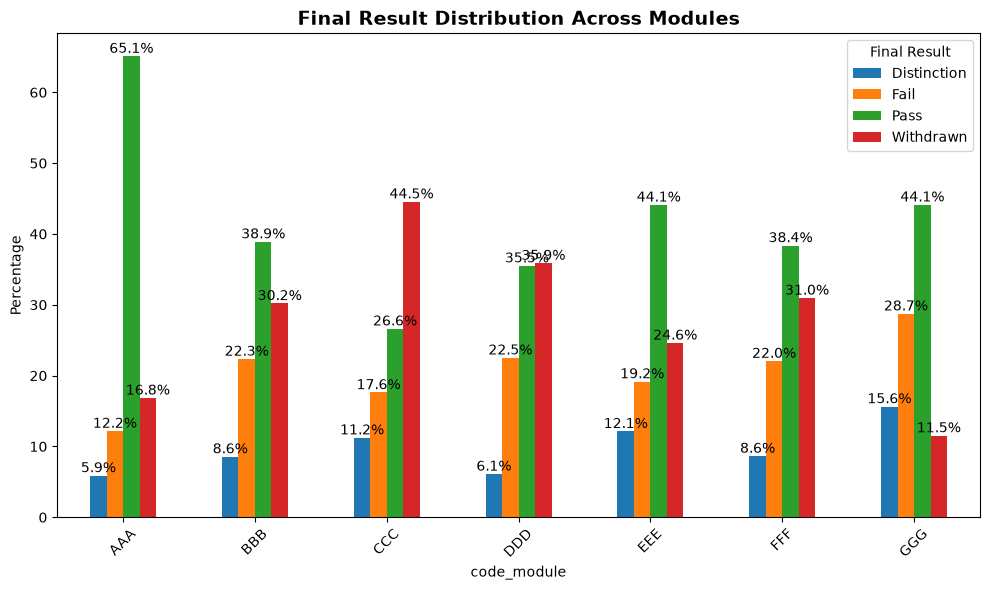

In [453]:
module_result = pd.crosstab(
    df_students['code_module'],
    df_students['final_result'],
    normalize='index'
) * 100

ax = module_result.plot(
    kind='bar',
    figsize=(10,6)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Final Result Distribution Across Modules",
    fontsize=14,
    weight='bold'
)

plt.ylabel("Percentage")

plt.xticks(rotation=45)

plt.legend(title="Final Result")

plt.tight_layout()

plt.show()

### 7. Assessment Type vs Final Result

Observation

The distribution of final outcomes differs across assessment types, indicating that assessment format may influence student performance.

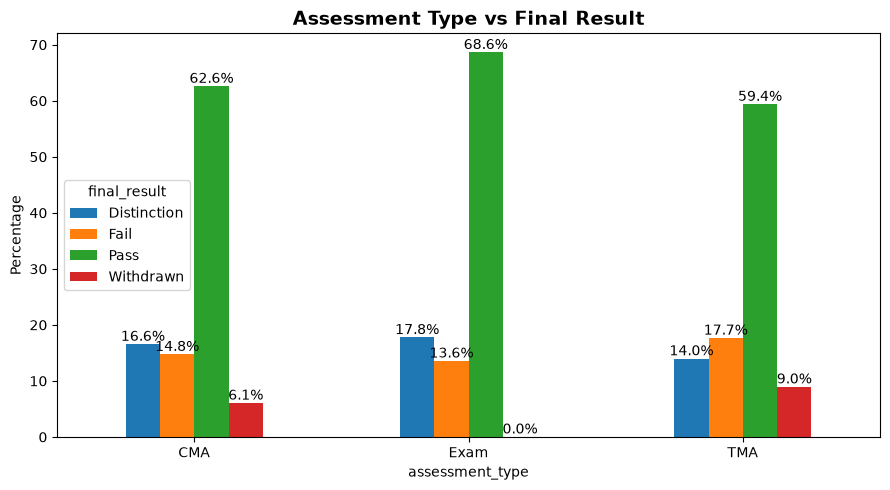

In [454]:
assessment_result = pd.crosstab(
    merged['assessment_type'],
    merged['final_result'],
    normalize='index'
) * 100

ax = assessment_result.plot(
    kind='bar',
    figsize=(9,5)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Assessment Type vs Final Result",
    fontsize=14,
    weight='bold'
)

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### 8. Region vs Final Result

Observation

Student outcomes vary slightly across regions, although the differences are less pronounced than those observed for behavioural or academic variables.

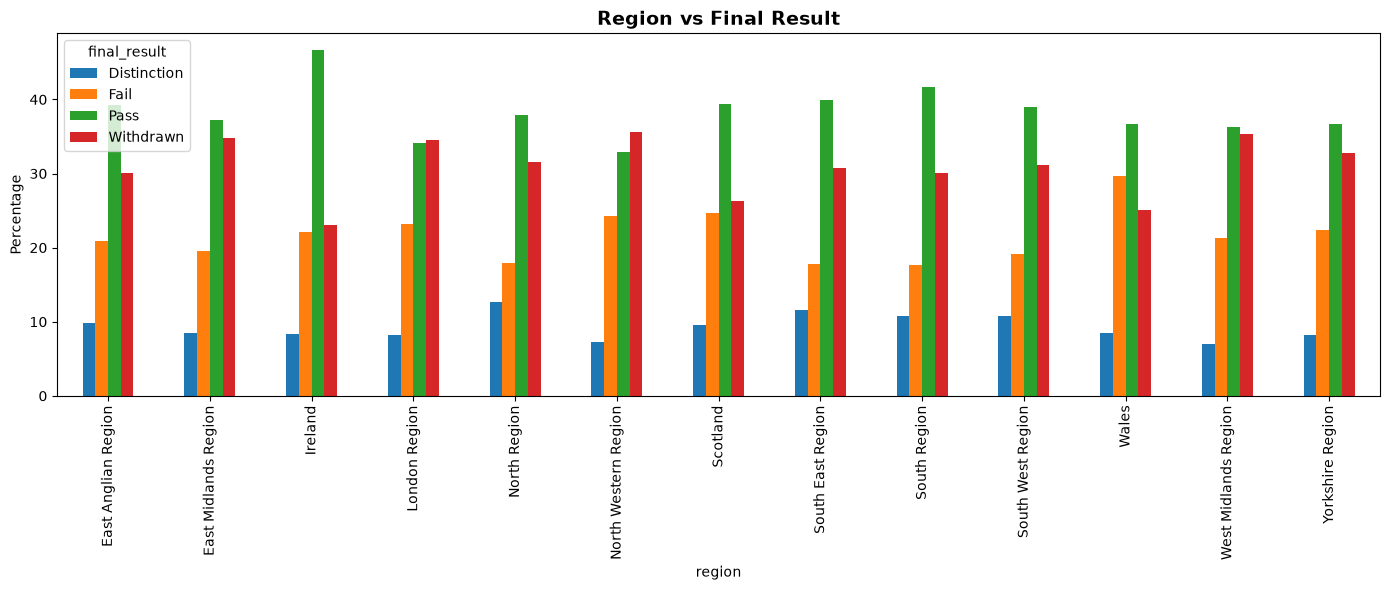

In [455]:
region_result = pd.crosstab(
    df_students['region'],
    df_students['final_result'],
    normalize='index'
) * 100

region_result.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    "Region vs Final Result",
    fontsize=14,
    weight='bold'
)

plt.ylabel("Percentage")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Overall EDA summary
## Key Findings
Assessment scores are positively associated with successful course completion.
Higher VLE engagement corresponds to better academic outcomes.
Student demographics provide contextual information but appear less influential than behavioural variables.
Registration and withdrawal data indicate varying enrollment patterns.
Missing values are concentrated in expected columns and can be addressed during preprocessing.

This gives a strong transition into Feature Engineering.

# Data Quality Issues Summary
## Data Quality Issues Identified

The exploratory data analysis identified several data quality issues that will be addressed during the Data Preprocessing and Feature Engineering stages.

| Dataset | Issue Identified | Proposed Action |
|----------|-----------------|-----------------|
| studentInfo | 3.41% missing values in `imd_band` | Treat as an "Unknown" category or impute appropriately. |
| studentAssessment | 173 missing assessment scores | Investigate whether these correspond to unsubmitted assessments; impute or exclude if necessary. |
| studentRegistration | 69.10% missing values in `date_unregistration` | Exclude from modeling because it leaks future information. |
| studentRegistration | 45 missing `date_registration` values | Investigate and impute if required. |
| vle | 82.39% missing values in `week_from` and `week_to` | Retain if useful for resource analysis; otherwise exclude from modeling. |
| studentVle | Duplicate interaction records detected | Remove duplicates before creating engagement features. |
| All datasets | Identifier columns (`id_student`, `id_assessment`, etc.) | Retain only for merging; remove before model training. |

### Summary

The datasets are generally of high quality, with relatively few missing values except for variables whose absence is expected (`date_unregistration`, `week_from`, `week_to`). Duplicate records exist primarily in the clickstream dataset and will be handled before feature engineering. Potential target leakage variables have also been identified and will be excluded from the predictive model.


# Potential Features for Feature Engineering

Based on the exploratory data analysis, several variables appear informative for predicting student dropout. These variables will be transformed into meaningful features in the next notebook.

## Demographic Features

- Gender
- Age Band
- Highest Education
- IMD Band
- Disability Status
- Number of Previous Attempts
- Studied Credits

## Assessment Features

- Number of assessments submitted
- Average assessment score
- Weighted assessment score
- Number of missed assessments
- Number of late submissions
- Assessment completion rate

## Registration Features

- Days registered before course start
- Late registration indicator

## VLE Engagement Features

- Total clicks
- Number of active learning days
- Number of distinct learning resources accessed
- Average daily clicks
- Clicks by activity type
- Days since last activity (up to the prediction checkpoint)

## Course Features

- Course duration
- Number of assessments
- Assessment workload

## Target Variable

The final machine learning model will predict whether a student withdraws from the course.

Target encoding:

Withdrawn = 1

All other outcomes (Pass, Fail, Distinction) = 0

## Planned Features

| Available Features (Already Present) | Engineered Features (To Be Created) |
|--------------------------------------|--------------------------------------|
| Gender | Total VLE Clicks |
| Age Band | Number of Active Learning Days |
| Highest Education | Number of Distinct Learning Resources Accessed |
| IMD Band | Average Assessment Score |
| Disability Status | Weighted Assessment Score |
| Number of Previous Attempts | Assessment Completion Rate |
| Studied Credits | Number of Missed Assessments |
| Region | Number of Late Submissions |
| Course Module | Registration Before Course Start |
| Course Duration | Late Registration Indicator |
| Assessment Type | Average Daily Clicks |
| Assessment Weight | Clicks by Activity Type |
| Final Course Outcome (`final_result`) | Binary Dropout Target (`Withdrawn = 1`, Others = 0) |

### Available Features

These variables already exist in the original OULAD datasets and will be used directly after appropriate preprocessing.

### Engineered Features

These variables do not exist directly in the raw datasets. They will be created by aggregating student engagement, assessment performance, and registration information to better represent learning behaviour and improve predictive performance.

## Planned Feature Engineering

| Engineered Feature | Source Dataset(s) | Description |
|--------------------|------------------|-------------|
| Total VLE Clicks | studentVle | Total number of clicks made by each student. |
| Number of Active Learning Days | studentVle | Number of unique days the student accessed the VLE. |
| Number of Distinct Learning Resources Accessed | studentVle + vle | Number of unique learning resources visited. |
| Average Assessment Score | studentAssessment | Mean score across completed assessments. |
| Weighted Assessment Score | studentAssessment + assessments | Assessment score adjusted according to assessment weight. |
| Assessment Completion Rate | studentAssessment + assessments | Percentage of assessments completed. |
| Number of Missed Assessments | studentAssessment + assessments | Assessments not submitted by the student. |
| Number of Late Submissions | studentAssessment + assessments | Assessments submitted after the due date. |
| Registration Before Course Start | studentRegistration | Number of days between registration and course start. |
| Late Registration Indicator | studentRegistration | Indicates whether registration occurred after the course started. |
| Average Daily Clicks | studentVle | Average number of clicks per active learning day. |
| Clicks by Activity Type | studentVle + vle | Student engagement grouped by learning resource type. |
| Binary Dropout Target | studentInfo | Encode `Withdrawn = 1` and `Pass`, `Fail`, `Distinction = 0`. |

# EDA Summary and Next Steps

The exploratory data analysis provided a comprehensive understanding of the OULAD datasets and identified demographic, academic, behavioural, and engagement variables associated with student outcomes. Several data quality issues and potential sources of target leakage were also identified.

The insights obtained from this analysis will guide the next stage of the project, where the datasets will be merged, informative features will be engineered, preprocessing will be performed, and the final modeling dataset will be prepared for machine learning.

## Transition to Feature Engineering

The exploratory data analysis has identified both existing variables and potential engineered features that may improve the prediction of student dropout.

The next notebook focuses on creating these engineered features, merging the OULAD datasets into a unified student-level dataset, removing data leakage, and preparing the final dataset for machine learning.

# Intersectional analysis—multiple demographic variables together to identify potential bias or subgroup effects.

Reusable analysis function

In [456]:
def outcome_distribution(df, group_cols):

    # Total students
    totals = (
        df.groupby(group_cols)
          .size()
          .rename("Total Students")
    )

    # Outcome counts
    outcome_counts = (
        pd.crosstab(
            [df[col] for col in group_cols],
            df["final_result"]
        )
    )

    # Percentages
    outcome_pct = (
        pd.crosstab(
            [df[col] for col in group_cols],
            df["final_result"],
            normalize="index"
        ) * 100
    ).round(2)

    summary = (
        outcome_pct
        .reset_index()
        .merge(
            totals.reset_index(),
            on=group_cols
        )
    )

    return summary

In [457]:
def plot_outcome_distribution(summary, group_cols):

    outcome_cols = [
        c for c in summary.columns
        if c not in group_cols + ["Total Students"]
    ]

    plot_df = summary.copy()

    plot_df["Group"] = (
        plot_df[group_cols]
        .astype(str)
        .agg(" | ".join, axis=1)
    )

    plot_df = plot_df.set_index("Group")[outcome_cols]

    ax = plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(18,6),
        colormap="Set2",
        width=0.8
    )

    plt.ylabel("Percentage (%)")
    plt.xlabel("")
    plt.title(
        "Outcome Distribution (%) by "
        + " + ".join(group_cols)
    )

    plt.xticks(rotation=90)

    plt.legend(
        title="Outcome",
        bbox_to_anchor=(1.02,1)
    )

    plt.tight_layout()

    plt.show()

In [458]:
def outcome_summary(summary, group_cols):

    outcome_cols = [
        c for c in summary.columns
        if c not in group_cols + ["Total Students"]
    ]

    results = []

    for outcome in outcome_cols:

        highest = summary.loc[
            summary[outcome].idxmax()
        ]

        lowest = summary.loc[
            summary[outcome].idxmin()
        ]

        results.append({

            "Outcome": outcome,

            "Highest Group":
            " | ".join(
                highest[group_cols].astype(str)
            ),

            "Highest %":
            highest[outcome],

            "Lowest Group":
            " | ".join(
                lowest[group_cols].astype(str)
            ),

            "Lowest %":
            lowest[outcome]

        })

    return pd.DataFrame(results)

In [459]:
def withdrawal_analysis(df, group_cols):

    summary = (
        df.assign(
            Withdrawn=df["final_result"].eq("Withdrawn")
        )
        .groupby(group_cols)
        .agg(
            Total_Students=("Withdrawn","count"),
            Withdrawn=("Withdrawn","sum")
        )
        .reset_index()
    )

    summary["Withdrawal Rate (%)"] = (
        summary["Withdrawn"] /
        summary["Total_Students"] * 100
    ).round(2)

    summary = summary.sort_values(
        "Withdrawal Rate (%)",
        ascending=False
    )

    return summary

In [460]:
def plot_withdrawal_heatmap(summary,
                            row_col,
                            col_col):

    heatmap = summary.pivot(
        index=row_col,
        columns=col_col,
        values="Withdrawal Rate (%)"
    )

    plt.figure(figsize=(12,5))

    sns.heatmap(
        heatmap,
        annot=True,
        fmt=".1f",
        cmap="Reds",
        linewidths=0.5
    )

    plt.title("Withdrawal Rate (%)")

    plt.tight_layout()

    plt.show()

In [461]:
def plot_withdrawal_bar(summary, group_cols):

    plot_df = summary.copy()

    plot_df["Group"] = (
        plot_df[group_cols]
        .astype(str)
        .agg(" | ".join, axis=1)
    )

    plt.figure(figsize=(16,8))

    sns.barplot(
        data=plot_df,
        y="Group",
        x="Withdrawal Rate (%)",
        palette="Reds_r"
    )

    plt.title("Withdrawal Rate (%)")

    plt.tight_layout()

    plt.show()

## Gender × Region

### Objective

This analysis examines whether the distribution of student outcomes differs across combinations of gender and region. Unlike the previous univariate analysis, this multivariate analysis explores potential demographic bias by comparing the percentage distribution of all outcomes (Distinction, Pass, Fail, and Withdrawn) across gender-region groups.

Additionally, withdrawal rates are analysed separately since predicting student dropout is the primary objective of this project.

,gender,region,Distinction,Fail,Pass,Withdrawn,Total Students
0,F,East Anglian Region,9.49,21.26,40.73,28.53,1623
1,F,East Midlands Region,8.97,19.44,37.12,34.48,1137
2,F,Ireland,6.25,21.21,48.48,24.05,528
3,F,London Region,7.27,24.32,34.83,33.58,1513
4,F,North Region,12.12,18.26,38.29,31.34,619
5,F,North Western Region,7.45,24.49,31.70,36.36,1221
6,F,Scotland,9.81,22.10,41.15,26.94,1407
7,F,South East Region,14.21,15.11,40.95,29.72,1006
8,F,South Region,11.37,16.42,42.35,29.87,1346
9,F,South West Region,12.14,18.69,39.13,30.04,1145


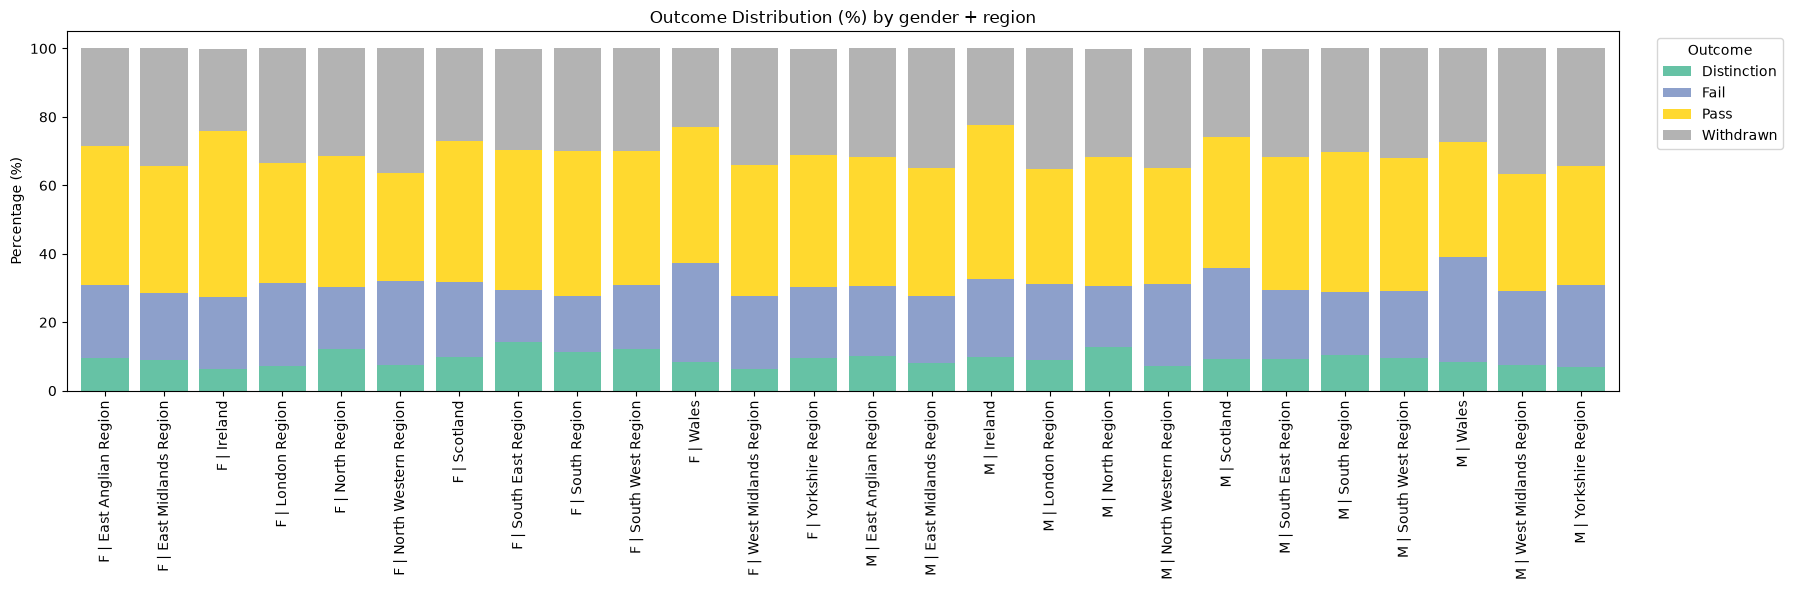

In [462]:
# Outcome Distribution by Gender and Region

gender_region_summary = outcome_distribution(
    df_students,
    ["gender", "region"]
)

display(gender_region_summary)

plot_outcome_distribution(
    gender_region_summary,
    ["gender", "region"]
)

In [463]:
gender_region_outcome_summary = outcome_summary(
    gender_region_summary,
    ["gender", "region"]
)

display(gender_region_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,F | South East Region,14.21,F | Ireland,6.25
1,Fail,M | Wales,30.58,F | South East Region,15.11
2,Pass,F | Ireland,48.48,F | North Western Region,31.70
3,Withdrawn,M | West Midlands Region,36.57,M | Ireland,22.26


### Outcome Distribution Summary

The percentage distribution of Distinction, Pass, Fail, and Withdrawn outcomes was compared across Gender and Region combinations.

The table above identifies the demographic groups with the highest and lowest percentages for each academic outcome. Variations in these percentages indicate that student outcomes are not uniformly distributed across all gender-region groups.

The stacked percentage bar chart further illustrates these differences, enabling comparison of the complete outcome distribution rather than individual outcomes in isolation.

Overall, the analysis suggests that demographic characteristics may influence academic performance and retention, although the magnitude of these differences varies across regions.

In [464]:
gender_region_withdrawal = withdrawal_analysis(
    df_students,
    ["gender", "region"]
)

display(gender_region_withdrawal)

,gender,region,Total_Students,Withdrawn,Withdrawal Rate (%)
24,M,West Midlands Region,1400,512,36.57
5,F,North Western Region,1221,444,36.36
16,M,London Region,1703,602,35.35
14,M,East Midlands Region,1228,430,35.02
18,M,North Western Region,1685,590,35.01
1,F,East Midlands Region,1137,392,34.48
25,M,Yorkshire Region,1058,363,34.31
11,F,West Midlands Region,1182,401,33.93
3,F,London Region,1513,508,33.58
22,M,South West Region,1291,414,32.07


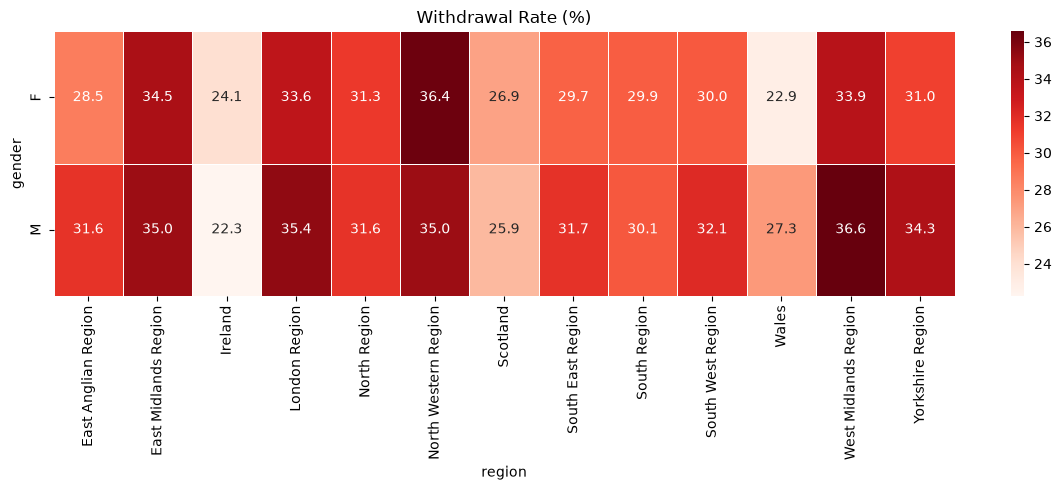

In [465]:
plot_withdrawal_heatmap(
    gender_region_withdrawal,
    "gender",
    "region"
)

In [466]:
print("Top 5 Highest Withdrawal Groups")

display(
    gender_region_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,gender,region,Total_Students,Withdrawn,Withdrawal Rate (%)
24,M,West Midlands Region,1400,512,36.57
5,F,North Western Region,1221,444,36.36
16,M,London Region,1703,602,35.35
14,M,East Midlands Region,1228,430,35.02
18,M,North Western Region,1685,590,35.01


In [467]:
print("Top 5 Lowest Withdrawal Groups")

display(
    gender_region_withdrawal.tail(5)
    .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,gender,region,Total_Students,Withdrawn,Withdrawal Rate (%)
15,M,Ireland,656,146,22.26
10,F,Wales,1043,239,22.91
2,F,Ireland,528,127,24.05
19,M,Scotland,2039,528,25.90
6,F,Scotland,1407,379,26.94


### Withdrawal Analysis Summary

Withdrawal rates were further analysed to identify demographic groups at greater risk of student dropout.

The heatmap and ranked tables indicate which gender-region combinations recorded the highest and lowest withdrawal rates.

Higher withdrawal percentages may indicate student groups requiring additional academic support or intervention, whereas lower withdrawal percentages suggest comparatively better student retention.

These findings provide useful insight into demographic patterns associated with student dropout and support the inclusion of gender and region as predictive variables in the subsequent machine learning models.

### Interpretation

Withdrawal rates ranged from 22.3% to 36.6%, indicating noticeable differences across gender-region combinations.

Male students in the West Midlands Region recorded the highest withdrawal rate (36.6%), followed by female students in the North Western Region (36.4%). These groups represent the highest-risk student populations within this analysis.

Ireland exhibited the lowest withdrawal rates for both genders (22.3% for males and 24.1% for females), suggesting comparatively better student retention in this region.

For several regions, withdrawal rates were relatively similar between male and female students. However, some regions showed noticeable gender differences. For example:

Yorkshire Region: Male = 34.3%, Female = 31.0% (higher among males)

Wales: Male = 27.3%, Female = 22.9% (higher among males)

North Western Region: Female = 36.4%, Male = 35.0% (slightly higher among females)

Regions such as East Midlands, London, North Region, and South Region displayed only small differences (generally within 1–2 percentage points) between genders, indicating that gender alone may not explain variations in withdrawal rates in these regions.

Key Findings

Highest Withdrawal Rate: Male – West Midlands Region (36.6%)

Second Highest: Female – North Western Region (36.4%)

Lowest Withdrawal Rate: Male – Ireland (22.3%)

Overall Pattern: Regional variation appears to be more pronounced than gender differences, although certain gender-region 
combinations exhibit elevated withdrawal rates.
Conclusion

The analysis suggests that withdrawal rates vary across combinations of gender and region, indicating that student dropout risk is influenced by the interaction of demographic and geographic factors rather than gender alone. While many regions show comparable withdrawal rates between male and female students, specific combinations—such as Male–West Midlands Region and Female–North Western Region—experience substantially higher withdrawal rates. These findings support the inclusion of both gender and region as predictive features in the student dropout prediction model and may help institutions identify demographic groups that could benefit from targeted retention strategies.

# Gender × Age Band

### Objective

This analysis examines whether the distribution of student outcomes varies across combinations of gender and age band. Percentage-based outcome distributions are analysed to identify potential demographic bias that may not be visible when gender or age is analysed independently.

As the primary objective of this project is student dropout prediction, withdrawal rates are also analysed separately to identify high-risk demographic groups.

In [468]:
# Outcome Distribution by Gender and Age Band

gender_age_summary = outcome_distribution(
    df_students,
    ["gender", "age_band"]
)

display(gender_age_summary)

,gender,age_band,Distinction,Fail,Pass,Withdrawn,Total Students
0,F,0-35,8.13,22.40,37.56,31.91,10118
1,F,35-55,12.45,18.16,42.09,27.30,4571
2,F,55<=,6.90,24.14,37.93,31.03,29
3,M,0-35,8.11,23.12,36.40,32.37,12826
4,M,35-55,11.33,19.79,38.58,30.30,4862
5,M,55<=,20.86,11.76,43.32,24.06,187


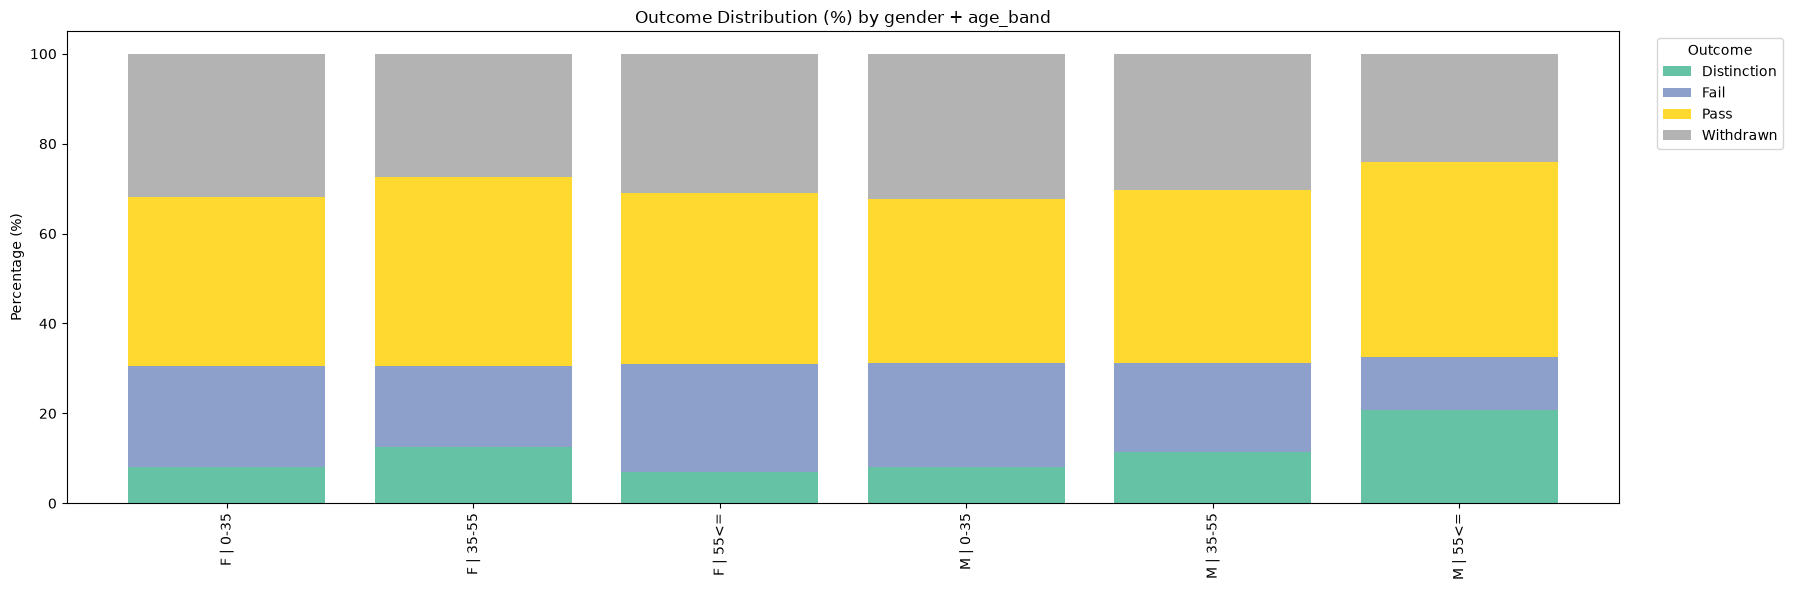

In [469]:
plot_outcome_distribution(
    gender_age_summary,
    ["gender", "age_band"]
)

In [470]:
gender_age_outcome_summary = outcome_summary(
    gender_age_summary,
    ["gender", "age_band"]
)

display(gender_age_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,M | 55<=,20.86,F | 55<=,6.90
1,Fail,F | 55<=,24.14,M | 55<=,11.76
2,Pass,M | 55<=,43.32,M | 0-35,36.40
3,Withdrawn,M | 0-35,32.37,M | 55<=,24.06


### Outcome Distribution Summary

The percentage distribution of Distinction, Pass, Fail, and Withdrawn outcomes was compared across Gender and Age Band combinations.

The outcome summary table highlights the demographic groups with the highest and lowest percentages for each academic outcome. The stacked percentage bar chart enables comparison of the complete outcome distribution across different age groups within each gender.

Variations observed across age bands indicate that age may influence academic performance and retention differently for male and female students.

In [471]:
#Withdrawal Analysis
gender_age_withdrawal = withdrawal_analysis(
    df_students,
    ["gender", "age_band"]
)

display(gender_age_withdrawal)

,gender,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
3,M,0-35,12826,4152,32.37
0,F,0-35,10118,3229,31.91
2,F,55<=,29,9,31.03
4,M,35-55,4862,1473,30.30
1,F,35-55,4571,1248,27.30
5,M,55<=,187,45,24.06


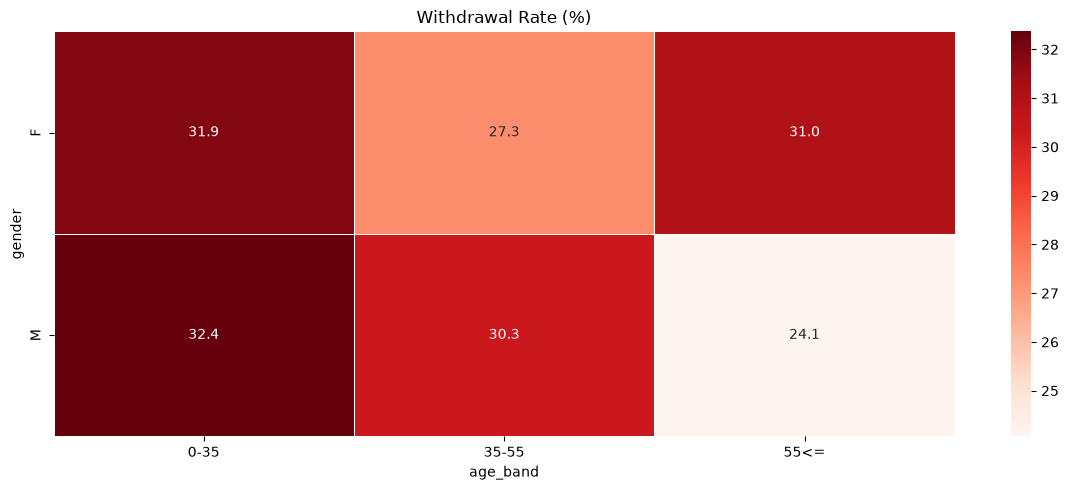

In [472]:
#Withdrawal Heatmap
plot_withdrawal_heatmap(
    gender_age_withdrawal,
    "gender",
    "age_band"
)

In [473]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    gender_age_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,gender,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
3,M,0-35,12826,4152,32.37
0,F,0-35,10118,3229,31.91
2,F,55<=,29,9,31.03
4,M,35-55,4862,1473,30.30
1,F,35-55,4571,1248,27.30


In [474]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    gender_age_withdrawal.tail(5)
        .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,gender,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
5,M,55<=,187,45,24.06
1,F,35-55,4571,1248,27.30
4,M,35-55,4862,1473,30.30
2,F,55<=,29,9,31.03
0,F,0-35,10118,3229,31.91


### Withdrawal Analysis Summary


Withdrawal rates were analysed across combinations of gender and age band to identify demographic groups with a higher risk of student dropout.

Withdrawal rates ranged from 24.1% to 32.4% across the different gender-age combinations, indicating moderate variation in dropout risk.
Male students aged 0–35 years recorded the highest withdrawal rate (32.4%), closely followed by female students aged 0–35 years (31.9%). This suggests that younger learners, regardless of gender, are more likely to withdraw from their courses.
Among students aged 35–55 years, withdrawal rates decreased to 30.3% for males and 27.3% for females, indicating improved retention compared with the younger age group.
The lowest withdrawal rate (24.1%) was observed among male students aged 55 years and above, suggesting that older learners are comparatively more likely to complete their courses.
Female students aged 55 years and above recorded a withdrawal rate of 31.0%, which is noticeably higher than their male counterparts (24.1%). This indicates that the relationship between age and withdrawal differs between genders in the oldest age group.

Key Findings
Highest Withdrawal Rate: Male students aged 0–35 years (32.4%)
Second Highest: Female students aged 0–35 years (31.9%)
Lowest Withdrawal Rate: Male students aged 55 years and above (24.1%)
Withdrawal rates generally decrease with increasing age among male students, whereas the same trend is not consistently observed among female students, particularly in the 55 years and above category.

Conclusion

The analysis indicates that student withdrawal rates vary across combinations of gender and age band, with younger learners exhibiting a greater risk of dropout than older learners. While both genders experience relatively high withdrawal rates in the 0–35 years age group, older male learners demonstrate substantially better retention than older female learners. These findings suggest that age interacts with gender in influencing student dropout, supporting the inclusion of both variables in the predictive modelling stage.

Note: These observations are descriptive and identify associations within the dataset. They do not imply that age or gender directly causes higher withdrawal rates. Further statistical analysis and machine learning models are required to quantify the contribution of these variables to dropout prediction.


The largest gender difference was observed in the 55 years and above age group, where female students had a withdrawal rate approximately 6.9 percentage points higher than male students (31.0% vs. 24.1%). In contrast, withdrawal rates were very similar between males and females in the 0–35 years age group (32.4% vs. 31.9%).

## Gender × Highest Education

### Objective

This analysis investigates whether the distribution of student outcomes differs across combinations of gender and highest education level. Comparing outcome percentages across these demographic groups helps identify whether prior educational attainment influences academic performance and student retention differently for male and female learners.

As student dropout prediction is the primary objective of this project, withdrawal rates are also analysed separately to identify education-related high-risk groups.

In [475]:
# Outcome Distribution by Gender and Highest Education

gender_edu_summary = outcome_distribution(
    df_students,
    ["gender", "highest_education"]
)

display(gender_edu_summary)

,gender,highest_education,Distinction,Fail,Pass,Withdrawn,Total Students
0,F,A Level or Equivalent,11.18,17.69,42.93,28.20,6359
1,F,HE Qualification,15.55,15.60,40.76,28.10,1801
2,F,Lower Than A Level,5.91,26.05,34.83,33.22,6262
3,F,No Formal quals,3.86,26.09,27.05,43.00,207
4,F,Post Graduate Qualification,28.09,13.48,38.20,20.22,89
5,M,A Level or Equivalent,10.21,20.58,40.10,29.10,7686
6,M,HE Qualification,14.24,17.38,41.86,26.53,2929
7,M,Lower Than A Level,5.18,26.03,31.96,36.83,6896
8,M,No Formal quals,5.71,29.29,22.14,42.86,140
9,M,Post Graduate Qualification,28.12,9.82,37.05,25.00,224


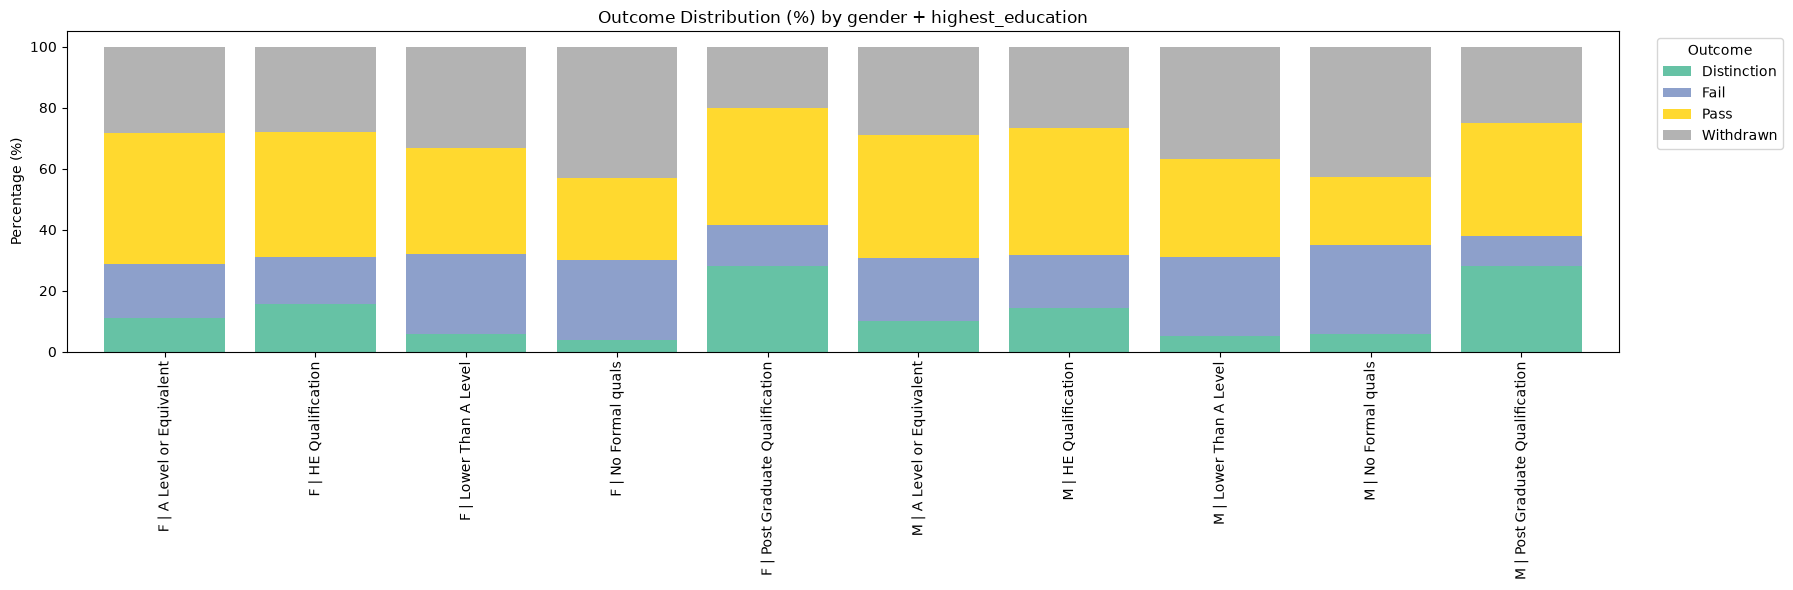

In [476]:
plot_outcome_distribution(
    gender_edu_summary,
    ["gender", "highest_education"]
)

In [477]:
gender_edu_outcome_summary = outcome_summary(
    gender_edu_summary,
    ["gender", "highest_education"]
)

display(gender_edu_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,M | Post Graduate Qualification,28.12,F | No Formal quals,3.86
1,Fail,M | No Formal quals,29.29,M | Post Graduate Qualification,9.82
2,Pass,F | A Level or Equivalent,42.93,M | No Formal quals,22.14
3,Withdrawn,F | No Formal quals,43.00,F | Post Graduate Qualification,20.22


### Outcome Distribution Summary

The percentage distribution of Distinction, Pass, Fail, and Withdrawn outcomes was compared across combinations of gender and highest education level.

The outcome summary table identifies the demographic groups with the highest and lowest percentages for each academic outcome. The stacked percentage bar chart provides a comprehensive comparison of outcome distributions across different educational backgrounds within each gender.

Differences in outcome distributions across education levels may indicate that prior educational attainment influences academic success and student retention.

In [478]:
#Withdrawal Analysis
gender_edu_withdrawal = withdrawal_analysis(
    df_students,
    ["gender", "highest_education"]
)

display(gender_edu_withdrawal)

,gender,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
3,F,No Formal quals,207,89,43.00
8,M,No Formal quals,140,60,42.86
7,M,Lower Than A Level,6896,2540,36.83
2,F,Lower Than A Level,6262,2080,33.22
5,M,A Level or Equivalent,7686,2237,29.10
0,F,A Level or Equivalent,6359,1793,28.20
1,F,HE Qualification,1801,506,28.10
6,M,HE Qualification,2929,777,26.53
9,M,Post Graduate Qualification,224,56,25.00
4,F,Post Graduate Qualification,89,18,20.22


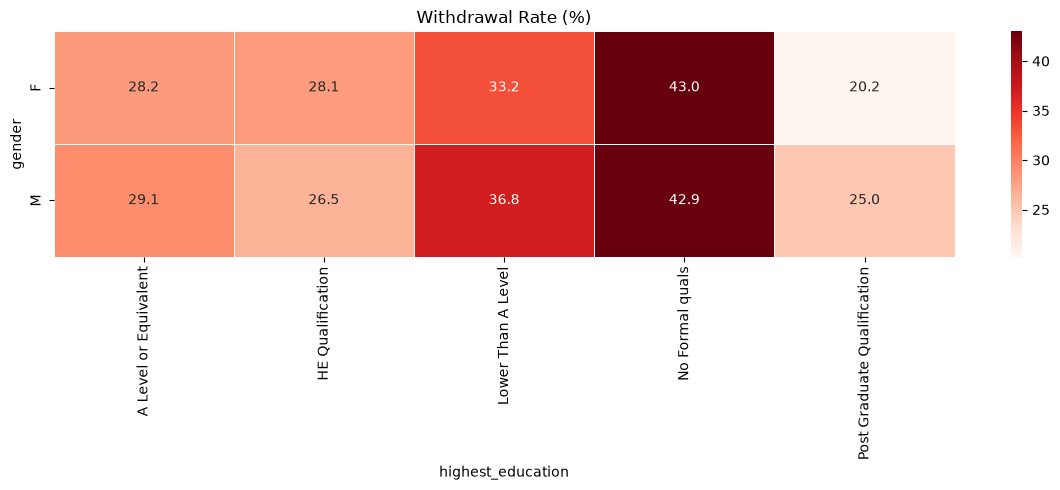

In [479]:
#Withdrawal Heatmap
plot_withdrawal_heatmap(
    gender_edu_withdrawal,
    "gender",
    "highest_education"
)

In [480]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    gender_edu_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,gender,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
3,F,No Formal quals,207,89,43.00
8,M,No Formal quals,140,60,42.86
7,M,Lower Than A Level,6896,2540,36.83
2,F,Lower Than A Level,6262,2080,33.22
5,M,A Level or Equivalent,7686,2237,29.10


In [481]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    gender_edu_withdrawal.tail(5)
    .sort_values("Withdrawal Rate (%)")
)


Top 5 Lowest Withdrawal Groups


,gender,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
4,F,Post Graduate Qualification,89,18,20.22
9,M,Post Graduate Qualification,224,56,25.00
6,M,HE Qualification,2929,777,26.53
1,F,HE Qualification,1801,506,28.10
0,F,A Level or Equivalent,6359,1793,28.20


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **gender** and **highest education level** to investigate whether prior educational attainment influences student dropout risk.

- Withdrawal rates ranged from **20.2%** to **43.0%**, indicating substantial variation across different education levels.
- Students with **No Formal Qualifications** recorded the highest withdrawal rates for both genders (**43.0% for females** and **42.9% for males**), making this the highest-risk educational group.
- Students with a **Post Graduate Qualification** exhibited the lowest withdrawal rates (**20.2% for females** and **25.0% for males**), suggesting that higher educational attainment is associated with better student retention.
- Students with **Lower Than A Level** qualifications also demonstrated relatively high withdrawal rates (**33.2% for females** and **36.8% for males**), indicating that learners with lower educational backgrounds are more likely to withdraw.
- Withdrawal rates for students with **A Level or Equivalent** and **HE Qualification** were comparatively moderate, ranging between **26.5%** and **29.1%**, with only small differences observed between male and female students.

### Key Findings

- **Highest Withdrawal Rate:** Female students with **No Formal Qualifications (43.0%)**
- **Second Highest Withdrawal Rate:** Male students with **No Formal Qualifications (42.9%)**
- **Lowest Withdrawal Rate:** Female students with a **Post Graduate Qualification (20.2%)**
- Students with **No Formal Qualifications** consistently exhibited the highest withdrawal rates, while those with **Post Graduate Qualifications** demonstrated the lowest withdrawal rates across both genders.
- Educational background appears to have a stronger influence on withdrawal rates than gender, as students within the same education category showed relatively similar withdrawal percentages.

### Interpretation

The analysis demonstrates that **student withdrawal rates vary considerably across combinations of gender and highest education level**, with prior educational attainment showing a strong association with student retention. Learners with **No Formal Qualifications** and **Lower Than A Level** qualifications consistently experienced the highest withdrawal rates, whereas students holding **Post Graduate Qualifications** exhibited the lowest dropout risk.

Although minor gender differences exist within some education levels, these differences are relatively small compared with the variation observed across education categories. A clear trend is evident across both genders, where withdrawal rates generally decrease as the level of prior educational attainment increases. This suggests that students entering online learning with stronger educational backgrounds may be better prepared for academic demands and are therefore more likely to complete their courses.

Overall, these findings indicate that **highest education level is an important predictor of student dropout** and should be included as a key feature in the predictive modelling stage.

> **Note:** These observations are descriptive and indicate associations within the dataset. They should not be interpreted as evidence of a causal relationship between educational attainment and student withdrawal. Further statistical analysis and predictive modelling are required to evaluate the contribution of this variable to dropout prediction.

## Gender × IMD Band

### Objective

This analysis investigates whether the distribution of student outcomes varies across combinations of gender and Index of Multiple Deprivation (IMD) band. The IMD band is a socioeconomic indicator representing the relative level of deprivation in a student's residential area.

By comparing the percentage distribution of academic outcomes across gender and IMD bands, this analysis aims to identify potential socioeconomic bias in student performance and retention.

As student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify high-risk socioeconomic groups.

In [482]:
# Outcome Distribution by Gender and IMD Band

gender_imd_summary = outcome_distribution(
    df_students,
    ["gender", "imd_band"]
)

display(gender_imd_summary)

,gender,imd_band,Distinction,Fail,Pass,Withdrawn,Total Students
0,F,0-10%,5.39,29.07,31.13,34.41,1706
1,F,10-20,5.98,25.19,34.88,33.95,1723
2,F,20-30%,6.64,21.79,35.51,36.06,1822
3,F,30-40%,9.20,20.90,39.99,29.91,1598
4,F,40-50%,10.08,19.78,39.17,30.97,1537
5,F,50-60%,10.48,21.10,40.83,27.59,1450
6,F,60-70%,11.07,19.37,41.05,28.52,1301
7,F,70-80%,10.34,20.02,43.90,25.74,1189
8,F,80-90%,13.31,15.44,43.83,27.42,1127
9,F,90-100%,15.59,13.62,44.59,26.20,962


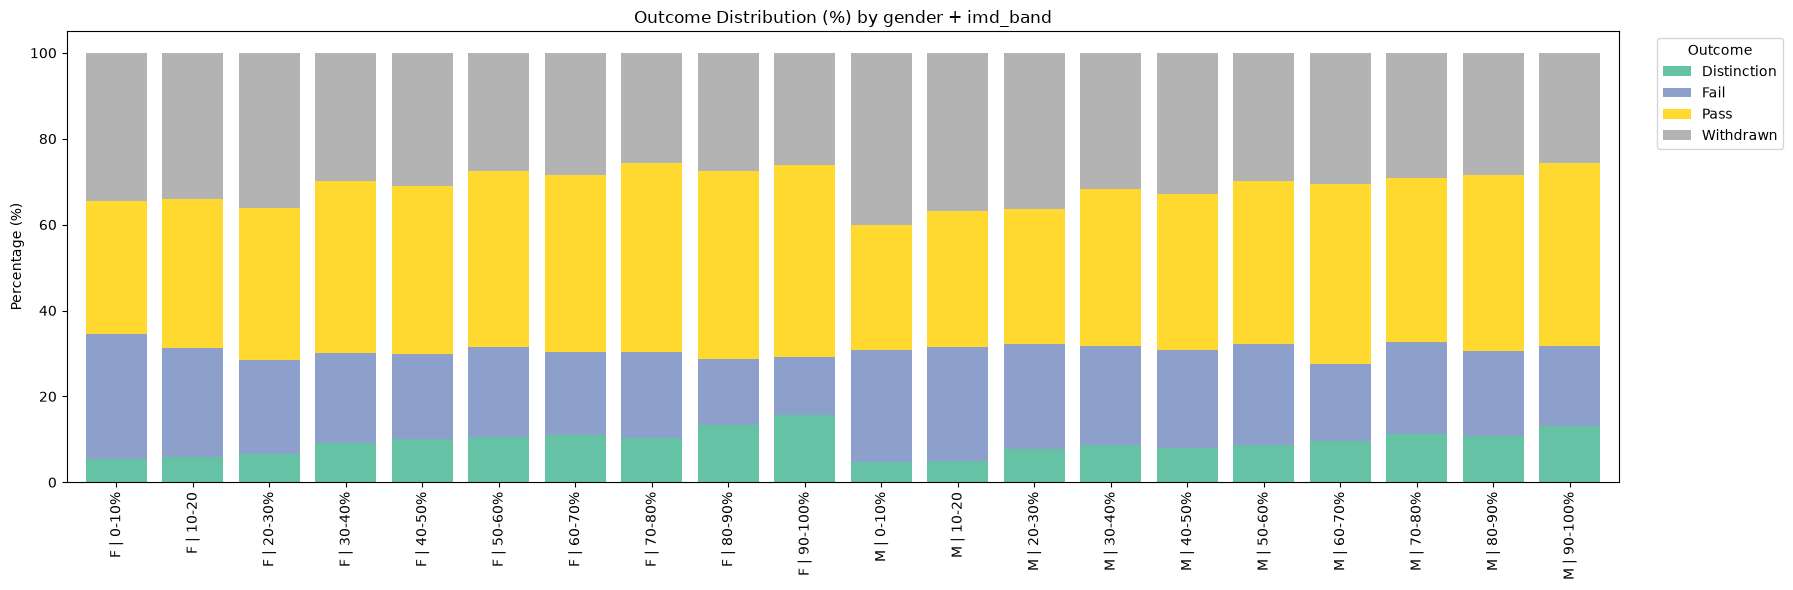

In [483]:
#Outcome Distribution Plot
plot_outcome_distribution(
    gender_imd_summary,
    ["gender", "imd_band"]
)

In [484]:
#Outcome Summary
gender_imd_outcome_summary = outcome_summary(
    gender_imd_summary,
    ["gender", "imd_band"]
)

display(gender_imd_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,F | 90-100%,15.59,M | 0-10%,4.74
1,Fail,F | 0-10%,29.07,F | 90-100%,13.62
2,Pass,F | 90-100%,44.59,M | 0-10%,28.97
3,Withdrawn,M | 0-10%,40.12,M | 90-100%,25.67


### Outcome Distribution Summary

The percentage distribution of Distinction, Pass, Fail, and Withdrawn outcomes was compared across combinations of gender and IMD band.

The outcome summary table identifies the demographic groups with the highest and lowest percentages for each academic outcome, while the stacked percentage bar chart illustrates differences in outcome distributions across socioeconomic groups.

Variations observed across IMD bands may indicate that socioeconomic conditions influence student performance and course completion.

In [485]:
#Withdrawal Analysis

gender_imd_withdrawal = withdrawal_analysis(
    df_students,
    ["gender", "imd_band"]
)

display(gender_imd_withdrawal)

,gender,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
10,M,0-10%,1605,644,40.12
11,M,10-20,1793,661,36.87
12,M,20-30%,1832,664,36.24
2,F,20-30%,1822,657,36.06
0,F,0-10%,1706,587,34.41
1,F,10-20,1723,585,33.95
14,M,40-50%,1719,566,32.93
13,M,30-40%,1941,617,31.79
4,F,40-50%,1537,476,30.97
16,M,60-70%,1604,488,30.42


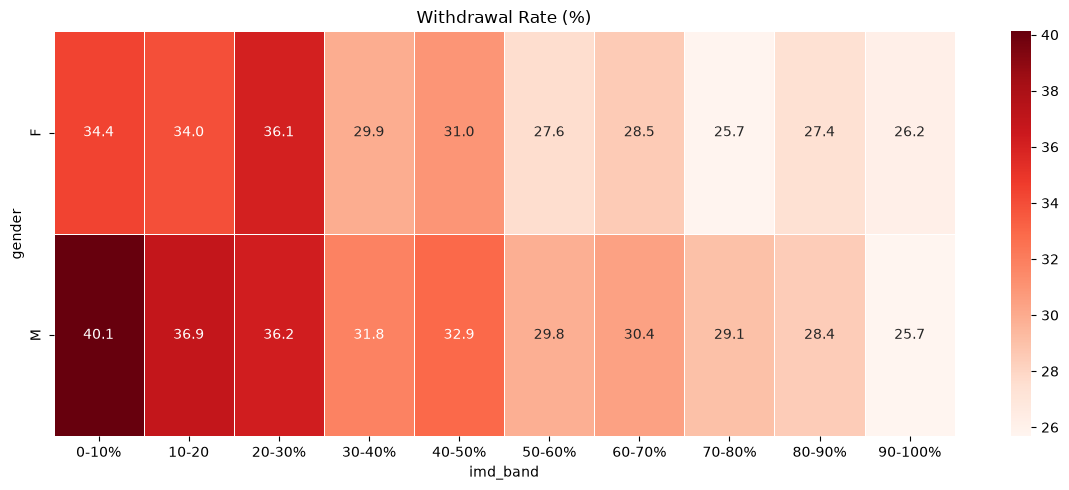

In [486]:
#Withdrawal Heatmap
plot_withdrawal_heatmap(
    gender_imd_withdrawal,
    "gender",
    "imd_band"
)

In [487]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    gender_imd_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,gender,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
10,M,0-10%,1605,644,40.12
11,M,10-20,1793,661,36.87
12,M,20-30%,1832,664,36.24
2,F,20-30%,1822,657,36.06
0,F,0-10%,1706,587,34.41


In [488]:
#op 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    gender_imd_withdrawal.tail(5)
          .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,gender,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
19,M,90-100%,1574,404,25.67
7,F,70-80%,1189,306,25.74
9,F,90-100%,962,252,26.20
8,F,80-90%,1127,309,27.42
5,F,50-60%,1450,400,27.59


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **gender** and **Index of Multiple Deprivation (IMD) band** to investigate whether socioeconomic background is associated with student dropout.

- Withdrawal rates ranged from **25.7%** to **40.1%**, indicating noticeable variation across different socioeconomic groups.
- **Male students in the 0–10% IMD band** recorded the **highest withdrawal rate (40.1%)**, followed by **male students in the 10–20% IMD band (36.9%)** and **male students in the 20–30% IMD band (36.2%)**.
- Among female students, the highest withdrawal rate was observed in the **20–30% IMD band (36.1%)**, followed by the **0–10% IMD band (34.4%)**.
- The **lowest withdrawal rates** were observed in the **90–100% IMD band**, with **25.7% for males** and **26.2% for females**, indicating comparatively better student retention in the least deprived socioeconomic groups.
- Across both genders, withdrawal rates generally declined as the IMD band increased from **0–10%** to **90–100%**, suggesting an inverse relationship between socioeconomic advantage and student dropout.

### Key Findings

- **Highest Withdrawal Rate:** Male students from the **0–10% IMD band (40.1%)**
- **Highest Female Withdrawal Rate:** Female students from the **20–30% IMD band (36.1%)**
- **Lowest Withdrawal Rate:** Male students from the **90–100% IMD band (25.7%)**
- Students belonging to **more deprived IMD bands (0–30%)** consistently exhibited higher withdrawal rates than those from **less deprived IMD bands (70–100%)**.
- Male students generally recorded slightly higher withdrawal rates than female students across most IMD bands; however, the differences between socioeconomic groups were more pronounced than the differences between genders.

### Interpretation

The analysis indicates that **student withdrawal rates vary across combinations of gender and IMD band**, with socioeconomic background showing a clear association with student retention. Students residing in **more deprived areas (0–30% IMD bands)** consistently experienced higher withdrawal rates, whereas students from **less deprived areas (70–100% IMD bands)** demonstrated lower dropout rates.

Although male students generally exhibited marginally higher withdrawal rates than female students across most deprivation bands, the variation associated with **IMD band** was substantially greater than the variation associated with **gender**. This suggests that socioeconomic status may have a stronger influence on student dropout than gender alone.

Overall, these findings indicate that **IMD band is an important socioeconomic predictor of student dropout** and should be included as a key feature in the predictive modelling stage to improve the identification of high-risk student groups.

> **Note:** These findings describe associations observed within the dataset and should not be interpreted as evidence of a causal relationship between socioeconomic status and student withdrawal. Further statistical analysis and predictive modelling are required to quantify the contribution of IMD band to dropout prediction.

## Gender × Disability

### Objective

This analysis examines whether the distribution of student outcomes differs across combinations of gender and disability status. Disability is an important demographic characteristic that may influence student engagement, academic performance, and course completion.

By analysing outcome distributions across gender and disability status, this section aims to identify potential differences in academic outcomes and student retention among these demographic groups.

As student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify whether disability status is associated with an increased risk of student withdrawal.

In [489]:
# Outcome Distribution by Gender and Disability

gender_disability_summary = outcome_distribution(
    df_students,
    ["gender", "disability"]
)

display(gender_disability_summary)

,gender,disability,Distinction,Fail,Pass,Withdrawn,Total Students
0,F,N,9.67,21.02,39.65,29.66,13097
1,F,Y,7.83,21.59,33.44,37.14,1621
2,M,N,9.39,21.96,37.86,30.78,16332
3,M,Y,6.22,23.46,28.65,41.67,1543


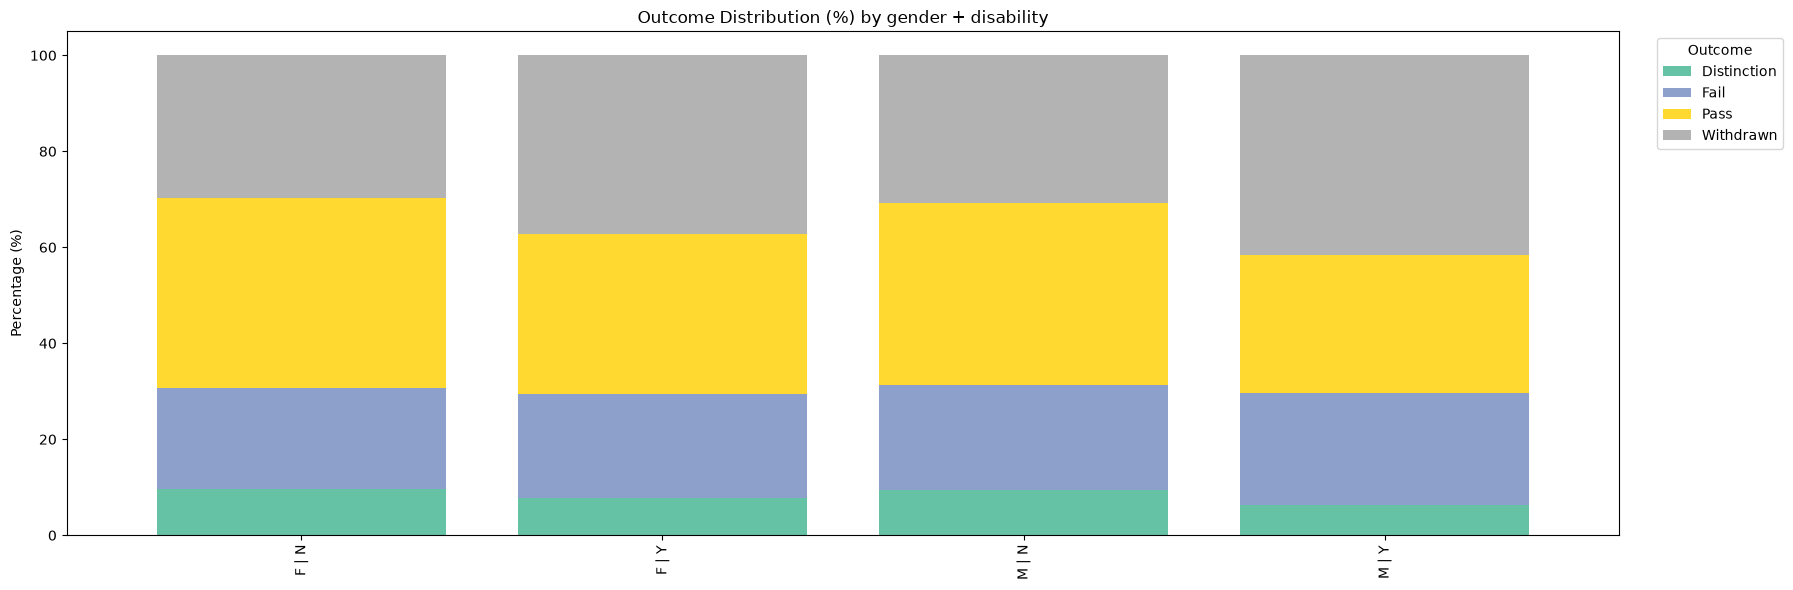

In [490]:
#Outcome Distribution Plot
plot_outcome_distribution(
    gender_disability_summary,
    ["gender", "disability"]
)

In [491]:
#Outcome Summary
gender_disability_outcome_summary = outcome_summary(
    gender_disability_summary,
    ["gender", "disability"]
)

display(gender_disability_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,F | N,9.67,M | Y,6.22
1,Fail,M | Y,23.46,F | N,21.02
2,Pass,F | N,39.65,M | Y,28.65
3,Withdrawn,M | Y,41.67,F | N,29.66


### Outcome Distribution Summary

The percentage distribution of Distinction, Pass, Fail, and Withdrawn outcomes was compared across combinations of gender and disability status.

The outcome summary table identifies the demographic groups with the highest and lowest percentages for each academic outcome, while the stacked percentage bar chart illustrates differences in outcome distributions between students with and without disabilities.

Variations observed across disability groups may indicate whether disability status influences academic performance and student retention.


In [492]:
#Withdrawal Analysis
gender_disability_withdrawal = withdrawal_analysis(
    df_students,
    ["gender", "disability"]
)

display(gender_disability_withdrawal)


,gender,disability,Total_Students,Withdrawn,Withdrawal Rate (%)
3,M,Y,1543,643,41.67
1,F,Y,1621,602,37.14
2,M,N,16332,5027,30.78
0,F,N,13097,3884,29.66


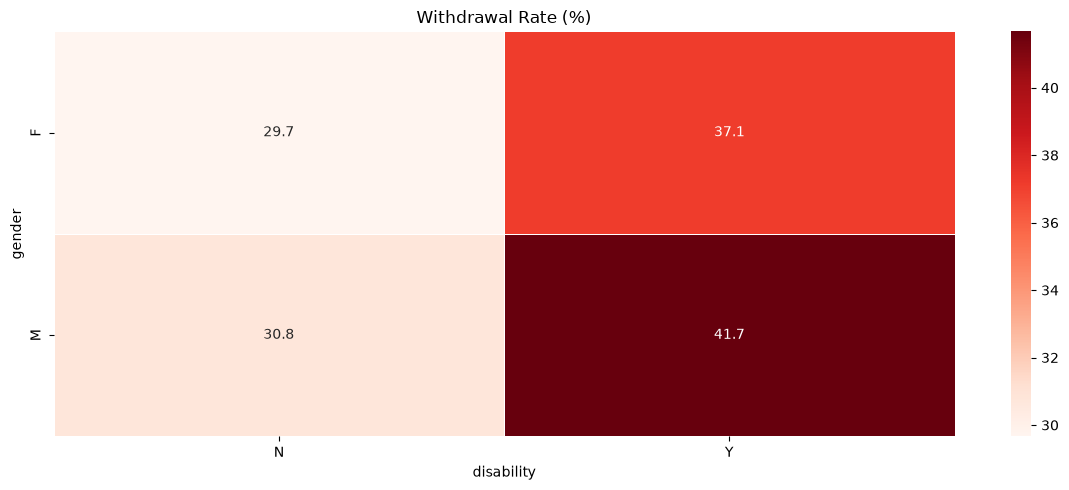

In [493]:
# Withdrawal Heatmap
plot_withdrawal_heatmap(
    gender_disability_withdrawal,
    "gender",
    "disability"
)

In [494]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    gender_disability_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,gender,disability,Total_Students,Withdrawn,Withdrawal Rate (%)
3,M,Y,1543,643,41.67
1,F,Y,1621,602,37.14
2,M,N,16332,5027,30.78
0,F,N,13097,3884,29.66


In [495]:
# Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    gender_disability_withdrawal.tail(5)
    .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,gender,disability,Total_Students,Withdrawn,Withdrawal Rate (%)
0,F,N,13097,3884,29.66
2,M,N,16332,5027,30.78
1,F,Y,1621,602,37.14
3,M,Y,1543,643,41.67


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **gender** and **disability status** to investigate whether disability is associated with student dropout.

- Withdrawal rates ranged from **29.7%** to **41.7%**, indicating a noticeable difference between students with and without disabilities.
- Students reporting a **disability (Y)** consistently exhibited higher withdrawal rates than students without a disability (N) across both genders.
- **Male students with a disability** recorded the **highest withdrawal rate (41.7%)**, followed by **female students with a disability (37.1%)**, making these the highest-risk demographic groups in this analysis.
- Among students **without a disability**, withdrawal rates were considerably lower, with **30.8% for males** and **29.7% for females**.
- The difference in withdrawal rates between students with and without disabilities was **7.4 percentage points for females** (37.1% vs. 29.7%) and **10.9 percentage points for males** (41.7% vs. 30.8%), suggesting that disability status has a substantial association with student retention.

### Key Findings

- **Highest Withdrawal Rate:** Male students with a **disability (41.7%)**
- **Second Highest Withdrawal Rate:** Female students with a **disability (37.1%)**
- **Lowest Withdrawal Rate:** Female students **without a disability (29.7%)**
- Students with disabilities consistently exhibited higher withdrawal rates than students without disabilities, regardless of gender.
- The impact of disability status on withdrawal appears to be more pronounced than the differences observed between male and female students within the same disability category.

### Interpretation

The analysis indicates that **student withdrawal rates vary across combinations of gender and disability status**, with disability showing a clear association with increased dropout risk. Both male and female students reporting a disability experienced substantially higher withdrawal rates than their counterparts without a disability.

Although male students recorded slightly higher withdrawal rates than female students within both disability groups, the difference associated with **disability status** was considerably larger than the difference associated with **gender**. This suggests that disability may have a stronger relationship with student withdrawal than gender alone.

Overall, these findings indicate that **disability status is an important demographic characteristic associated with student dropout** and should be considered as a predictive feature in the subsequent machine learning models. Students with disabilities may benefit from additional academic, accessibility, or support interventions to improve course retention.

> **Note:** These findings are descriptive and identify associations within the dataset. They should not be interpreted as evidence that disability directly causes student withdrawal. Further statistical analysis and predictive modelling are required to determine the significance and predictive contribution of disability status.

## Region × Age Band

### Objective

This analysis examines whether the distribution of student outcomes differs across combinations of **region** and **age band**. While region and age were previously analysed independently, combining these variables provides deeper insight into whether students of different age groups experience varying academic outcomes across regions.

As student dropout prediction is the primary objective of this project, withdrawal rates are also analysed separately to identify regional-age groups that are at a higher risk of withdrawal.

In [496]:
# Outcome Distribution by Region and Age Band

region_age_summary = outcome_distribution(
    df_students,
    ["region", "age_band"]
)

display(region_age_summary)

,region,age_band,Distinction,Fail,Pass,Withdrawn,Total Students
0,East Anglian Region,0-35,8.88,21.85,37.73,31.54,2375
1,East Anglian Region,35-55,12.20,18.61,42.27,26.92,951
2,East Anglian Region,55<=,0.00,14.29,78.57,7.14,14
3,East Midlands Region,0-35,7.66,20.86,35.07,36.41,1711
4,East Midlands Region,35-55,10.55,16.06,42.97,30.43,654
5,Ireland,0-35,7.45,22.85,46.72,22.98,792
6,Ireland,35-55,9.95,20.41,46.43,23.21,392
7,London Region,0-35,7.53,24.32,32.83,35.32,2126
8,London Region,35-55,9.20,20.87,36.91,33.02,1054
9,London Region,55<=,16.67,19.44,33.33,30.56,36


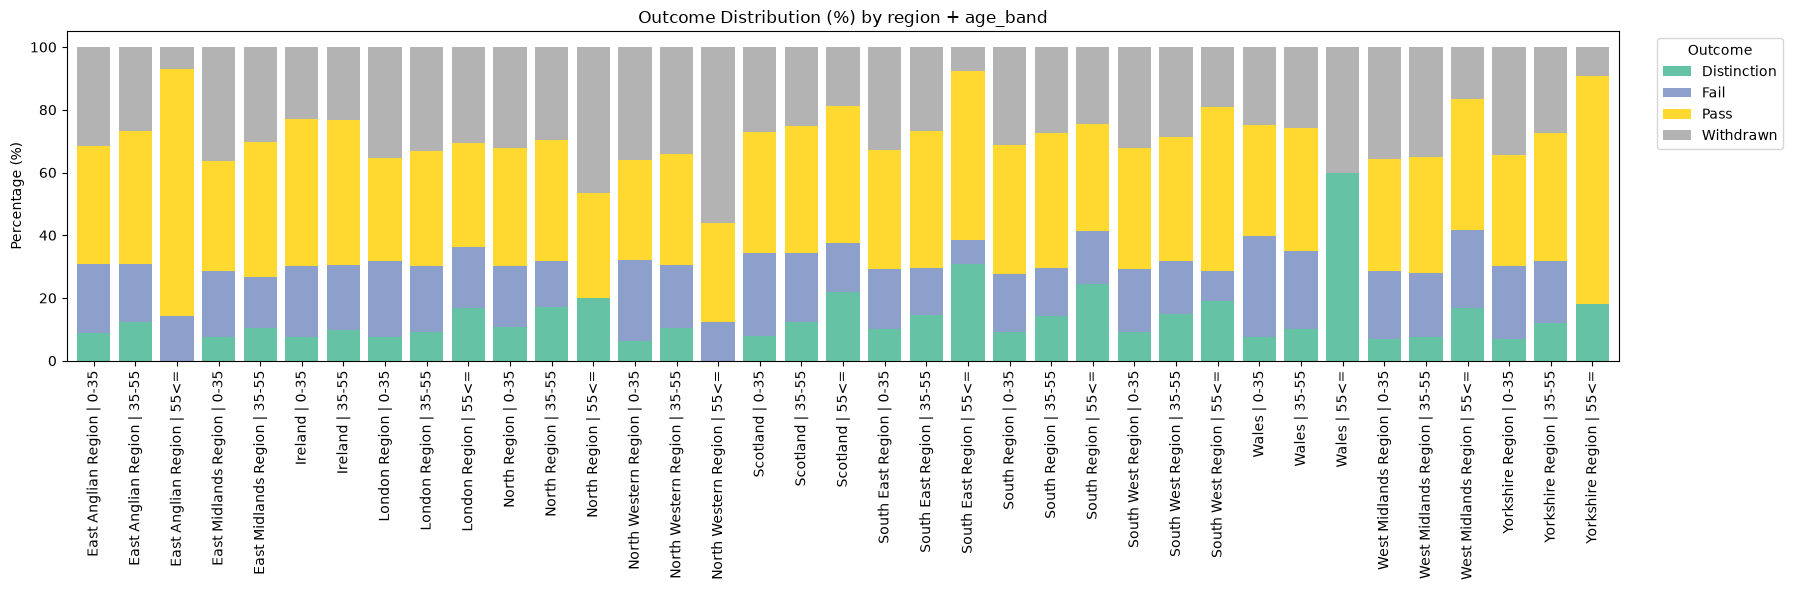

In [497]:
#Outcome Distribution Plot
plot_outcome_distribution(
    region_age_summary,
    ["region", "age_band"]
)

In [498]:
# Outcome Summary
region_age_outcome_summary = outcome_summary(
    region_age_summary,
    ["region", "age_band"]
)

display(region_age_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,Wales | 55<=,60.00,East Anglian Region | 55<=,0.00
1,Fail,Wales | 0-35,32.08,North Region | 55<=,0.00
2,Pass,East Anglian Region | 55<=,78.57,Wales | 55<=,0.00
3,Withdrawn,North Western Region | 55<=,56.25,East Anglian Region | 55<=,7.14


### Outcome Distribution Summary

The percentage distribution of **Distinction, Pass, Fail, and Withdrawn** outcomes was compared across combinations of region and age band.

The outcome summary table identifies the region-age groups with the highest and lowest percentages for each academic outcome. The stacked percentage bar chart illustrates variations in student performance and retention across different age groups within each region.

Differences observed across combinations of region and age band may indicate that geographical location and learner age jointly influence academic outcomes.

In [499]:
#Withdrawal Analysis
region_age_withdrawal = withdrawal_analysis(
    df_students,
    ["region", "age_band"]
)

display(region_age_withdrawal)


,region,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
15,North Western Region,55<=,16,9,56.25
12,North Region,55<=,15,7,46.67
30,Wales,55<=,5,2,40.00
3,East Midlands Region,0-35,1711,623,36.41
13,North Western Region,0-35,2098,754,35.94
31,West Midlands Region,0-35,1991,708,35.56
7,London Region,0-35,2126,751,35.32
32,West Midlands Region,35-55,579,203,35.06
34,Yorkshire Region,0-35,1519,525,34.56
14,North Western Region,35-55,792,271,34.22


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


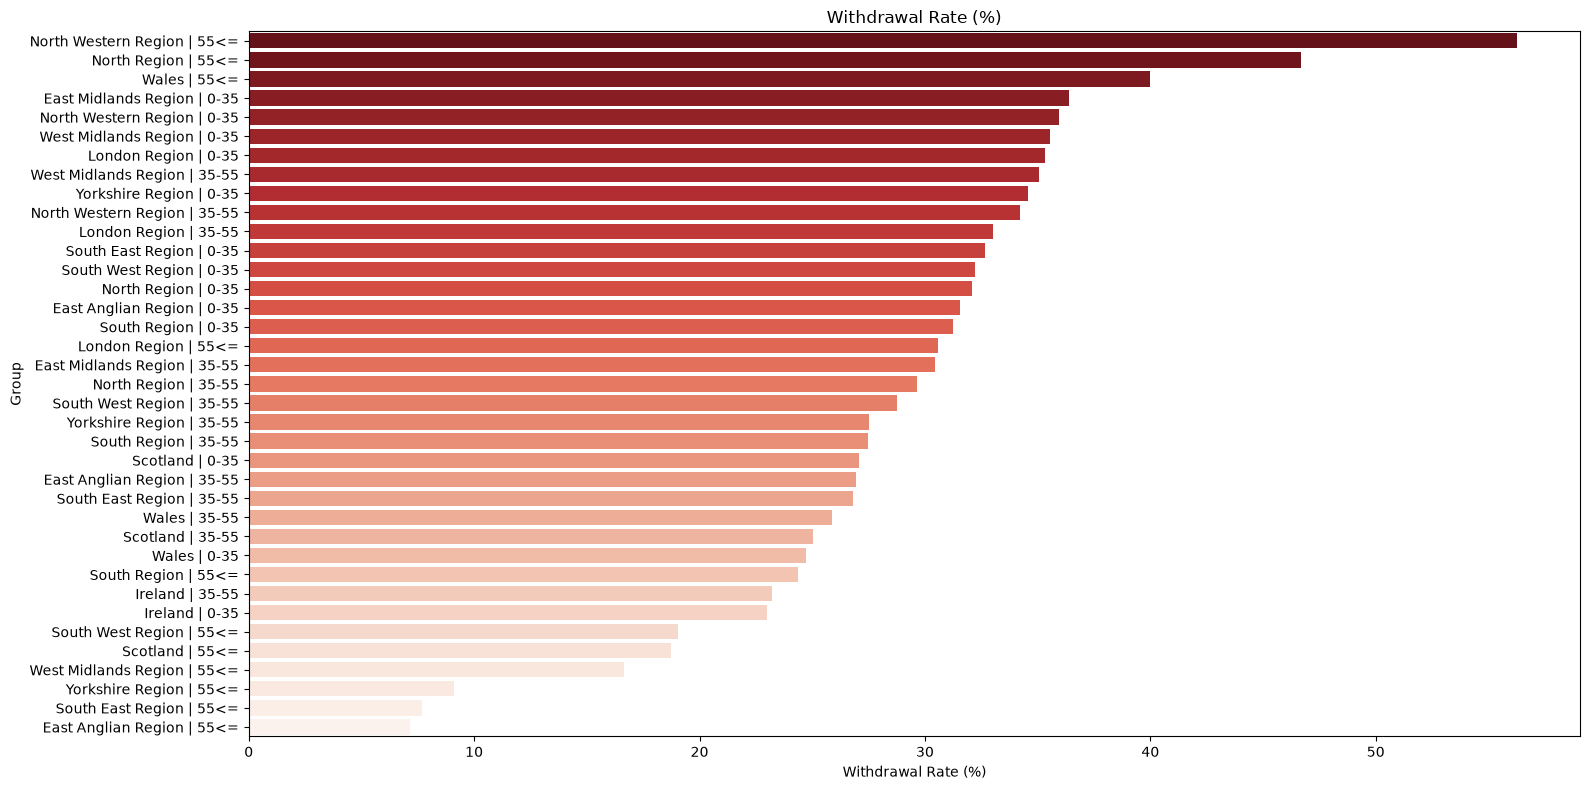

In [500]:
#Withdrawal Visualization
plot_withdrawal_bar(
    region_age_withdrawal,
    ["region", "age_band"]
)

In [501]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    region_age_withdrawal.head(5)
)


Top 5 Highest Withdrawal Groups


,region,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
15,North Western Region,55<=,16,9,56.25
12,North Region,55<=,15,7,46.67
30,Wales,55<=,5,2,40.00
3,East Midlands Region,0-35,1711,623,36.41
13,North Western Region,0-35,2098,754,35.94


In [502]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    region_age_withdrawal.tail(5)
    .sort_values("Withdrawal Rate (%)")
)


Top 5 Lowest Withdrawal Groups


,region,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
2,East Anglian Region,55<=,14,1,7.14
21,South East Region,55<=,13,1,7.69
36,Yorkshire Region,55<=,11,1,9.09
33,West Midlands Region,55<=,12,2,16.67
18,Scotland,55<=,32,6,18.75


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **region** and **age band** to identify regional-age groups with a higher risk of student dropout.

- Withdrawal rates varied considerably across the different region-age combinations, ranging from approximately **7%** to **56%**, indicating substantial differences in student retention across geographical locations and age groups.
- The **highest withdrawal rate** was observed among students aged **55 years and above** from the **North Western Region**, followed by students aged **55 years and above** from the **North Region** and **Wales**. These groups represent the highest-risk student populations in this analysis.
- In contrast, students aged **55 years and above** from the **East Anglian Region**, **South East Region**, and **Yorkshire Region** exhibited the lowest withdrawal rates, indicating comparatively better student retention.
- For the **0–35 years** and **35–55 years** age groups, withdrawal rates were generally clustered between **25% and 40%** across most regions, although notable regional differences were still evident.
- The relationship between age and withdrawal was not consistent across all regions. While students aged **55 years and above** exhibited the highest withdrawal rates in some regions (e.g., North Western Region and North Region), the same age group recorded the **lowest withdrawal rates** in several other regions (e.g., East Anglian Region and South East Region). This suggests that the effect of age on student withdrawal varies depending on geographical location.

### Key Findings

- **Highest Withdrawal Rate:** Students aged **55 years and above** from the **North Western Region**.
- **Second Highest Withdrawal Rate:** Students aged **55 years and above** from the **North Region**.
- **Lowest Withdrawal Rate:** Students aged **55 years and above** from the **East Anglian Region**.
- Regional differences were evident across all age groups, with some regions consistently exhibiting higher withdrawal rates than others.
- The interaction between **region** and **age band** reveals patterns that are not apparent when analysing either variable independently.

### Interpretation

The analysis demonstrates that **student withdrawal rates vary substantially across combinations of region and age band**, indicating that geographical location and learner age jointly influence student retention. Unlike previous analyses where a single variable showed a consistent trend, this interaction reveals that the effect of age differs across regions. Older learners (55 years and above) experienced the highest withdrawal rates in some regions but the lowest withdrawal rates in others, highlighting the importance of considering interaction effects rather than individual variables alone.

These findings suggest that regional factors may influence how different age groups engage with online learning, potentially reflecting differences in learner demographics, access to support, or regional characteristics. Overall, the results support the inclusion of both **region** and **age band** as important predictive features in the student dropout prediction model and demonstrate the value of analysing multivariate interactions to identify high-risk student groups.

> **Note:** These findings describe associations observed within the dataset and should not be interpreted as evidence of a causal relationship between region, age, and student withdrawal. Further statistical analysis and predictive modelling are required to determine the significance and contribution of these variables.

### Additional Observation: Interaction Between Region and Age Band

Unlike the previous multivariate analyses, **Region × Age Band** does not exhibit a single consistent trend across all groups. In earlier analyses such as **Gender × Age Band**, **Gender × Highest Education**, and **Gender × IMD Band**, the withdrawal patterns were relatively consistent. For example:

- Students with **higher educational qualifications** generally exhibited lower withdrawal rates than those with lower educational attainment.
- Students from **more deprived IMD bands** consistently experienced higher withdrawal rates than those from less deprived areas.
- Gender differences were comparatively small, with the secondary variable (education or socioeconomic status) showing a stronger and more consistent relationship with withdrawal.

However, the **Region × Age Band** analysis reveals a different pattern. The effect of **age** on student withdrawal is **not consistent across regions**. For instance, students aged **55 years and above** appear among both the **highest-risk** and **lowest-risk** groups depending on the region. While the **55+ age group** in the **North Western Region** recorded the highest withdrawal rate, the same age group in the **East Anglian Region** recorded one of the lowest withdrawal rates.

This indicates that the influence of **age on student withdrawal depends on the geographical region**, meaning that the relationship between these variables is not independent. In other words, the impact of one variable (age band) changes depending on the value of another variable (region).

This is an example of an **interaction effect**, where the combined influence of two variables provides additional information that cannot be observed when analysing each variable separately. Such interaction effects are particularly valuable in exploratory data analysis because they reveal hidden patterns within the data and help identify specific student groups with elevated dropout risk.

From a predictive modelling perspective, this finding suggests that considering variables only in isolation may overlook important relationships. Incorporating both **region** and **age band**, and potentially their interaction, may improve the ability of machine learning models to identify students who are at greater risk of withdrawal.

## Region × Highest Education

### Objective

This analysis investigates whether the distribution of student outcomes differs across combinations of **region** and **highest education level**. While previous analyses examined these variables independently, combining them provides deeper insight into how prior educational attainment influences academic performance and student retention across different geographical regions.

As student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify region-education groups with a higher risk of student withdrawal.

In [503]:
# Outcome Distribution by Region and Highest Education

region_edu_summary = outcome_distribution(
    df_students,
    ["region", "highest_education"]
)

display(region_edu_summary)

,region,highest_education,Distinction,Fail,Pass,Withdrawn,Total Students
0,East Anglian Region,A Level or Equivalent,10.86,17.80,45.09,26.25,1455
1,East Anglian Region,HE Qualification,18.54,15.45,42.42,23.60,356
2,East Anglian Region,Lower Than A Level,6.62,25.03,33.22,35.13,1466
3,East Anglian Region,No Formal quals,1.89,28.30,22.64,47.17,53
4,East Anglian Region,Post Graduate Qualification,50.00,20.00,30.00,0.00,10
5,East Midlands Region,A Level or Equivalent,11.05,18.91,39.89,30.15,1068
6,East Midlands Region,HE Qualification,15.66,12.12,47.47,24.75,198
7,East Midlands Region,Lower Than A Level,4.35,21.46,32.93,41.26,1081
8,East Midlands Region,No Formal quals,0.00,27.27,36.36,36.36,11
9,East Midlands Region,Post Graduate Qualification,57.14,14.29,14.29,14.29,7


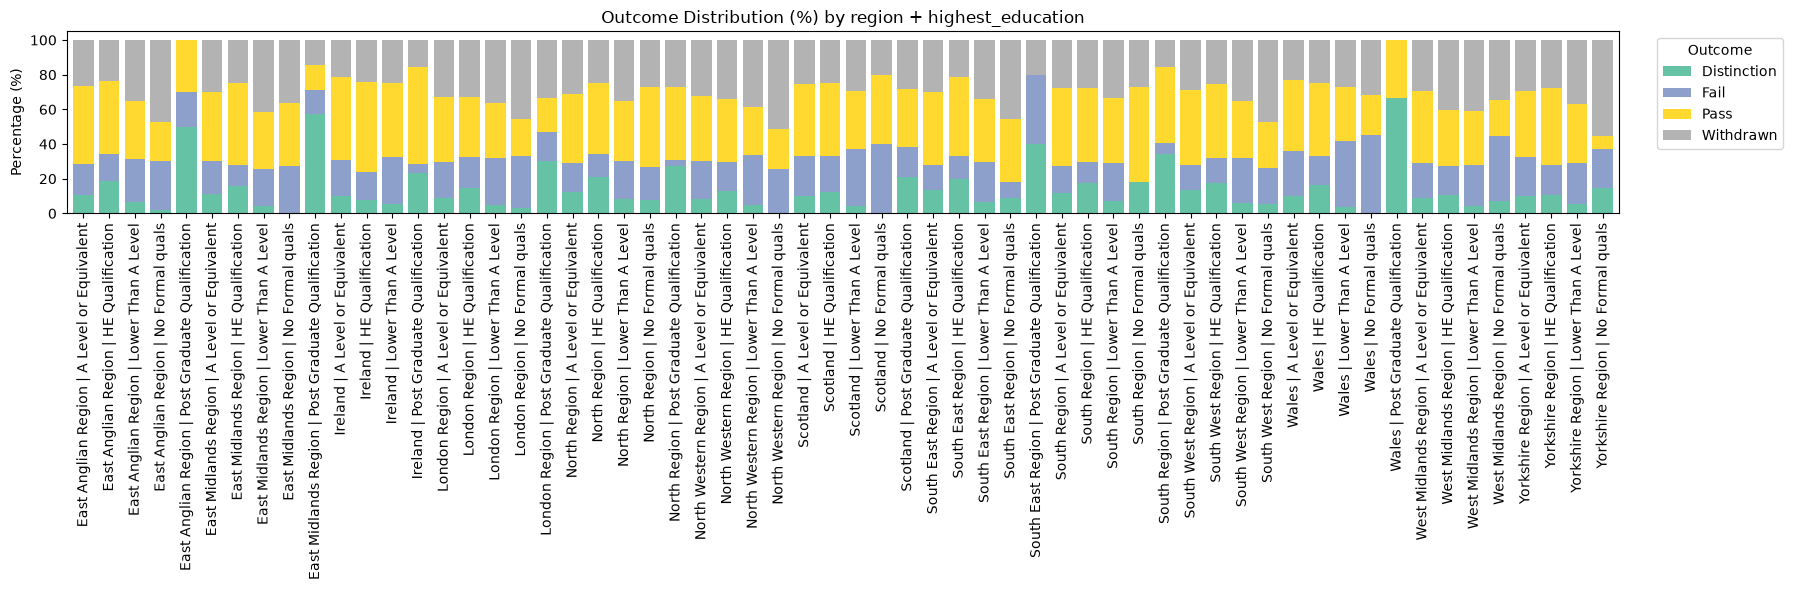

In [504]:
#Outcome Distribution Chart
plot_outcome_distribution(
    region_edu_summary,
    ["region", "highest_education"]
)

In [505]:
#Outcome Summary
region_edu_outcome_summary = outcome_summary(
    region_edu_summary,
    ["region", "highest_education"]
)

display(region_edu_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,Wales | Post Graduate Qualification,66.67,East Midlands Region | No Formal quals,0.0
1,Fail,Wales | No Formal quals,45.45,South Region | No Formal quals,0.0
2,Pass,Ireland | Post Graduate Qualification,56.41,South East Region | Post Graduate Qualification,0.0
3,Withdrawn,Yorkshire Region | No Formal quals,55.56,East Anglian Region | Post Graduate Qualification,0.0


### Outcome Distribution Summary

The percentage distribution of **Distinction, Pass, Fail, and Withdrawn** outcomes was compared across combinations of **region** and **highest education level**.

The outcome summary table identifies the region-education groups with the highest and lowest percentages for each academic outcome, while the stacked percentage bar chart illustrates variations in student performance across different educational backgrounds within each region.

This multivariate analysis helps determine whether the relationship between educational attainment and student outcomes is consistent across regions or varies depending on geographical location.

In [506]:
#Withdrawal Analysis
region_edu_withdrawal = withdrawal_analysis(
    df_students,
    ["region", "highest_education"]
)

display(region_edu_withdrawal)

,region,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
59,Yorkshire Region,No Formal quals,27,15,55.56
27,North Western Region,No Formal quals,39,20,51.28
46,South West Region,No Formal quals,19,9,47.37
3,East Anglian Region,No Formal quals,53,25,47.17
17,London Region,No Formal quals,94,43,45.74
36,South East Region,No Formal quals,11,5,45.45
7,East Midlands Region,Lower Than A Level,1081,446,41.26
54,West Midlands Region,Lower Than A Level,1099,447,40.67
53,West Midlands Region,HE Qualification,230,93,40.43
26,North Western Region,Lower Than A Level,1314,507,38.58


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


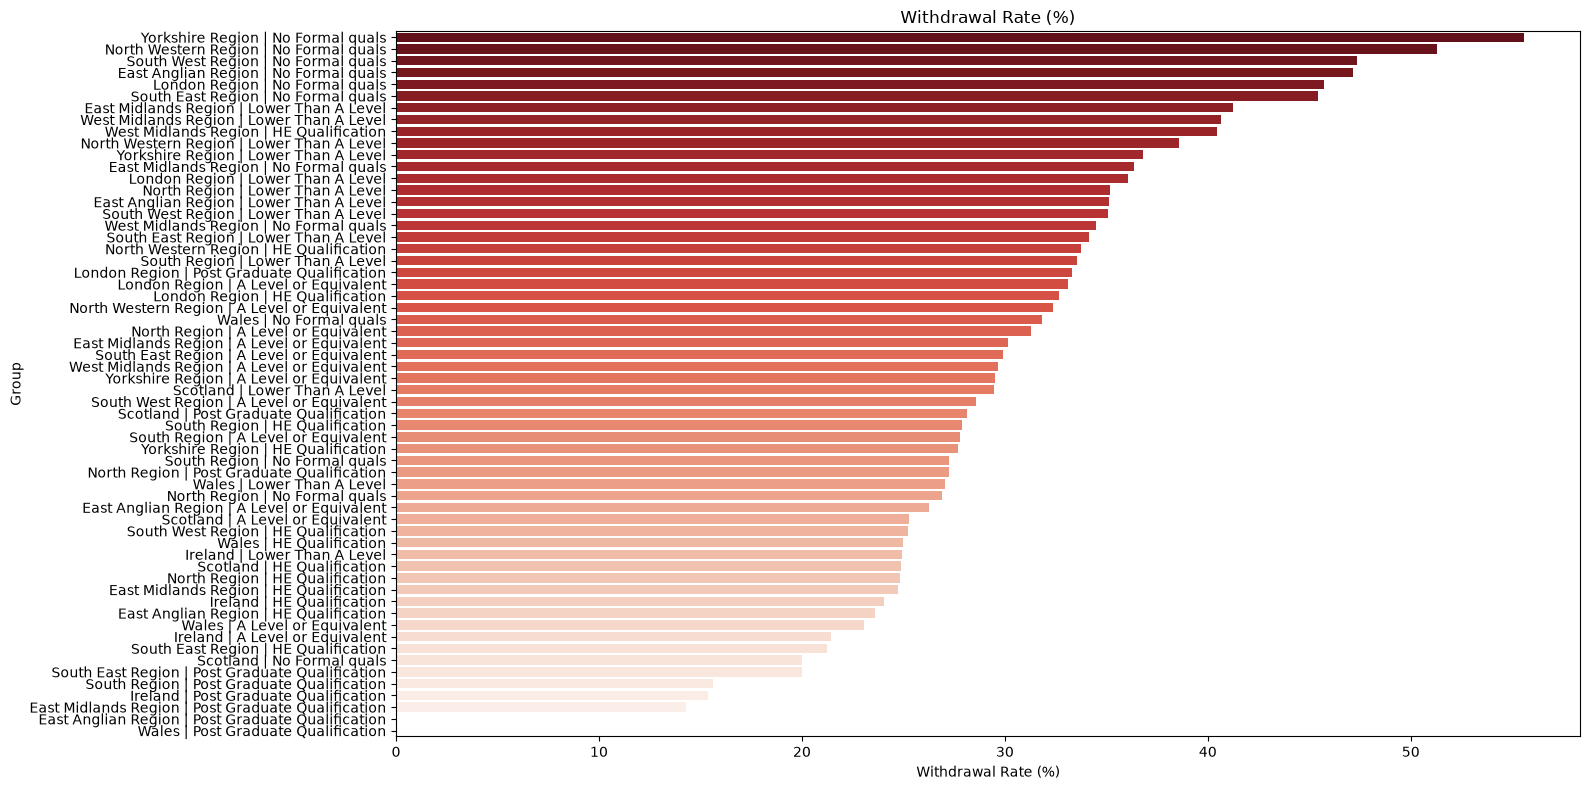

In [507]:
#Withdrawal Chart
plot_withdrawal_bar(
    region_edu_withdrawal,
    ["region", "highest_education"]
)

In [508]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    region_edu_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,region,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
59,Yorkshire Region,No Formal quals,27,15,55.56
27,North Western Region,No Formal quals,39,20,51.28
46,South West Region,No Formal quals,19,9,47.37
3,East Anglian Region,No Formal quals,53,25,47.17
17,London Region,No Formal quals,94,43,45.74


In [509]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    region_edu_withdrawal.tail(5)
    .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,region,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
4,East Anglian Region,Post Graduate Qualification,10,0,0.00
51,Wales,Post Graduate Qualification,6,0,0.00
9,East Midlands Region,Post Graduate Qualification,7,1,14.29
13,Ireland,Post Graduate Qualification,39,6,15.38
42,South Region,Post Graduate Qualification,32,5,15.62


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **region** and **highest education level** to investigate how geographical location and prior educational attainment jointly influence student dropout.

- Withdrawal rates varied substantially across the different region-education combinations, ranging from **0.0%** to **55.6%**, indicating significant differences in student retention across both geographical regions and educational backgrounds.
- The **highest withdrawal rate (55.6%)** was observed among students from the **Yorkshire Region** with **No Formal Qualifications**, followed by students from the **North Western Region** with **No Formal Qualifications (51.3%)**.
- Students with **No Formal Qualifications** consistently appeared among the highest withdrawal groups across multiple regions, including **South West Region (47.4%)**, **East Anglian Region (47.2%)**, **London Region (45.7%)**, and **South East Region (45.5%)**.
- Students with **Lower Than A Level** qualifications also recorded relatively high withdrawal rates across several regions, generally ranging between **35% and 41%**, indicating that lower educational attainment is consistently associated with increased dropout risk.
- In contrast, students holding **Post Graduate Qualifications** exhibited the lowest withdrawal rates in most regions. Several region–postgraduate combinations recorded withdrawal rates below **20%**, and two groups (**East Anglian Region** and **Wales**) recorded **0.0%** withdrawal. These values should be interpreted cautiously, as they may reflect a very small number of students within those groups.
- Students with **HE Qualifications** and **A Level or Equivalent** generally demonstrated moderate withdrawal rates, with noticeable variation across regions.

### Key Findings

- **Highest Withdrawal Rate:** Yorkshire Region – **No Formal Qualifications (55.6%)**
- **Second Highest Withdrawal Rate:** North Western Region – **No Formal Qualifications (51.3%)**
- **Lowest Withdrawal Rate:** East Anglian Region and Wales – **Post Graduate Qualification (0.0%)** *(interpret with caution due to possible small sample sizes)*
- Students with **No Formal Qualifications** consistently experienced the highest withdrawal rates across most regions.
- Students with **Post Graduate Qualifications** generally recorded the lowest withdrawal rates regardless of region, indicating better course retention.
- Although regional differences were evident, **educational attainment emerged as a stronger and more consistent factor associated with withdrawal than geographical location**.

### Interpretation

The analysis demonstrates that **student withdrawal rates vary considerably across combinations of region and highest education level**, highlighting the interaction between geographical location and prior educational attainment. However, unlike the **Region × Age Band** analysis, a clear and consistent pattern is evident across regions.

Across nearly all regions, students with **No Formal Qualifications** experienced the highest withdrawal rates, while students with **Post Graduate Qualifications** consistently recorded the lowest withdrawal rates. This suggests that **prior educational attainment has a stronger and more consistent relationship with student retention than regional differences alone**.

Regional variation still exists, as students with the same educational background exhibited different withdrawal rates across regions. However, these regional differences were generally smaller than the differences observed between education levels. This indicates that while geography influences student outcomes, **educational background appears to be the dominant factor influencing withdrawal in this interaction analysis**.

Overall, these findings suggest that combining **region** and **highest education level** provides a more comprehensive understanding of student dropout risk than analysing either variable independently. The results support the inclusion of both variables as predictive features in the machine learning model, with **highest education level** likely to contribute more strongly to predicting student withdrawal.

### Additional Observation: Interaction Between Region and Highest Education

Unlike the **Region × Age Band** analysis, where the relationship between age and withdrawal varied substantially across regions, the **Region × Highest Education** analysis reveals a much more consistent pattern.

Students with **No Formal Qualifications** consistently recorded the highest withdrawal rates across most regions, whereas students with **Post Graduate Qualifications** consistently demonstrated the lowest withdrawal rates. This indicates that the influence of educational attainment on student retention remains relatively stable regardless of geographical location.

Although regional differences are still present, they do not substantially alter the overall relationship between education level and withdrawal. This suggests that **highest education level is a robust predictor of student dropout**, while region primarily influences the magnitude of withdrawal rates rather than changing the overall trend.

From a predictive modelling perspective, these findings indicate that **highest education level** is likely to have stronger predictive power than **region**, although incorporating both variables together may improve the model's ability to identify high-risk student groups.

## Region × IMD Band

### Objective

This analysis investigates whether the distribution of student outcomes differs across combinations of **region** and **Index of Multiple Deprivation (IMD) band**. While previous analyses examined regional and socioeconomic factors independently, combining these variables provides deeper insight into how socioeconomic conditions influence academic performance and student retention across different geographical regions.

As student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify region-IMD groups that are at greater risk of student withdrawal.

In [510]:
# Outcome Distribution by Region and IMD Band

region_imd_summary = outcome_distribution(
    df_students,
    ["region", "imd_band"]
)

display(region_imd_summary)

,region,imd_band,Distinction,Fail,Pass,Withdrawn,Total Students
0,East Anglian Region,0-10%,6.80,32.04,30.10,31.07,103
1,East Anglian Region,10-20,3.68,31.29,31.90,33.13,163
2,East Anglian Region,20-30%,5.88,22.55,37.58,33.99,306
3,East Anglian Region,30-40%,9.62,23.90,34.07,32.42,364
4,East Anglian Region,40-50%,8.27,21.17,36.98,33.58,411
...,...,...,...,...,...,...,...
125,Yorkshire Region,50-60%,9.42,19.90,41.88,28.80,191
126,Yorkshire Region,60-70%,12.18,17.95,37.82,32.05,156
127,Yorkshire Region,70-80%,11.86,15.82,43.50,28.81,177
128,Yorkshire Region,80-90%,14.91,9.65,44.74,30.70,114


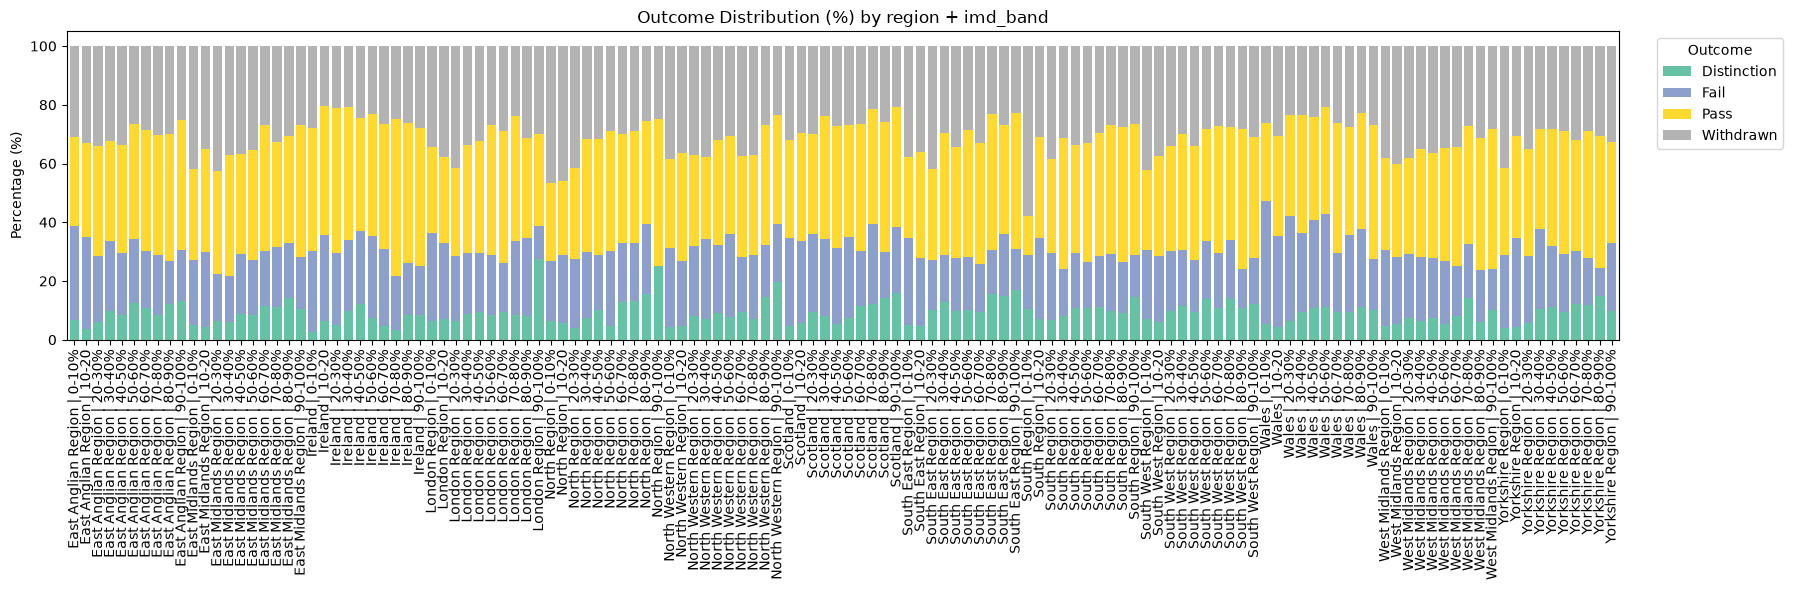

In [511]:
#Outcome Distribution Plot
plot_outcome_distribution(
    region_imd_summary,
    ["region", "imd_band"]
)

In [512]:
#Outcome Summary
region_imd_outcome_summary = outcome_summary(
    region_imd_summary,
    ["region", "imd_band"]
)

display(region_imd_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,London Region | 90-100%,27.50,Ireland | 0-10%,2.46
1,Fail,Wales | 0-10%,41.80,North Region | 90-100%,0.00
2,Pass,Ireland | 70-80%,53.41,South Region | 0-10%,13.16
3,Withdrawn,South Region | 0-10%,57.89,Ireland | 10-20,20.54


### Outcome Distribution Summary

The percentage distribution of **Distinction, Pass, Fail, and Withdrawn** outcomes was compared across combinations of **region** and **IMD band**.

The outcome summary table identifies the region-IMD groups with the highest and lowest percentages for each academic outcome, while the stacked percentage bar chart illustrates differences in student performance across socioeconomic groups within each region.

This analysis helps determine whether socioeconomic deprivation has a consistent relationship with student outcomes across different geographical regions.

In [513]:
#Withdrawal Analysis
region_imd_withdrawal = withdrawal_analysis(
    df_students,
    ["region", "imd_band"]
)

display(region_imd_withdrawal)

,region,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
80,South Region,0-10%,38,22,57.89
40,North Region,0-10%,186,87,46.77
41,North Region,10-20,243,112,46.09
12,East Midlands Region,20-30%,276,117,42.39
90,South West Region,0-10%,114,48,42.11
...,...,...,...,...,...
22,Ireland,20-30%,81,17,20.99
23,Ireland,30-40%,91,19,20.88
105,Wales,50-60%,208,43,20.67
69,Scotland,90-100%,315,65,20.63


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


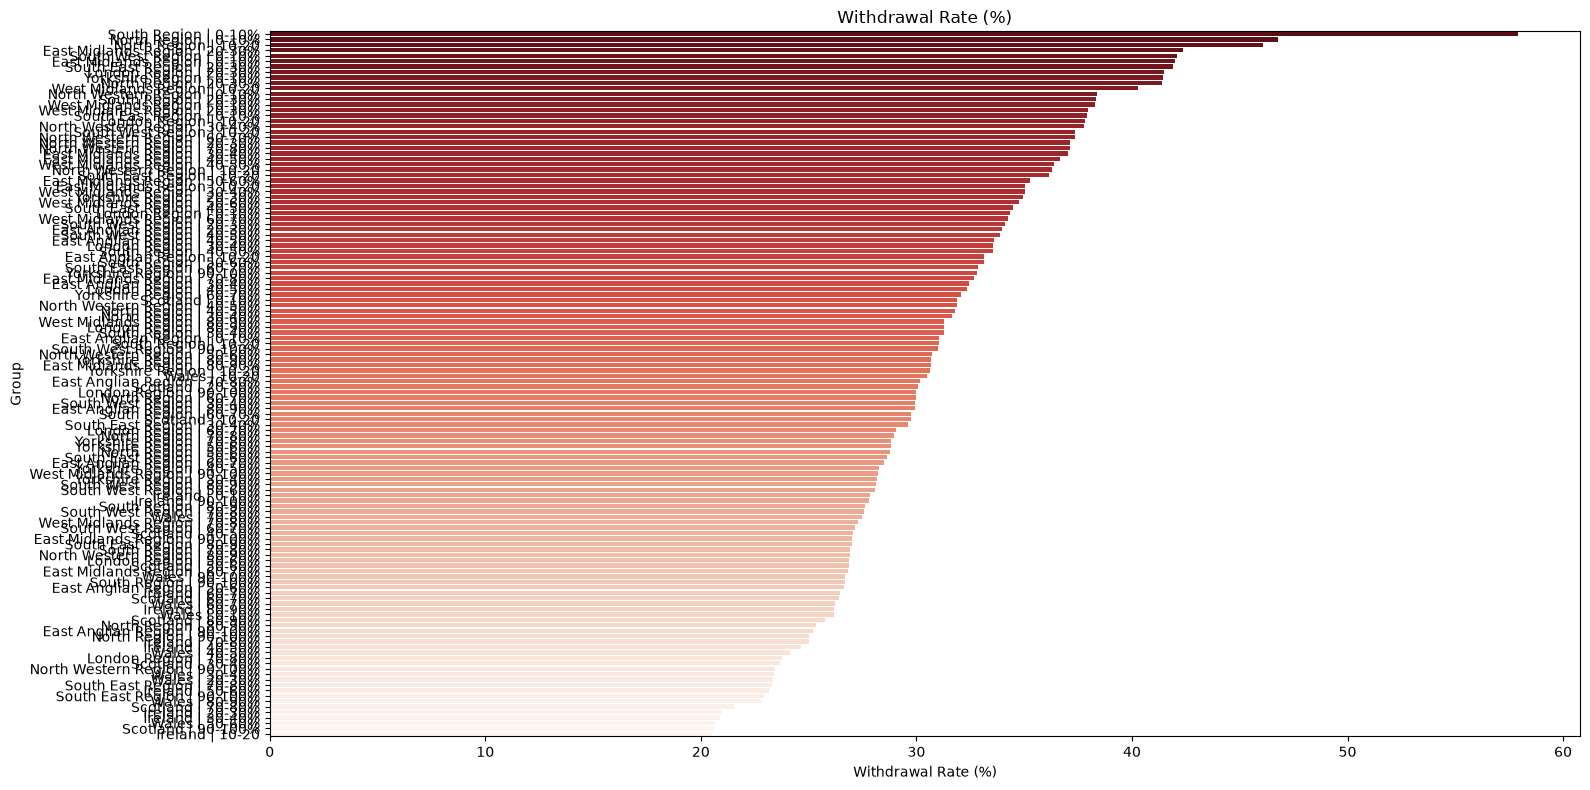

In [514]:
#Withdrawal Chart
plot_withdrawal_bar(
    region_imd_withdrawal,
    ["region", "imd_band"]
)

In [515]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    region_imd_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,region,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
80,South Region,0-10%,38,22,57.89
40,North Region,0-10%,186,87,46.77
41,North Region,10-20,243,112,46.09
12,East Midlands Region,20-30%,276,117,42.39
90,South West Region,0-10%,114,48,42.11


In [516]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    region_imd_withdrawal.tail(5)
          .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,region,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
21,Ireland,10-20,112,23,20.54
69,Scotland,90-100%,315,65,20.63
105,Wales,50-60%,208,43,20.67
23,Ireland,30-40%,91,19,20.88
22,Ireland,20-30%,81,17,20.99


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **region** and **Index of Multiple Deprivation (IMD) band** to investigate how geographical location and socioeconomic status jointly influence student dropout.

- Withdrawal rates ranged from approximately **20.8%** to **57.9%**, demonstrating substantial variation across different region–IMD combinations.
- The **highest withdrawal rate (57.9%)** was observed among students from the **South Region** in the **0–10% IMD band**, indicating that students living in the most deprived areas within this region experienced the greatest risk of withdrawal.
- Several other region–IMD combinations within the **0–30% IMD bands** also recorded withdrawal rates exceeding **45%**, suggesting consistently elevated dropout risk among students from more deprived socioeconomic backgrounds.
- In contrast, the **lowest withdrawal rates** were generally observed in the **70–100% IMD bands**, with several region–IMD combinations recording withdrawal rates close to **20–25%**, indicating comparatively better student retention in less deprived areas.
- Although withdrawal rates generally decreased as the IMD band increased, the magnitude of this decline varied across regions, indicating that socioeconomic status does not influence all regions equally.

### Key Findings

- **Highest Withdrawal Rate:** South Region – **0–10% IMD band (57.9%)**
- Several of the highest withdrawal rates were concentrated within the **0–30% IMD bands**, regardless of region.
- The lowest withdrawal rates were predominantly observed within the **70–100% IMD bands**, indicating improved retention among students from less deprived areas.
- Students from the same IMD band exhibited different withdrawal rates across regions, suggesting that geographical location also contributes to student dropout risk.

### Interpretation

The analysis demonstrates that **student withdrawal rates vary considerably across combinations of region and IMD band**, highlighting the combined influence of geographical location and socioeconomic status on student retention.

A clear socioeconomic trend is evident across most regions. Students residing in **more deprived areas (0–30% IMD bands)** consistently experienced higher withdrawal rates than students living in **less deprived areas (70–100% IMD bands)**. This suggests that socioeconomic disadvantage is strongly associated with an increased likelihood of student withdrawal.

However, the relationship between IMD band and withdrawal is **not identical across all regions**. Students belonging to the same deprivation band often exhibited different withdrawal rates depending on their region, indicating that geographical factors may moderate the effect of socioeconomic status on student retention.

Overall, these findings suggest that **both region and IMD band are important predictors of student dropout**, with **IMD band showing a strong and consistent association with withdrawal**, while regional characteristics influence the magnitude of that relationship. Incorporating both variables into the predictive modelling stage is therefore expected to improve the identification of high-risk student groups.

### Additional Observation: Interaction Between Region and IMD Band

The **Region × IMD Band** analysis reveals a clearer and more consistent pattern than the **Region × Age Band** analysis. Across nearly all regions, withdrawal rates generally **decrease as the IMD band increases**, indicating that students from less deprived socioeconomic backgrounds are more likely to complete their courses.

Although regional differences remain evident, they primarily influence the magnitude of withdrawal rates rather than altering the overall socioeconomic trend. This suggests that **IMD band is a stronger and more consistent predictor of student withdrawal than region alone**, while regional characteristics modify the level of risk within each socioeconomic group.

From a predictive modelling perspective, these findings indicate that **socioeconomic status (IMD band)** is likely to contribute substantially to dropout prediction, and combining it with **region** provides additional context for identifying high-risk student populations.

## Previous Attempts × Gender

### Objective

This analysis investigates whether the distribution of student outcomes differs across combinations of **number of previous attempts** and **gender**.

Previous attempts represent an important academic characteristic that may influence future course performance and student persistence. By combining previous attempts with gender, this analysis explores whether prior academic history affects male and female students differently.

Since student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify groups with a higher likelihood of withdrawing from the course.

In [517]:
# Outcome Distribution by Previous Attempts and Gender

attempt_gender_summary = outcome_distribution(
    df_students,
    ["num_of_prev_attempts", "gender"]
)

display(attempt_gender_summary)

,num_of_prev_attempts,gender,Distinction,Fail,Pass,Withdrawn,Total Students
0,0,F,10.33,19.56,40.34,29.77,12751
1,0,M,9.83,20.66,38.32,31.20,15670
2,1,F,4.26,29.11,32.05,34.58,1501
3,1,M,4.39,31.81,28.70,35.09,1798
4,2,F,3.43,36.57,24.86,35.14,350
5,2,M,3.08,33.23,25.54,38.15,325
6,3,F,0.00,38.75,21.25,40.00,80
7,3,M,1.61,41.94,22.58,33.87,62
8,4,F,0.00,34.78,21.74,43.48,23
9,4,M,0.00,25.00,50.00,25.00,16


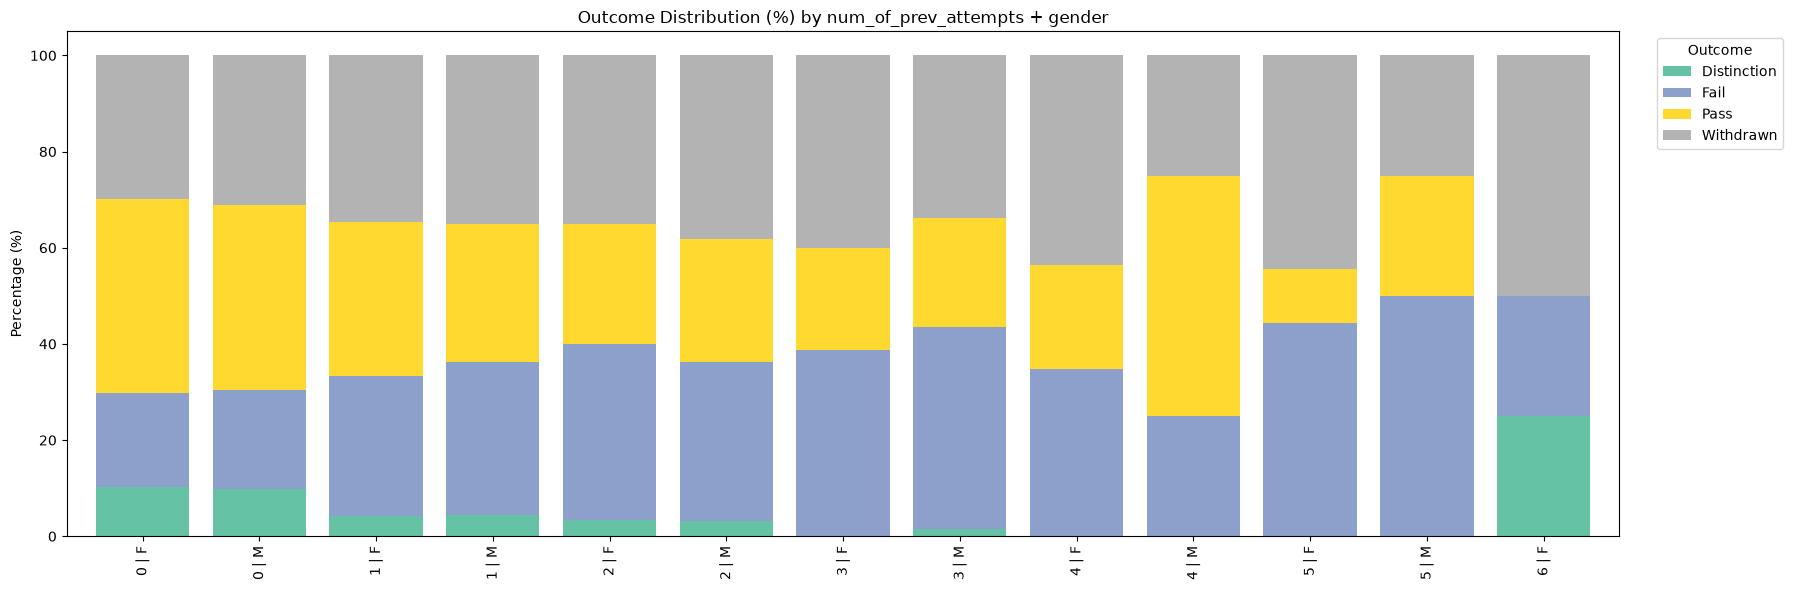

In [518]:
#Outcome Distribution Plot
plot_outcome_distribution(
    attempt_gender_summary,
    ["num_of_prev_attempts", "gender"]
)

In [519]:
#Outcome Summary
attempt_gender_outcome_summary = outcome_summary(
    attempt_gender_summary,
    ["num_of_prev_attempts", "gender"]
)

display(attempt_gender_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,6 | F,25.0,3 | F,0.00
1,Fail,5 | M,50.0,0 | F,19.56
2,Pass,4 | M,50.0,6 | F,0.00
3,Withdrawn,6 | F,50.0,4 | M,25.00


### Outcome Distribution Summary

The percentage distribution of **Distinction, Pass, Fail, and Withdrawn** outcomes was compared across combinations of **number of previous attempts** and **gender**.

The outcome summary table identifies the groups with the highest and lowest percentages for each academic outcome, while the stacked percentage bar chart illustrates differences in academic performance across students with varying numbers of previous attempts.

This analysis helps determine whether prior academic history influences student outcomes consistently across both genders.

In [520]:
#Withdrawal Analysis
attempt_gender_withdrawal = withdrawal_analysis(
    df_students,
    ["num_of_prev_attempts", "gender"]
)

display(attempt_gender_withdrawal)

,num_of_prev_attempts,gender,Total_Students,Withdrawn,Withdrawal Rate (%)
12,6,F,4,2,50.00
10,5,F,9,4,44.44
8,4,F,23,10,43.48
6,3,F,80,32,40.00
5,2,M,325,124,38.15
4,2,F,350,123,35.14
3,1,M,1798,631,35.09
2,1,F,1501,519,34.58
7,3,M,62,21,33.87
1,0,M,15670,4889,31.20


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


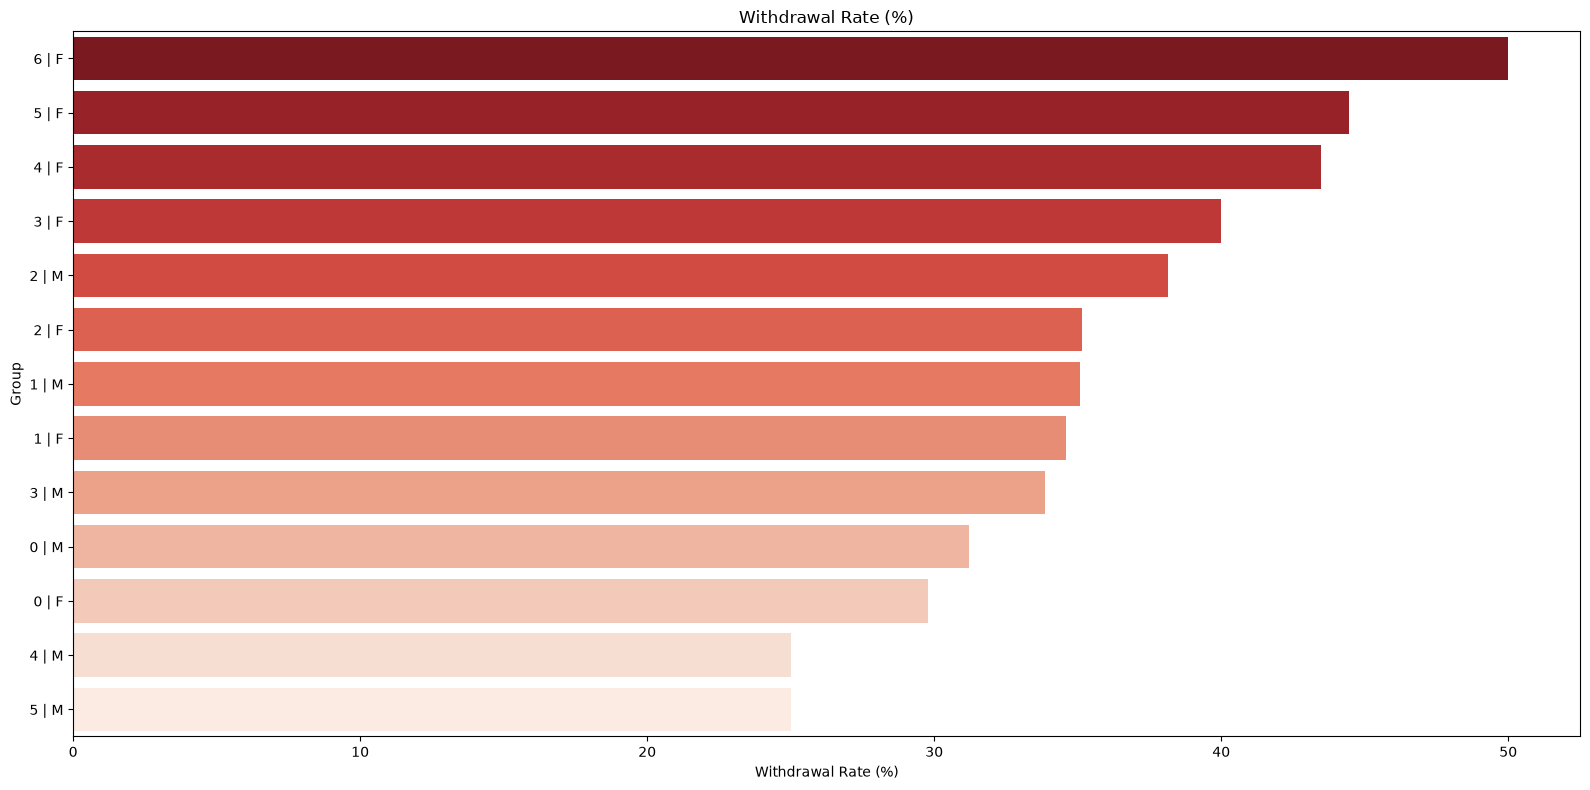

In [521]:
#Withdrawal Chart
plot_withdrawal_bar(
    attempt_gender_withdrawal,
    ["num_of_prev_attempts", "gender"]
)


In [522]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    attempt_gender_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,num_of_prev_attempts,gender,Total_Students,Withdrawn,Withdrawal Rate (%)
12,6,F,4,2,50.00
10,5,F,9,4,44.44
8,4,F,23,10,43.48
6,3,F,80,32,40.00
5,2,M,325,124,38.15


In [523]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    attempt_gender_withdrawal.tail(5)
          .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,num_of_prev_attempts,gender,Total_Students,Withdrawn,Withdrawal Rate (%)
9,4,M,16,4,25.00
11,5,M,4,1,25.00
0,0,F,12751,3796,29.77
1,0,M,15670,4889,31.20
7,3,M,62,21,33.87


In [524]:
df_students.groupby(["num_of_prev_attempts", "gender"]).size().reset_index(name="Count")

,num_of_prev_attempts,gender,Count
0,0,F,12751
1,0,M,15670
2,1,F,1501
3,1,M,1798
4,2,F,350
5,2,M,325
6,3,F,80
7,3,M,62
8,4,F,23
9,4,M,16


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **number of previous attempts** and **gender** to investigate whether prior academic history influences student dropout.

- Withdrawal rates ranged from **25.0%** to **50.0%** across the different previous-attempt groups.
- Students with **no previous attempts** represented the largest proportion of the dataset, with **12,751 female** and **15,670 male** students. Their withdrawal rates were comparatively lower (**29.8% for females** and **31.2% for males**) than many of the repeated-attempt groups.
- Withdrawal rates generally increased among students with one or more previous attempts, indicating that repeated enrolment may be associated with a greater likelihood of withdrawal.
- The highest withdrawal rate (**50.0%**) was observed among **female students with six previous attempts**, followed by **female students with five previous attempts (44.4%)** and **female students with four previous attempts (43.5%)**.
- However, these groups contained **very few students** (4, 9, and 23 students, respectively). Therefore, these percentages should be interpreted with caution, as they are more sensitive to small changes in the number of withdrawals.

### Key Findings

- Students with **0–2 previous attempts** account for the vast majority of the dataset and therefore provide the most reliable estimates of withdrawal behaviour.
- Students with **multiple previous attempts** generally exhibited higher withdrawal rates than first-time learners.
- Extreme withdrawal rates observed for students with **4–6 previous attempts** are based on very small sample sizes and should not be interpreted as representative of the wider student population.
- Overall, the results suggest that previous academic history is associated with student withdrawal, although conclusions for higher previous-attempt categories are limited by the small number of observations.

### Interpretation

The analysis indicates that **previous academic attempts are associated with student withdrawal**, with students who have previously attempted the course generally exhibiting higher withdrawal rates than first-time learners. This pattern suggests that repeated enrolment may reflect ongoing academic challenges or difficulties in completing the course successfully.

Although the highest withdrawal percentages were observed among students with **four or more previous attempts**, these categories contained very small numbers of students. Consequently, the observed percentages are likely to be less stable and should be interpreted cautiously.

The findings from the larger groups (0–2 previous attempts), which include the overwhelming majority of students, provide stronger evidence that previous attempts are an important academic characteristic related to student retention. These results support the inclusion of **number of previous attempts** as a predictive feature in the machine learning models while recognising the limitations associated with sparse categories.

## Previous Attempts × Age Band

### Objective

This analysis investigates whether the distribution of student outcomes differs across combinations of **number of previous attempts** and **age band**.

Previous attempts reflect a student's academic history, while age band represents learner demographics and experience. Analysing these variables together helps determine whether repeated enrolment influences academic outcomes differently across age groups.

As student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify age groups with an increased risk of withdrawal based on previous academic attempts.

In [525]:
# Outcome Distribution by Previous Attempts and Age Band

attempt_age_summary = outcome_distribution(
    df_students,
    ["num_of_prev_attempts", "age_band"]
)

display(attempt_age_summary)

,num_of_prev_attempts,age_band,Distinction,Fail,Pass,Withdrawn,Total Students
0,0,0-35,8.81,21.38,38.04,31.78,20051
1,0,35-55,12.88,17.39,41.98,27.74,8175
2,0,55<=,19.49,11.79,45.64,23.08,195
3,1,0-35,3.53,31.48,30.39,34.61,2297
4,1,35-55,6.01,28.62,30.14,35.23,982
5,1,55<=,15.00,25.00,15.00,45.00,20
6,2,0-35,3.21,35.33,24.63,36.83,467
7,2,35-55,3.38,33.82,26.57,36.23,207
8,2,55<=,0.00,100.00,0.00,0.00,1
9,3,0-35,1.02,44.90,20.41,33.67,98


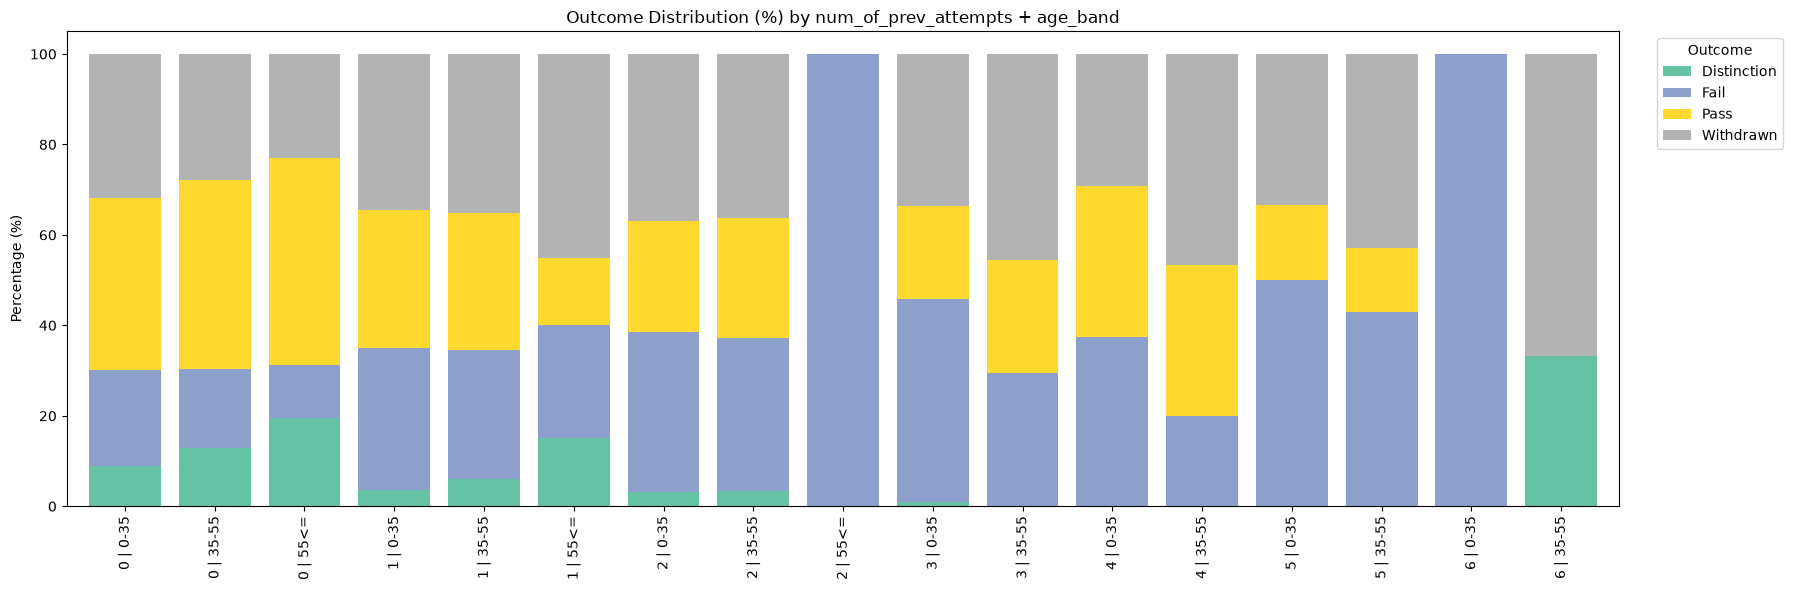

In [526]:
#Outcome Distribution Chart
plot_outcome_distribution(
    attempt_age_summary,
    ["num_of_prev_attempts", "age_band"]
)


In [527]:
#Outcome Summary
attempt_age_outcome_summary = outcome_summary(
    attempt_age_summary,
    ["num_of_prev_attempts", "age_band"]
)

display(attempt_age_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,6 | 35-55,33.33,2 | 55<=,0.0
1,Fail,2 | 55<=,100.00,6 | 35-55,0.0
2,Pass,0 | 55<=,45.64,2 | 55<=,0.0
3,Withdrawn,6 | 35-55,66.67,2 | 55<=,0.0


### Outcome Distribution Summary

The percentage distribution of **Distinction, Pass, Fail, and Withdrawn** outcomes was compared across combinations of **number of previous attempts** and **age band**.

The outcome summary table identifies the previous-attempt and age-band groups with the highest and lowest percentages for each academic outcome, while the stacked percentage bar chart illustrates differences in academic performance across students with varying academic histories.

This analysis helps determine whether previous academic experience influences student outcomes consistently across different age groups.

In [528]:
#Withdrawal Analysis
attempt_age_withdrawal = withdrawal_analysis(
    df_students,
    ["num_of_prev_attempts", "age_band"]
)

display(attempt_age_withdrawal)

,num_of_prev_attempts,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
16,6,35-55,3,2,66.67
12,4,35-55,15,7,46.67
10,3,35-55,44,20,45.45
5,1,55<=,20,9,45.00
14,5,35-55,7,3,42.86
6,2,0-35,467,172,36.83
7,2,35-55,207,75,36.23
4,1,35-55,982,346,35.23
3,1,0-35,2297,795,34.61
9,3,0-35,98,33,33.67


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


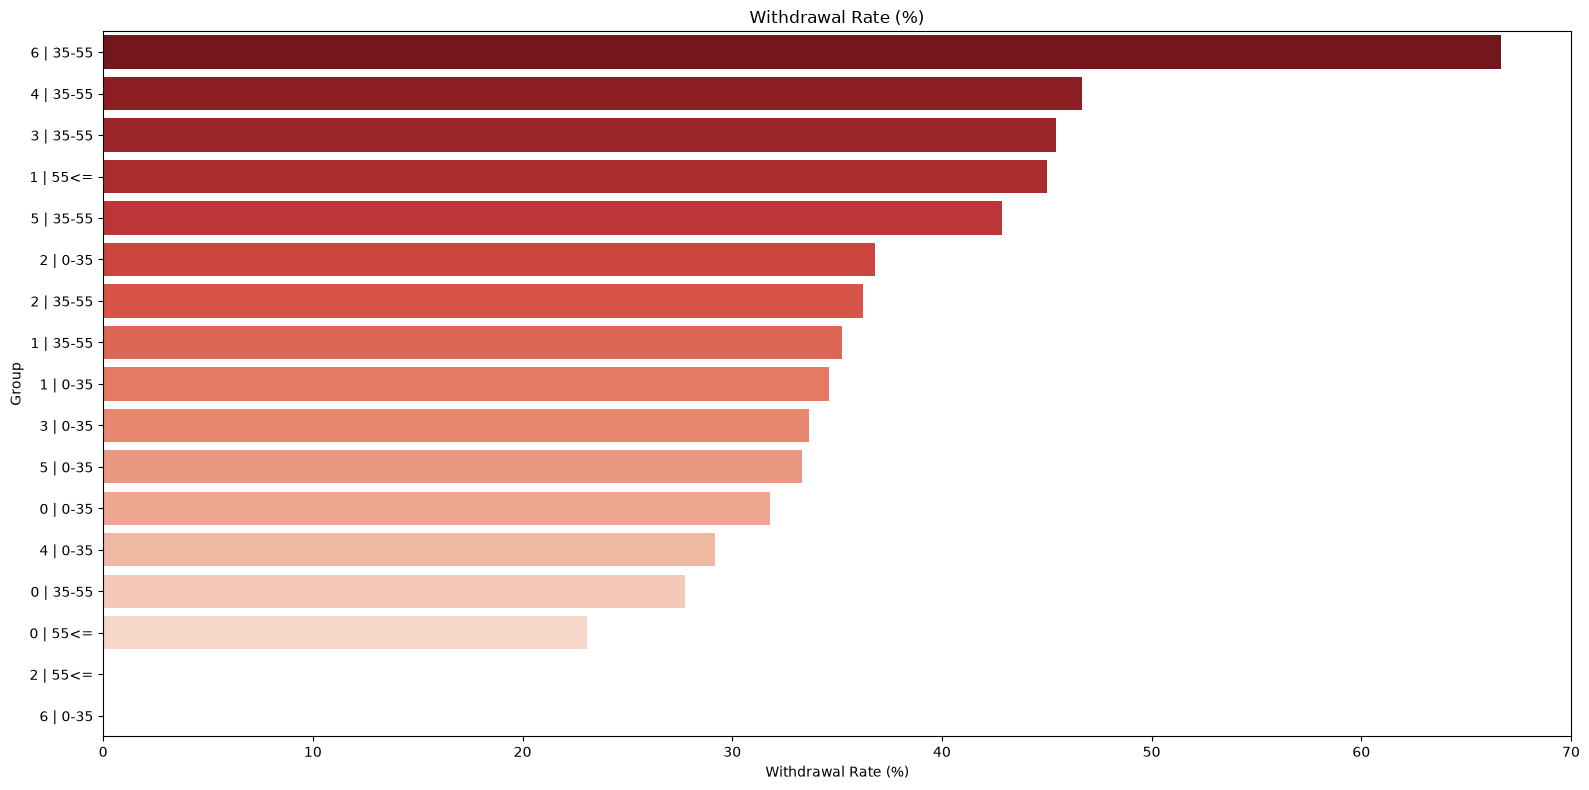

In [529]:
#Withdrawal Chart
plot_withdrawal_bar(
    attempt_age_withdrawal,
    ["num_of_prev_attempts", "age_band"]
)

In [530]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    attempt_age_withdrawal.head(5)
)

Top 5 Highest Withdrawal Groups


,num_of_prev_attempts,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
16,6,35-55,3,2,66.67
12,4,35-55,15,7,46.67
10,3,35-55,44,20,45.45
5,1,55<=,20,9,45.00
14,5,35-55,7,3,42.86


In [531]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    attempt_age_withdrawal.tail(5)
          .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,num_of_prev_attempts,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
8,2,55<=,1,0,0.00
15,6,0-35,1,0,0.00
2,0,55<=,195,45,23.08
1,0,35-55,8175,2268,27.74
11,4,0-35,24,7,29.17


In [532]:
df_students.groupby(["num_of_prev_attempts", "age_band"]).size().reset_index(name="Count")

,num_of_prev_attempts,age_band,Count
0,0,0-35,20051
1,0,35-55,8175
2,0,55<=,195
3,1,0-35,2297
4,1,35-55,982
5,1,55<=,20
6,2,0-35,467
7,2,35-55,207
8,2,55<=,1
9,3,0-35,98


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **number of previous attempts** and **age band** to investigate whether prior academic history influences student dropout differently across age groups.

- Withdrawal rates ranged from **0.0%** to **66.7%** across the different previous attempt–age band combinations.
- Students with **no previous attempts** accounted for the majority of the dataset, with **20,051 students aged 0–35 years** and **8,175 students aged 35–55 years**. These groups exhibited comparatively lower withdrawal rates than students with previous attempts.
- Withdrawal rates generally increased among students with one or more previous attempts, particularly within the **35–55 years** age group.
- The highest withdrawal rates were observed among students with **four or more previous attempts**. However, these categories contained very small numbers of students (for example, only **3 students** with six previous attempts in the 35–55 age group), making these percentages less reliable.
- A few groups recorded **0.0% withdrawal rates**, but these were also based on extremely small sample sizes (for example, only **one student** aged 55 years and above with two previous attempts).

### Key Findings

- The majority of students belonged to the **0 previous attempts** category, making these results the most statistically reliable.
- Students with **one or two previous attempts** generally exhibited higher withdrawal rates than first-time learners.
- Although students with **four or more previous attempts** recorded the highest withdrawal percentages, these groups contained very few students and should therefore be interpreted cautiously.
- The **35–55 years** age group generally demonstrated higher withdrawal rates than the **0–35 years** age group for comparable previous-attempt categories.

### Interpretation

The analysis indicates that **student withdrawal rates vary across combinations of previous attempts and age band**, suggesting that prior academic history is associated with student retention across different age groups.

The most reliable evidence comes from the larger groups (0–2 previous attempts), which include the overwhelming majority of students. Within these groups, withdrawal rates generally increased as the number of previous attempts increased, indicating that students who repeatedly enrolled in the course were more likely to withdraw than first-time learners.

The **35–55 years** age group consistently recorded slightly higher withdrawal rates than the **0–35 years** age group for comparable previous-attempt categories, suggesting that repeated enrolment may have a greater impact on student retention among middle-aged learners.

Although several groups with four or more previous attempts exhibited exceptionally high withdrawal rates, these categories contained very small sample sizes and therefore provide less reliable estimates. Consequently, these extreme percentages should not be generalised to the wider student population.

Overall, the findings suggest that **previous academic history is a more consistent predictor of student withdrawal than age alone**, while age appears to influence the magnitude of withdrawal within different previous-attempt groups.

### Additional Observation: Interaction Between Previous Attempts and Age Band

Unlike the demographic analyses, where factors such as education level and socioeconomic status showed clear and consistent trends, the interaction between **previous attempts** and **age band** is influenced by the distribution of students across categories.

The majority of students were first-time learners, whereas students with four or more previous attempts represented only a very small proportion of the dataset. As a result, conclusions regarding the higher previous-attempt categories should be interpreted cautiously.

Despite this limitation, the overall trend observed within the larger groups suggests that repeated enrolment is associated with an increased likelihood of withdrawal across age groups. These findings support the inclusion of **number of previous attempts** as an important predictive feature in the student dropout prediction model.

## Credit Group × Age Band

### Objective

This analysis investigates whether the distribution of student outcomes differs across combinations of **credit group** and **age band**.

The number of studied credits reflects the academic workload undertaken by a student. By combining credit load with age band, this analysis explores whether academic workload influences student performance and withdrawal differently across age groups.

As student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify age groups that may be more susceptible to withdrawal under different credit loads.

In [533]:
# Create Credit Groups

df_students["credit_group"] = pd.cut(
    df_students["studied_credits"],
    bins=[0, 60, 90, 120, 1000],
    labels=[
        "Low (≤60)",
        "Medium (61-90)",
        "High (91-120)",
        "Very High (>120)"
    ],
    include_lowest=True
)

In [534]:
# Outcome Distribution by Credit Group and Age Band

credit_age_summary = outcome_distribution(
    df_students,
    ["credit_group", "age_band"]
)

display(credit_age_summary)

,credit_group,age_band,Distinction,Fail,Pass,Withdrawn,Total Students
0,Low (≤60),0-35,8.87,24.08,40.54,26.52,13931
1,Low (≤60),35-55,12.66,20.41,43.93,23.00,6487
2,Low (≤60),55<=,18.00,14.67,48.67,18.67,150
3,Medium (61-90),0-35,8.58,22.69,33.48,35.24,2494
4,Medium (61-90),35-55,12.30,14.39,35.96,37.35,862
5,Medium (61-90),55<=,8.70,17.39,39.13,34.78,23
6,High (91-120),0-35,7.26,20.64,31.97,40.14,4836
7,High (91-120),35-55,10.63,15.94,32.41,41.01,1524
8,High (91-120),55<=,36.67,10.00,20.00,33.33,30
9,Very High (>120),0-35,3.74,18.60,26.14,51.52,1683


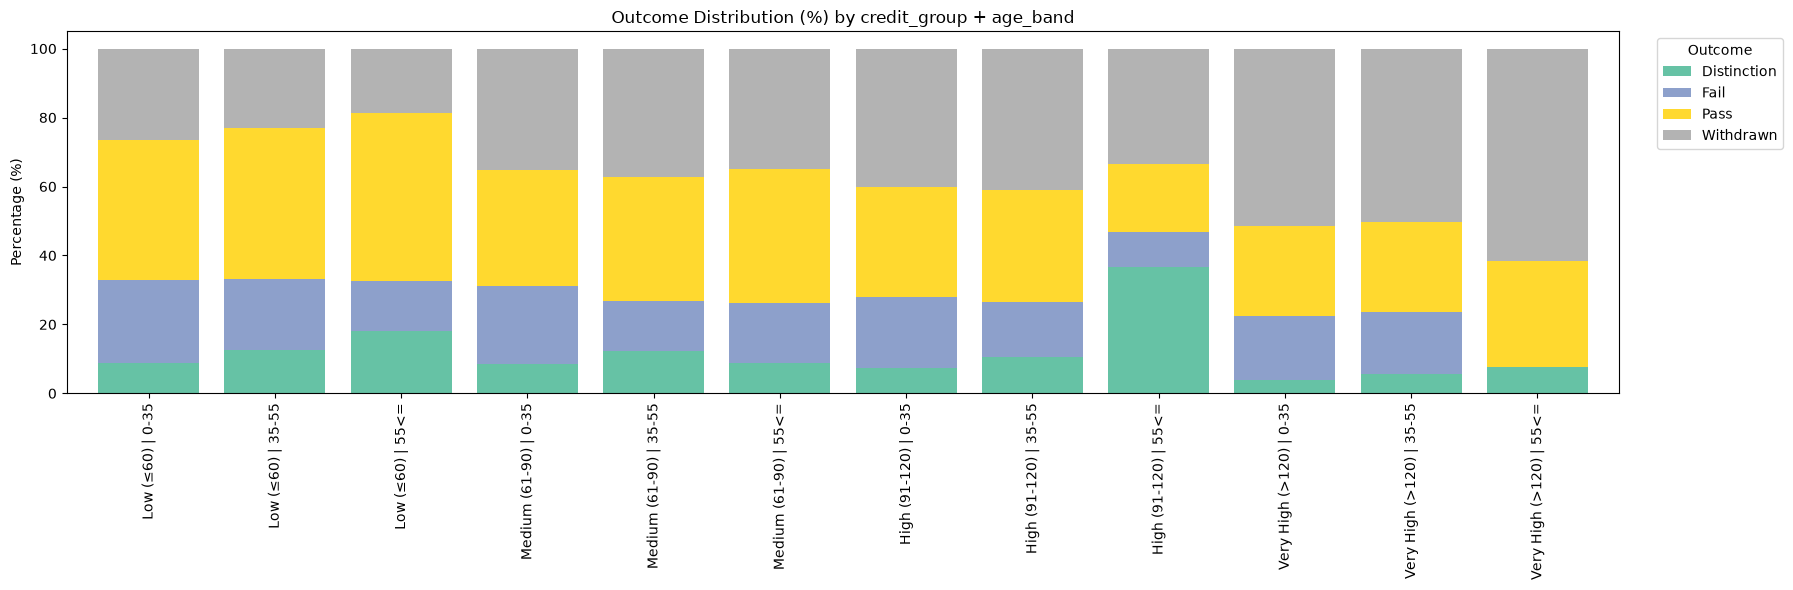

In [535]:
#Outcome Distribution Chart
plot_outcome_distribution(
    credit_age_summary,
    ["credit_group", "age_band"]
)

In [536]:
#Outcome Summary
credit_age_outcome_summary = outcome_summary(
    credit_age_summary,
    ["credit_group", "age_band"]
)

display(credit_age_outcome_summary)

,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,High (91-120) | 55<=,36.67,Very High (>120) | 0-35,3.74
1,Fail,Low (≤60) | 0-35,24.08,Very High (>120) | 55<=,0.00
2,Pass,Low (≤60) | 55<=,48.67,High (91-120) | 55<=,20.00
3,Withdrawn,Very High (>120) | 55<=,61.54,Low (≤60) | 55<=,18.67


### Outcome Distribution Summary

The percentage distribution of **Distinction, Pass, Fail, and Withdrawn** outcomes was compared across combinations of **credit group** and **age band**.

The outcome summary table identifies the highest- and lowest-performing groups for each academic outcome, while the stacked percentage bar chart illustrates how academic workload influences student performance across different age groups.

This analysis helps determine whether course workload has a consistent relationship with academic outcomes regardless of student age.

In [537]:
#Withdrawal Analysis
credit_age_withdrawal = withdrawal_analysis(
    df_students,
    ["credit_group", "age_band"]
)

display(credit_age_withdrawal)

,credit_group,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
11,Very High (>120),55<=,13,8,61.54
9,Very High (>120),0-35,1683,867,51.52
10,Very High (>120),35-55,560,282,50.36
7,High (91-120),35-55,1524,625,41.01
6,High (91-120),0-35,4836,1941,40.14
4,Medium (61-90),35-55,862,322,37.35
3,Medium (61-90),0-35,2494,879,35.24
5,Medium (61-90),55<=,23,8,34.78
8,High (91-120),55<=,30,10,33.33
0,Low (≤60),0-35,13931,3694,26.52


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


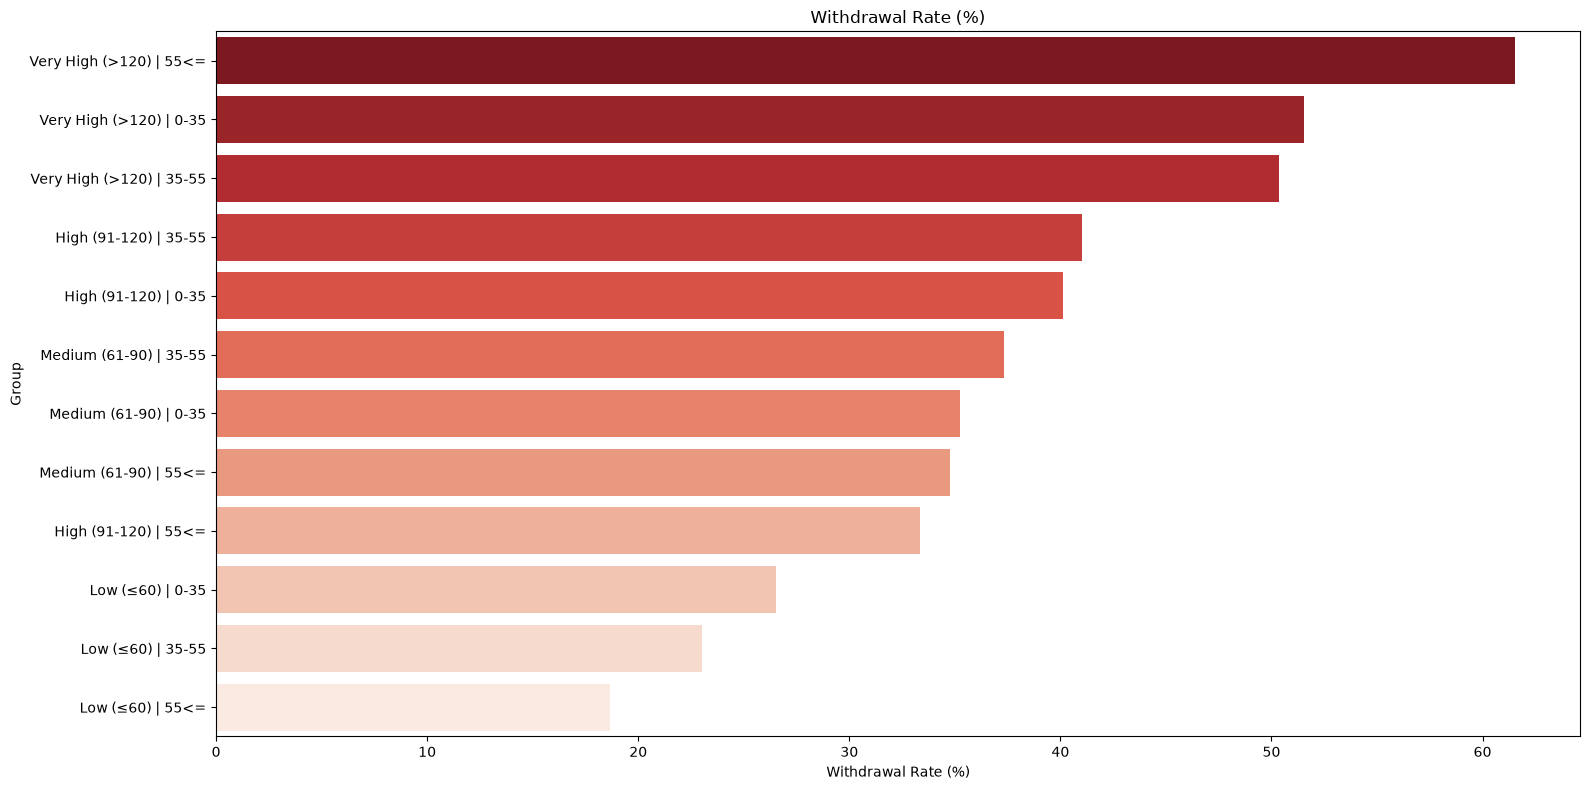

In [538]:
#Withdrawal Chart
plot_withdrawal_bar(
    credit_age_withdrawal,
    ["credit_group", "age_band"]
)

In [539]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    credit_age_withdrawal.tail(5)
          .sort_values("Withdrawal Rate (%)")
)


Top 5 Lowest Withdrawal Groups


,credit_group,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
2,Low (≤60),55<=,150,28,18.67
1,Low (≤60),35-55,6487,1492,23.00
0,Low (≤60),0-35,13931,3694,26.52
8,High (91-120),55<=,30,10,33.33
5,Medium (61-90),55<=,23,8,34.78


In [540]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    credit_age_withdrawal.tail(5)
          .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,credit_group,age_band,Total_Students,Withdrawn,Withdrawal Rate (%)
2,Low (≤60),55<=,150,28,18.67
1,Low (≤60),35-55,6487,1492,23.00
0,Low (≤60),0-35,13931,3694,26.52
8,High (91-120),55<=,30,10,33.33
5,Medium (61-90),55<=,23,8,34.78


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **credit group** and **age band** to investigate whether academic workload influences student dropout differently across age groups.

- Withdrawal rates ranged from **18.7%** to **61.5%**, indicating substantial variation across different credit load and age group combinations.
- The **highest withdrawal rate (61.5%)** was observed among students aged **55 years and above** enrolled in the **Very High (>120 credits)** group, followed by students aged **0–35 years (51.5%)** and **35–55 years (50.4%)** within the same credit group.
- Students enrolled in the **High (91–120 credits)** group also exhibited relatively high withdrawal rates, ranging from **33.3%** to **41.0%** across the three age groups.
- Students in the **Medium (61–90 credits)** group recorded moderate withdrawal rates between **34.8%** and **37.4%**, whereas those enrolled in the **Low (≤60 credits)** group consistently demonstrated the lowest withdrawal rates, ranging from **18.7%** to **26.5%**.
- Across all age groups, withdrawal rates generally increased as the number of studied credits increased, indicating a strong relationship between academic workload and student retention.

### Key Findings

- **Highest Withdrawal Rate:** Students aged **55 years and above** enrolled in the **Very High (>120 credits)** group (**61.5%**).
- **Second Highest Withdrawal Rate:** Students aged **0–35 years** enrolled in the **Very High (>120 credits)** group (**51.5%**).
- **Lowest Withdrawal Rate:** Students aged **55 years and above** enrolled in the **Low (≤60 credits)** group (**18.7%**).
- Students enrolled in higher credit groups consistently exhibited higher withdrawal rates regardless of age.
- The relationship between credit load and withdrawal was remarkably consistent across all three age groups.

### Interpretation

The analysis demonstrates that **student withdrawal rates increase consistently with increasing academic workload**, regardless of age group. Students enrolled in **Very High (>120 credits)** experienced the highest withdrawal rates across all age categories, while those enrolled in **Low (≤60 credits)** consistently demonstrated the lowest withdrawal rates.

Although some differences exist between age groups, these differences are relatively small compared with the effect of **credit load**. This suggests that **academic workload has a stronger association with student withdrawal than age alone**. The pattern is particularly evident among students aged **55 years and above**, where withdrawal rates increased from **18.7%** in the Low credit group to **61.5%** in the Very High credit group.

Overall, these findings indicate that **studied credits (academic workload)** is one of the strongest academic predictors of student withdrawal observed during the exploratory data analysis. The consistent increase in withdrawal rates across all age groups suggests that higher workloads may present greater academic challenges, increasing the likelihood of students discontinuing their studies.

### Additional Observation: Interaction Between Credit Group and Age Band

Unlike several previous interaction analyses, **Credit Group × Age Band** exhibits a highly consistent and nearly monotonic pattern across all age groups. As academic workload increases from **Low** to **Very High**, withdrawal rates also increase for each age category.

This consistency indicates that the relationship between **studied credits** and student withdrawal is largely independent of age. While older students (55 years and above) recorded the highest withdrawal rate within the **Very High** credit group, all three age groups followed a similar upward trend as credit load increased.

The results suggest that **credit load is a stronger predictor of student withdrawal than age**, with age primarily influencing the magnitude of withdrawal rather than changing the overall trend. From a predictive modelling perspective, **studied credits** should therefore be considered a high-value feature for identifying students at risk of dropping out.

## Credit Group × Highest Education

### Objective

This analysis investigates whether the distribution of student outcomes differs across combinations of **credit group** and **highest education level**.

The number of studied credits represents a student's academic workload, while highest education reflects prior academic preparation. Analysing these variables together helps determine whether students with different educational backgrounds respond differently to increasing course workloads.

As student dropout prediction is the primary objective of this project, withdrawal rates are analysed separately to identify education groups that may be more susceptible to withdrawal under different credit loads.

In [541]:
# Outcome Distribution by Credit Group and Highest Education

credit_edu_summary = outcome_distribution(
    df_students,
    ["credit_group", "highest_education"]
)

display(credit_edu_summary)

,credit_group,highest_education,Distinction,Fail,Pass,Withdrawn,Total Students
0,Low (≤60),A Level or Equivalent,11.85,20.38,44.85,22.92,8640
1,Low (≤60),HE Qualification,15.04,17.16,44.95,22.85,2972
2,Low (≤60),Lower Than A Level,6.31,27.49,37.66,28.54,8529
3,Low (≤60),No Formal quals,5.37,28.29,28.78,37.56,205
4,Low (≤60),Post Graduate Qualification,28.38,11.71,40.09,19.82,222
5,Medium (61-90),A Level or Equivalent,10.15,18.84,37.21,33.80,1497
6,Medium (61-90),HE Qualification,15.58,12.57,40.53,31.33,565
7,Medium (61-90),Lower Than A Level,5.34,25.97,28.16,40.53,1236
8,Medium (61-90),No Formal quals,4.76,35.71,19.05,40.48,42
9,Medium (61-90),Post Graduate Qualification,35.90,12.82,30.77,20.51,39


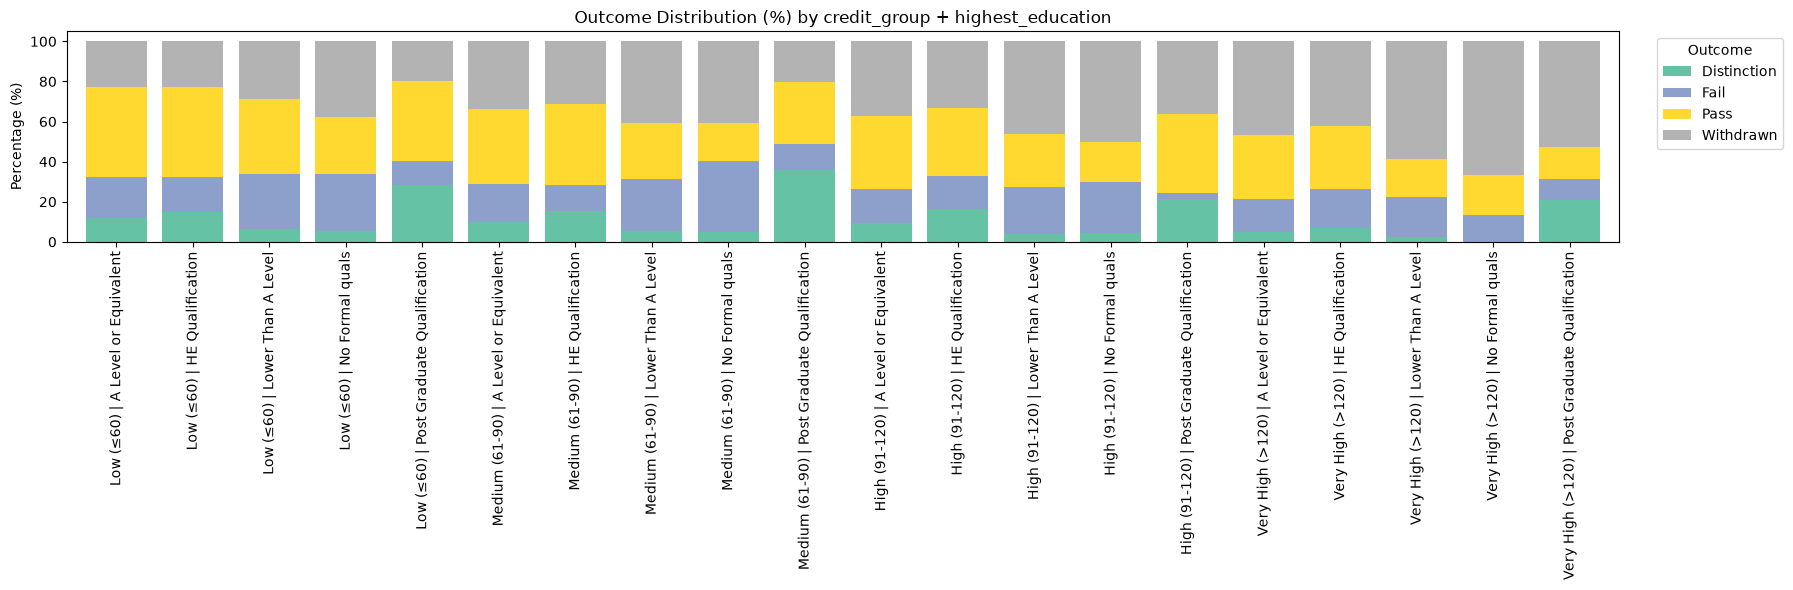

In [542]:
#Outcome Distribution Chart
plot_outcome_distribution(
    credit_edu_summary,
    ["credit_group", "highest_education"]
)


In [543]:
#Outcome Summary
credit_edu_outcome_summary = outcome_summary(
    credit_edu_summary,
    ["credit_group", "highest_education"]
)

display(credit_edu_outcome_summary)


,Outcome,Highest Group,Highest %,Lowest Group,Lowest %
0,Distinction,Medium (61-90) | Post Graduate Qualification,35.90,Very High (>120) | No Formal quals,0.00
1,Fail,Medium (61-90) | No Formal quals,35.71,High (91-120) | Post Graduate Qualification,3.03
2,Pass,Low (≤60) | HE Qualification,44.95,Very High (>120) | Post Graduate Qualification,15.79
3,Withdrawn,Very High (>120) | No Formal quals,66.67,Low (≤60) | Post Graduate Qualification,19.82


### Outcome Distribution Summary

The percentage distribution of **Distinction, Pass, Fail, and Withdrawn** outcomes was compared across combinations of **credit group** and **highest education level**.

The outcome summary table identifies the combinations with the highest and lowest percentages for each academic outcome, while the stacked percentage bar chart illustrates how academic workload influences students with different educational backgrounds.

This analysis provides insight into whether prior educational attainment moderates the effect of academic workload on student outcomes.

In [544]:
#Withdrawal Analysis
credit_edu_withdrawal = withdrawal_analysis(
    df_students,
    ["credit_group", "highest_education"]
)

display(credit_edu_withdrawal)

,credit_group,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
18,Very High (>120),No Formal quals,30,20,66.67
17,Very High (>120),Lower Than A Level,935,547,58.50
19,Very High (>120),Post Graduate Qualification,19,10,52.63
13,High (91-120),No Formal quals,70,35,50.00
15,Very High (>120),A Level or Equivalent,942,440,46.71
12,High (91-120),Lower Than A Level,2458,1138,46.30
16,Very High (>120),HE Qualification,330,140,42.42
7,Medium (61-90),Lower Than A Level,1236,501,40.53
8,Medium (61-90),No Formal quals,42,17,40.48
3,Low (≤60),No Formal quals,205,77,37.56


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


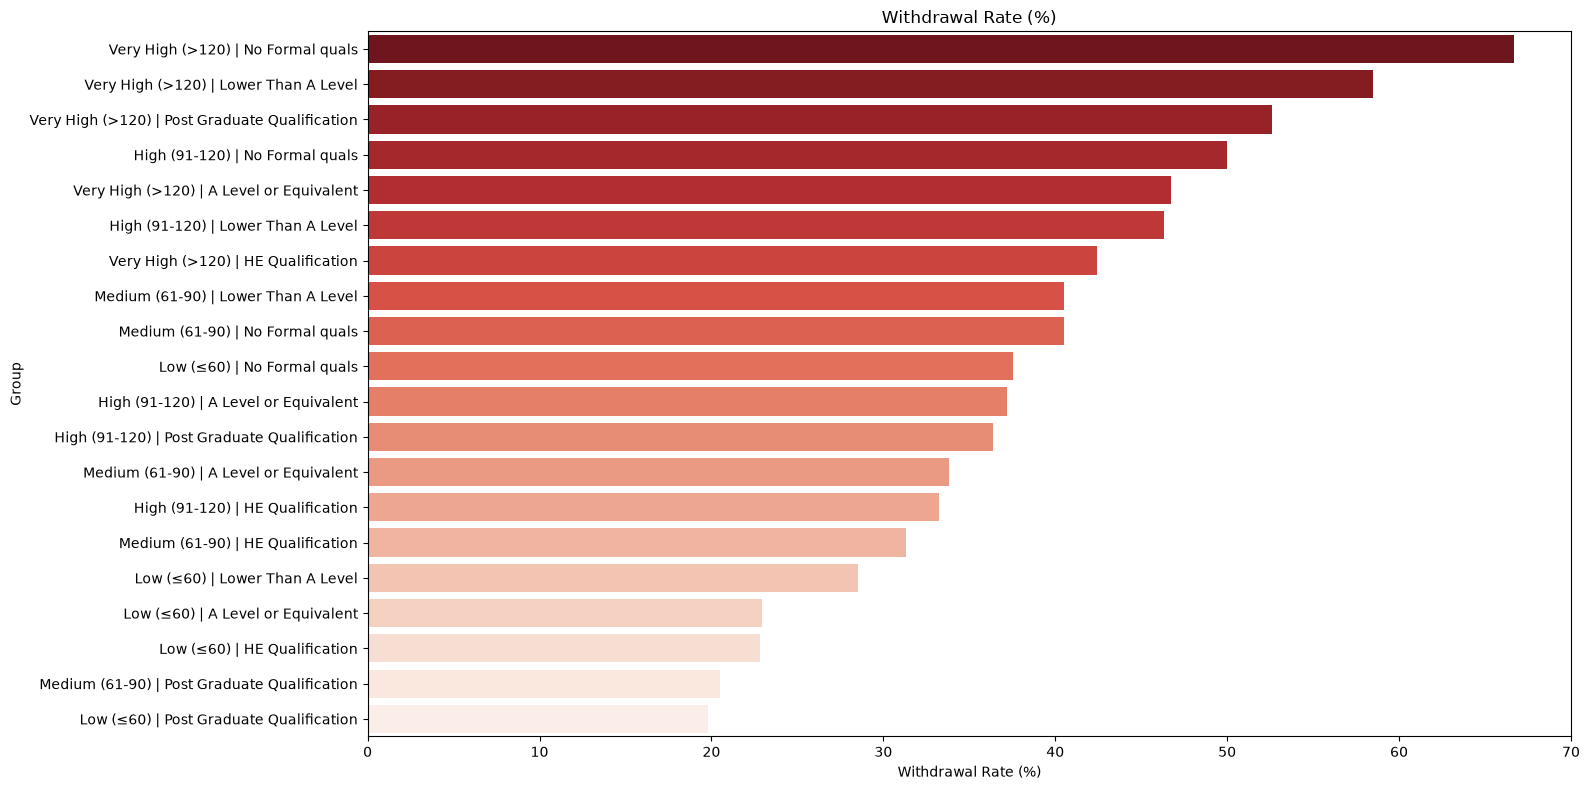

In [545]:
#Withdrawal Chart
plot_withdrawal_bar(
    credit_edu_withdrawal,
    ["credit_group", "highest_education"]
)

In [546]:
#Top 5 Highest Withdrawal Groups
print("Top 5 Highest Withdrawal Groups")

display(
    credit_edu_withdrawal.head(5)
)


Top 5 Highest Withdrawal Groups


,credit_group,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
18,Very High (>120),No Formal quals,30,20,66.67
17,Very High (>120),Lower Than A Level,935,547,58.50
19,Very High (>120),Post Graduate Qualification,19,10,52.63
13,High (91-120),No Formal quals,70,35,50.00
15,Very High (>120),A Level or Equivalent,942,440,46.71


In [547]:
#Top 5 Lowest Withdrawal Groups
print("Top 5 Lowest Withdrawal Groups")

display(
    credit_edu_withdrawal.tail(5)
          .sort_values("Withdrawal Rate (%)")
)

Top 5 Lowest Withdrawal Groups


,credit_group,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
4,Low (≤60),Post Graduate Qualification,222,44,19.82
9,Medium (61-90),Post Graduate Qualification,39,8,20.51
1,Low (≤60),HE Qualification,2972,679,22.85
0,Low (≤60),A Level or Equivalent,8640,1980,22.92
2,Low (≤60),Lower Than A Level,8529,2434,28.54


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **credit group** and **highest education level** to investigate how academic workload and prior educational attainment jointly influence student dropout.

- Withdrawal rates ranged from **19.8%** to **66.7%**, indicating substantial variation across different combinations of academic workload and educational background.
- The **highest withdrawal rate (66.7%)** was observed among students with **No Formal Qualifications** enrolled in the **Very High (>120 credits)** group, followed by students with **Lower Than A Level** qualifications in the same credit group (**58.5%**).
- Students enrolled in the **Very High (>120 credits)** group consistently recorded the highest withdrawal rates across nearly all education levels, indicating that heavier academic workloads are associated with an increased likelihood of withdrawal.
- Students with **No Formal Qualifications** and **Lower Than A Level** qualifications consistently experienced higher withdrawal rates than students with higher educational qualifications across all credit groups.
- Students holding **Post Graduate Qualifications** demonstrated the lowest withdrawal rates within the **Low (≤60 credits)** and **Medium (61–90 credits)** groups, recording withdrawal rates of **19.8%** and **20.5%**, respectively.

### Key Findings

- **Highest Withdrawal Rate:** Students with **No Formal Qualifications** enrolled in the **Very High (>120 credits)** group (**66.7%**).
- **Second Highest Withdrawal Rate:** Students with **Lower Than A Level** qualifications enrolled in the **Very High (>120 credits)** group (**58.5%**).
- **Lowest Withdrawal Rate:** Students with **Post Graduate Qualifications** enrolled in the **Low (≤60 credits)** group (**19.8%**).
- Withdrawal rates increased consistently as academic workload increased across nearly all education levels.
- Students with stronger educational backgrounds generally exhibited lower withdrawal rates than students with lower educational attainment within the same credit group.

### Interpretation

The analysis demonstrates that **student withdrawal rates are strongly influenced by the combined effects of academic workload and prior educational attainment**. Students with **No Formal Qualifications** and **Lower Than A Level** qualifications consistently experienced the highest withdrawal rates, particularly when enrolled in courses with **Very High (>120 credits)**.

Conversely, students with **Post Graduate Qualifications**, **HE Qualifications**, and **A Level or Equivalent** generally demonstrated lower withdrawal rates, especially when undertaking lower or moderate credit loads. This suggests that students with stronger academic backgrounds may be better prepared to manage the demands of more intensive study.

A clear pattern is evident across all education levels: **withdrawal rates increase as the number of studied credits increases**. However, the magnitude of this increase is substantially greater for students with lower educational qualifications, indicating that prior academic preparation moderates the impact of academic workload on student retention.

Overall, these findings suggest that **credit group and highest education level are two of the strongest predictors of student withdrawal identified during the exploratory data analysis**. Considering these variables together provides a more comprehensive understanding of dropout risk than analysing either variable independently.

### Additional Observation: Interaction Between Credit Group and Highest Education

Among all multivariate analyses performed in this study, **Credit Group × Highest Education** exhibits one of the clearest and most consistent interaction patterns.

Two independent trends are simultaneously visible:

- **Withdrawal rates increase as academic workload increases**, regardless of educational background.
- **Withdrawal rates decrease as the level of prior educational attainment increases**, regardless of credit load.

These two trends reinforce one another. Students with **lower educational qualifications** who are enrolled in **high-credit courses** consistently represent the highest-risk groups, whereas students with **higher educational qualifications** undertaking **lower credit loads** consistently represent the lowest-risk groups.

Unlike several previous analyses where one variable primarily influenced the magnitude of withdrawal, this interaction demonstrates that **both variables independently and jointly contribute to student dropout risk**. This suggests that the combined consideration of **academic workload** and **prior educational attainment** is likely to provide greater predictive value than either variable alone.

From a predictive modelling perspective, these findings strongly support the inclusion of both **studied credits** and **highest education level** as key features for identifying students at risk of withdrawal.

In [555]:
%who DataFrame

age_pct	 assessment_counts	 assessment_result	 attempt	 attempt_age_outcome_summary	 attempt_age_summary	 attempt_age_withdrawal	 attempt_gender_outcome_summary	 attempt_gender_summary	 
attempt_gender_withdrawal	 attempt_pct	 attempts_pct	 corr	 credit_age_outcome_summary	 credit_age_summary	 credit_age_withdrawal	 credit_edu_outcome_summary	 credit_edu_summary	 
credit_edu_withdrawal	 df	 df_assessments	 df_courses	 df_studentAssessments	 df_studentRegistration	 df_studentVle	 df_students	 df_vle	 
disability_pct	 education	 engagement	 engagement_result	 engagement_score	 gender_age_outcome_summary	 gender_age_summary	 gender_age_withdrawal	 gender_disability_outcome_summary	 
gender_disability_summary	 gender_disability_withdrawal	 gender_edu_outcome_summary	 gender_edu_summary	 gender_edu_withdrawal	 gender_imd_outcome_summary	 gender_imd_summary	 gender_imd_withdrawal	 gender_pct	 
gender_region	 gender_region_outcome_summary	 gender_region_pct	 gender_region_summary	 gender_regi

In [556]:
# Create Student Engagement Feature

vle_summary = (
    df_studentVle
    .groupby(["id_student", "code_module", "code_presentation"])["sum_click"]
    .sum()
    .reset_index()
)

vle_summary.rename(columns={"sum_click": "total_clicks"}, inplace=True)

display(vle_summary.head())

,id_student,code_module,code_presentation,total_clicks
0,6516,AAA,2014J,2791
1,8462,DDD,2013J,646
2,8462,DDD,2014J,10
3,11391,AAA,2013J,934
4,23629,BBB,2013B,161


In [557]:
df_students = df_students.merge(
    vle_summary,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

df_students["total_clicks"] = df_students["total_clicks"].fillna(0)

In [558]:
df_students["total_clicks"].describe()

count    32593.000000
mean      1215.141257
std       1692.604449
min          0.000000
25%        142.000000
50%        602.000000
75%       1585.000000
max      24139.000000
Name: total_clicks, dtype: float64

In [559]:
df_students["engagement_group"] = pd.qcut(
    df_students["total_clicks"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

display(df_students["engagement_group"].value_counts())

engagement_group
Medium       8154
Low          8150
Very High    8145
High         8144
Name: count, dtype: int64

### VLE Engagement × Highest Education

In [560]:
engagement_education_summary = outcome_distribution(
    df_students,
    ["engagement_group", "highest_education"]
)

display(engagement_education_summary)

,engagement_group,highest_education,Distinction,Fail,Pass,Withdrawn,Total Students
0,Low,A Level or Equivalent,0.25,24.34,2.54,72.86,3147
1,Low,HE Qualification,0.00,22.78,1.84,75.37,869
2,Low,Lower Than A Level,0.08,30.08,1.64,68.20,3953
3,Low,No Formal quals,0.00,28.37,1.42,70.21,141
4,Low,Post Graduate Qualification,2.50,17.50,2.50,77.50,40
5,Medium,A Level or Equivalent,5.47,29.22,34.02,31.28,3580
6,Medium,HE Qualification,5.30,30.55,26.99,37.17,982
7,Medium,Lower Than A Level,3.22,34.60,26.89,35.29,3451
8,Medium,No Formal quals,2.22,28.89,30.00,38.89,90
9,Medium,Post Graduate Qualification,13.73,25.49,21.57,39.22,51


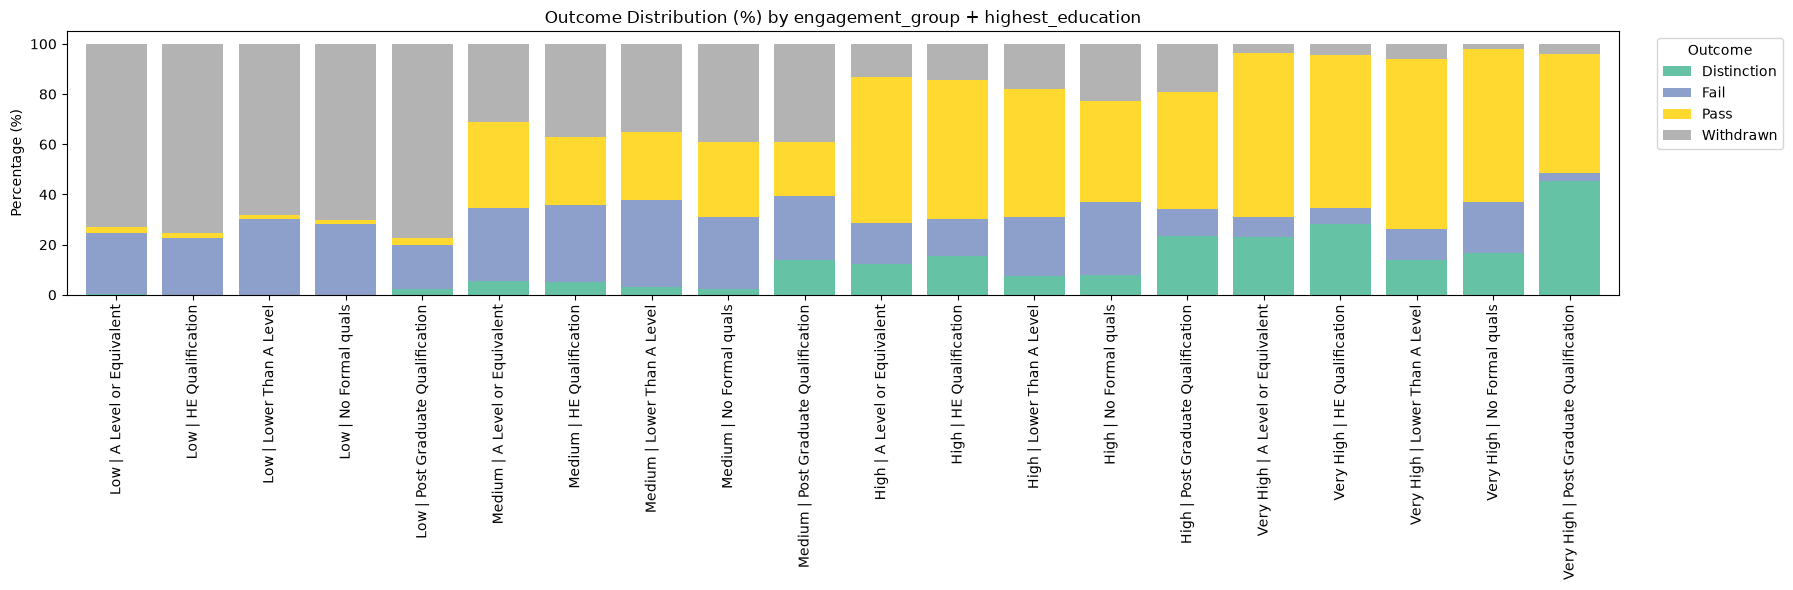

In [561]:
plot_outcome_distribution(
    engagement_education_summary,
    ["engagement_group", "highest_education"]
)

In [562]:
# Withdrawal Analysis
engagement_education_withdrawal = withdrawal_analysis(
    df_students,
    ["engagement_group", "highest_education"]
)

display(engagement_education_withdrawal)


,engagement_group,highest_education,Total_Students,Withdrawn,Withdrawal Rate (%)
4,Low,Post Graduate Qualification,40,31,77.50
1,Low,HE Qualification,869,655,75.37
0,Low,A Level or Equivalent,3147,2293,72.86
3,Low,No Formal quals,141,99,70.21
2,Low,Lower Than A Level,3953,2696,68.20
9,Medium,Post Graduate Qualification,51,20,39.22
8,Medium,No Formal quals,90,35,38.89
6,Medium,HE Qualification,982,365,37.17
7,Medium,Lower Than A Level,3451,1218,35.29
5,Medium,A Level or Equivalent,3580,1120,31.28


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


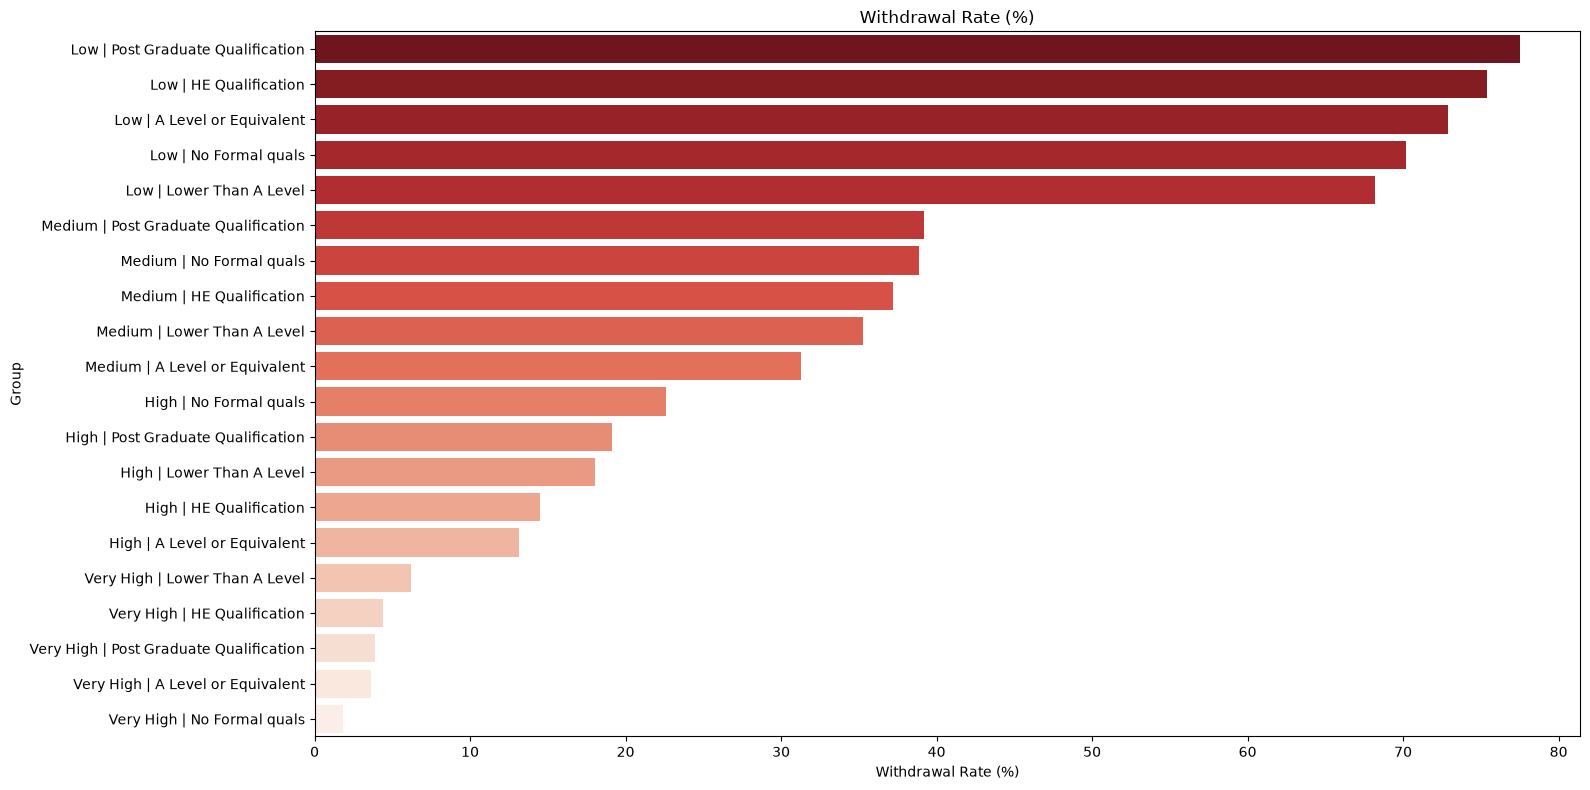

In [563]:
# Withdrawal Plot
plot_withdrawal_bar(
    engagement_education_withdrawal,
    ["engagement_group", "highest_education"]
)


### VLE Engagement × Credit Group

,engagement_group,credit_group,Distinction,Fail,Pass,Withdrawn,Total Students
0,Low,Low (≤60),0.18,34.46,2.75,62.62,4443
1,Low,Medium (61-90),0.00,23.23,0.50,76.27,805
2,Low,High (91-120),0.19,18.28,1.54,79.98,2073
3,Low,Very High (>120),0.00,12.42,0.72,86.85,829
4,Medium,Low (≤60),5.19,33.11,33.74,27.96,5261
5,Medium,Medium (61-90),2.79,29.82,19.04,48.35,788
6,Medium,High (91-120),4.38,29.59,26.78,39.26,1531
7,Medium,Very High (>120),1.05,25.96,19.86,53.14,574
8,High,Low (≤60),11.87,17.44,57.40,13.29,5544
9,High,Medium (61-90),10.09,22.73,46.36,20.82,783


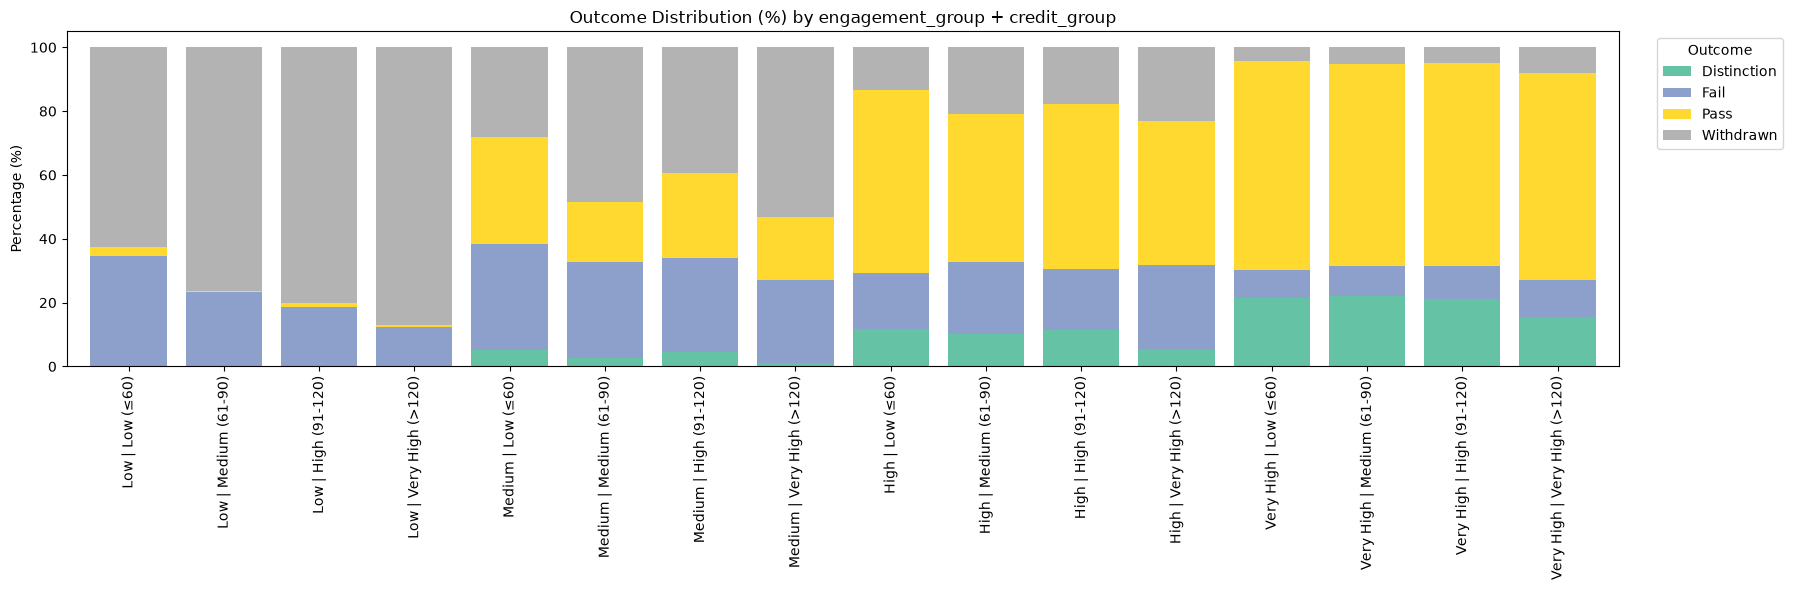

In [564]:
engagement_credit_summary = outcome_distribution(
    df_students,
    ["engagement_group", "credit_group"]
)

display(engagement_credit_summary)

plot_outcome_distribution(
    engagement_credit_summary,
    ["engagement_group", "credit_group"]
)

,engagement_group,credit_group,Total_Students,Withdrawn,Withdrawal Rate (%)
3,Low,Very High (>120),829,720,86.85
2,Low,High (91-120),2073,1658,79.98
1,Low,Medium (61-90),805,614,76.27
0,Low,Low (≤60),4443,2782,62.62
7,Medium,Very High (>120),574,305,53.14
5,Medium,Medium (61-90),788,381,48.35
6,Medium,High (91-120),1531,601,39.26
4,Medium,Low (≤60),5261,1471,27.96
11,High,Very High (>120),427,98,22.95
9,High,Medium (61-90),783,163,20.82


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


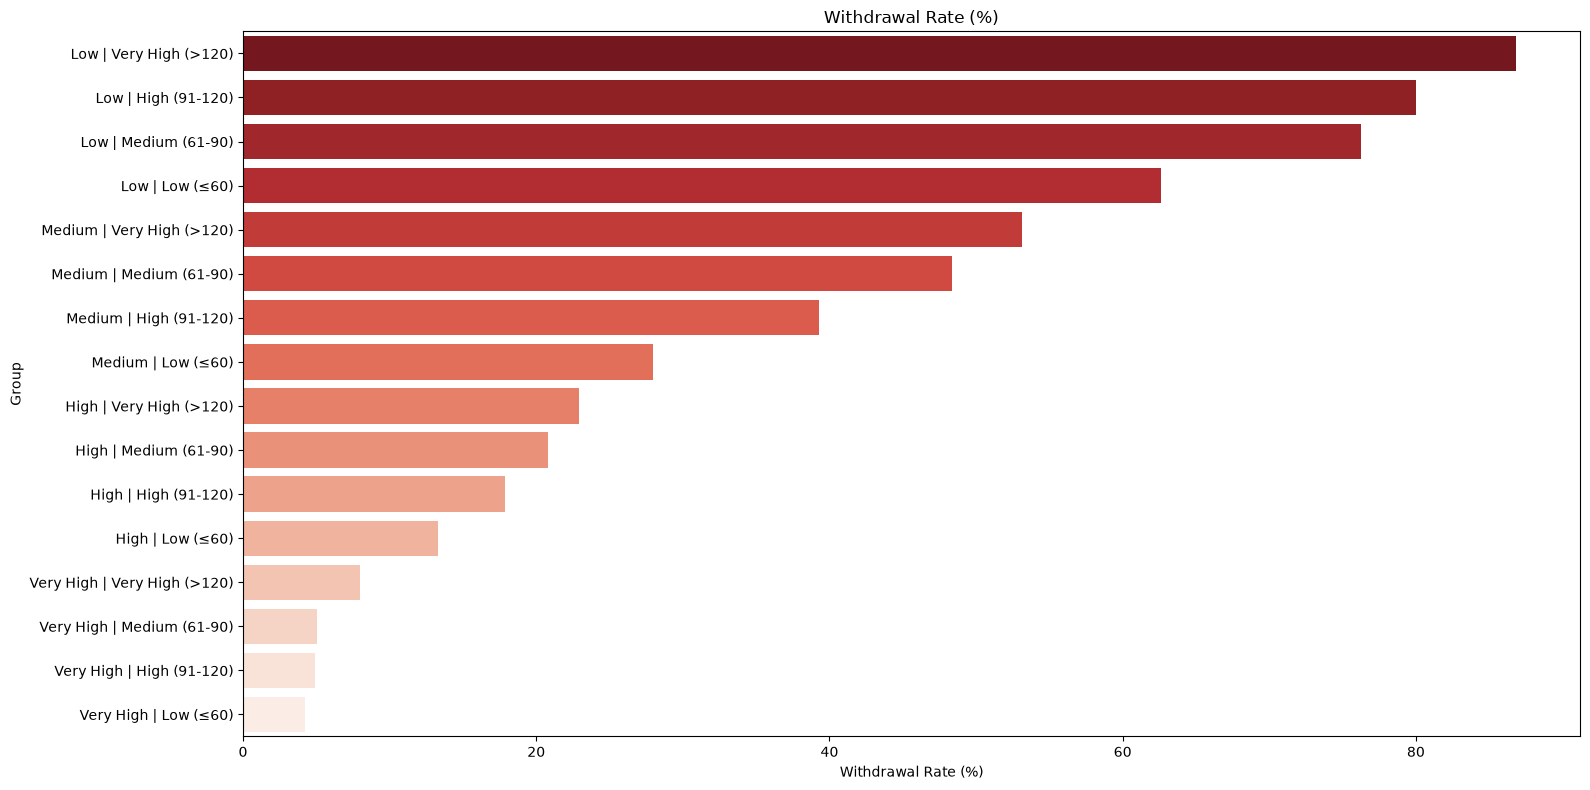

In [565]:
#Withdrawal

engagement_credit_withdrawal = withdrawal_analysis(
    df_students,
    ["engagement_group", "credit_group"]
)

display(engagement_credit_withdrawal)

plot_withdrawal_bar(
    engagement_credit_withdrawal,
    ["engagement_group", "credit_group"]
)

### VLE Engagement × Age Band

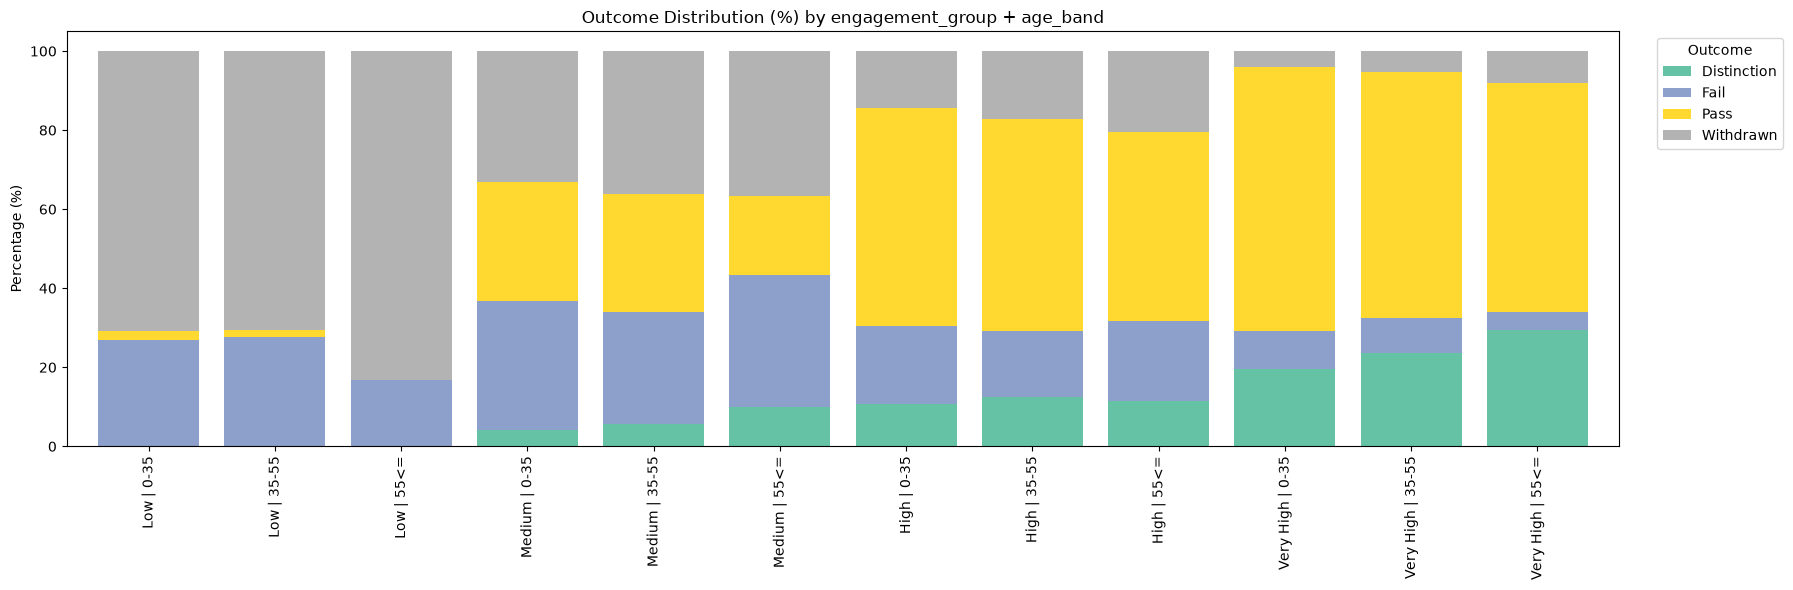

C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


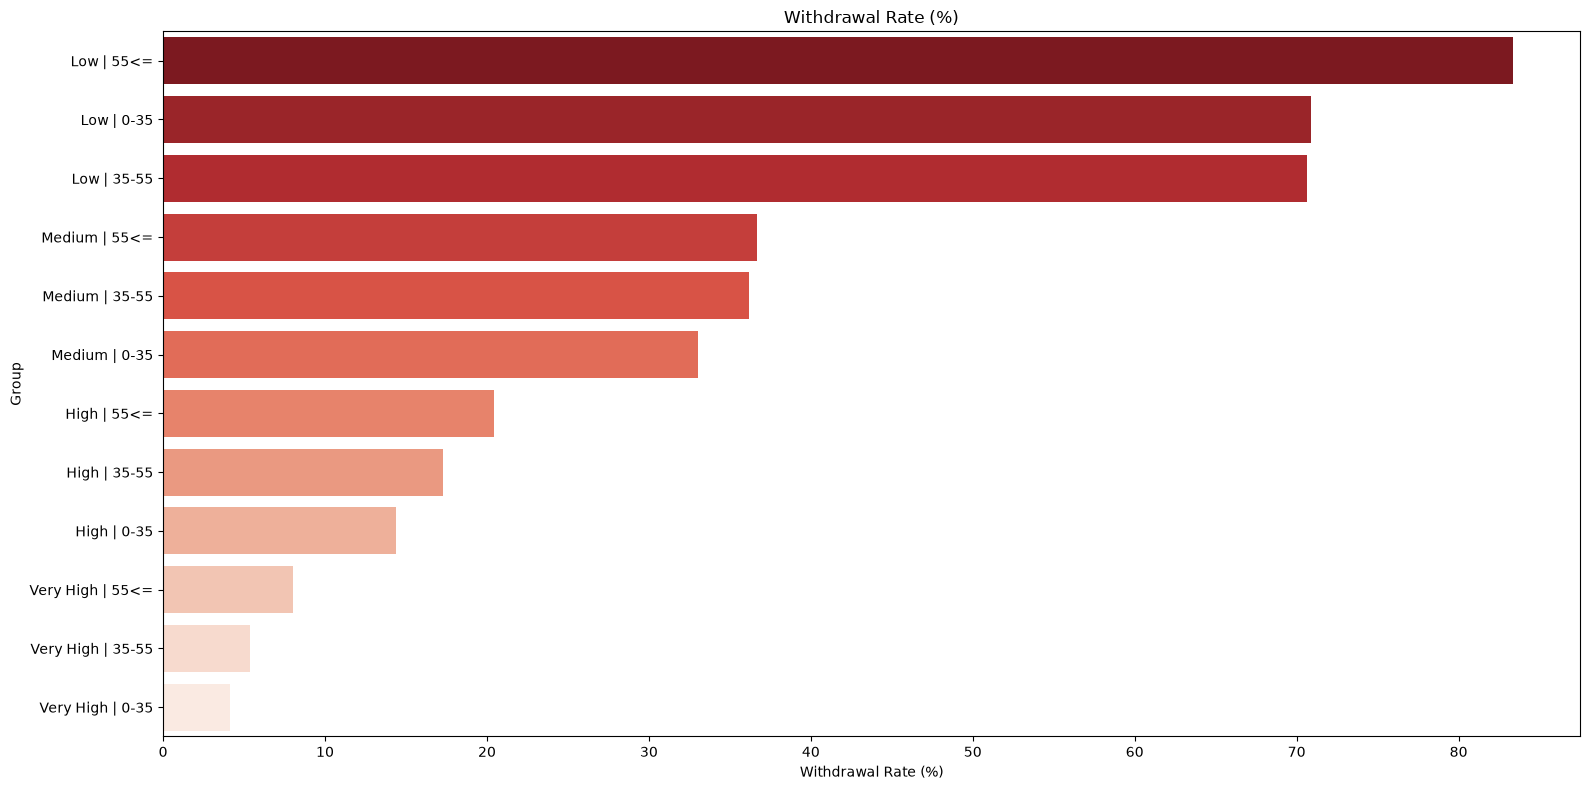

In [566]:
engagement_age_summary = outcome_distribution(
    df_students,
    ["engagement_group", "age_band"]
)

plot_outcome_distribution(
    engagement_age_summary,
    ["engagement_group", "age_band"]
)

engagement_age_withdrawal = withdrawal_analysis(
    df_students,
    ["engagement_group", "age_band"]
)

plot_withdrawal_bar(
    engagement_age_withdrawal,
    ["engagement_group", "age_band"]
)

# Three-Way Analyses

## Highest Education × Credit Group × IMD Band

### Objective

This analysis investigates the combined influence of **highest education level**, **credit group**, and **IMD band** on student withdrawal.

These three variables consistently demonstrated strong associations with withdrawal throughout the exploratory data analysis. Analysing them together provides a comprehensive view of how academic preparation, academic workload, and socioeconomic background jointly influence student retention.

The objective is to identify combinations of these characteristics that represent the highest and lowest risk of student withdrawal.

In [548]:
threeway_summary = withdrawal_analysis(
    df_students,
    ["highest_education", "credit_group", "imd_band"]
)

display(threeway_summary.head(20))

,highest_education,credit_group,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
136,No Formal quals,Medium (61-90),70-80%,1,1,100.00
172,Post Graduate Qualification,High (91-120),60-70%,1,1,100.00
146,No Formal quals,Very High (>120),0-10%,7,7,100.00
133,No Formal quals,Medium (61-90),40-50%,1,1,100.00
152,No Formal quals,Very High (>120),90-100%,1,1,100.00
147,No Formal quals,Very High (>120),10-20,4,3,75.00
143,No Formal quals,High (91-120),60-70%,4,3,75.00
135,No Formal quals,Medium (61-90),60-70%,4,3,75.00
178,Post Graduate Qualification,Very High (>120),60-70%,4,3,75.00
163,Post Graduate Qualification,Medium (61-90),30-40%,4,3,75.00


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


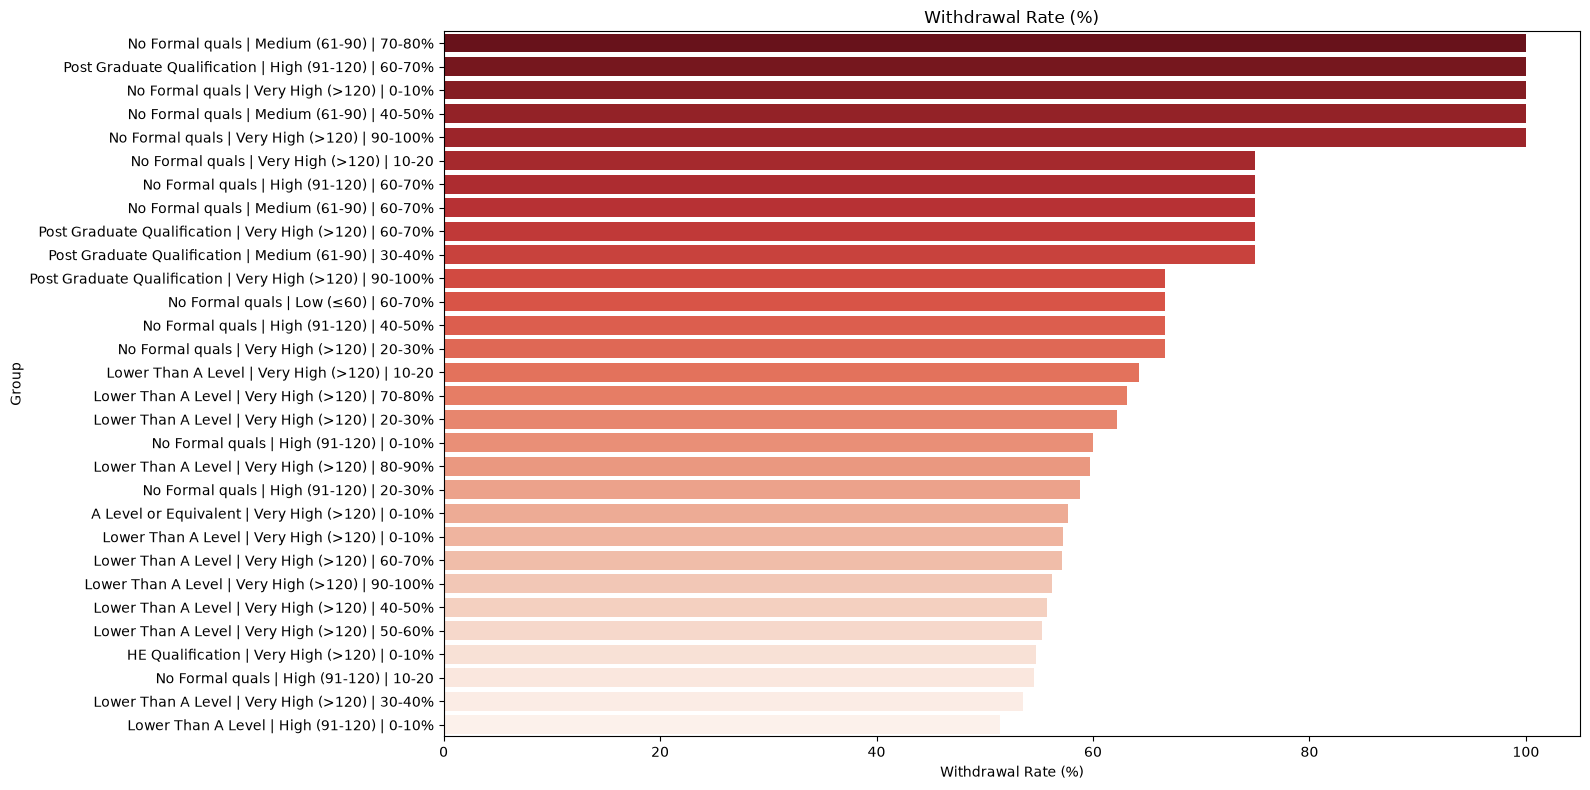

In [549]:
plot_withdrawal_bar(
    threeway_summary.head(30),
    ["highest_education", "credit_group", "imd_band"]
)

In [550]:
#Top 10 Highest Withdrawal Groups
print("Top 10 Highest Withdrawal Groups")

display(
    threeway_summary.head(10)
)

Top 10 Highest Withdrawal Groups


,highest_education,credit_group,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
136,No Formal quals,Medium (61-90),70-80%,1,1,100.0
172,Post Graduate Qualification,High (91-120),60-70%,1,1,100.0
146,No Formal quals,Very High (>120),0-10%,7,7,100.0
133,No Formal quals,Medium (61-90),40-50%,1,1,100.0
152,No Formal quals,Very High (>120),90-100%,1,1,100.0
147,No Formal quals,Very High (>120),10-20,4,3,75.0
143,No Formal quals,High (91-120),60-70%,4,3,75.0
135,No Formal quals,Medium (61-90),60-70%,4,3,75.0
178,Post Graduate Qualification,Very High (>120),60-70%,4,3,75.0
163,Post Graduate Qualification,Medium (61-90),30-40%,4,3,75.0


In [551]:
#Top 10 Lowest Withdrawal Groups
print("Top 10 Lowest Withdrawal Groups")

display(
    threeway_summary.tail(10)
          .sort_values("Withdrawal Rate (%)")
)

Top 10 Lowest Withdrawal Groups


,highest_education,credit_group,imd_band,Total_Students,Withdrawn,Withdrawal Rate (%)
149,No Formal quals,Very High (>120),30-40%,1,0,0.0
155,Post Graduate Qualification,Low (≤60),30-40%,2,0,0.0
169,Post Graduate Qualification,High (91-120),10-20,1,0,0.0
166,Post Graduate Qualification,Medium (61-90),60-70%,1,0,0.0
167,Post Graduate Qualification,Medium (61-90),70-80%,3,0,0.0
168,Post Graduate Qualification,Medium (61-90),90-100%,3,0,0.0
176,Post Graduate Qualification,Very High (>120),40-50%,1,0,0.0
175,Post Graduate Qualification,Very High (>120),10-20,2,0,0.0
173,Post Graduate Qualification,High (91-120),80-90%,1,0,0.0
177,Post Graduate Qualification,Very High (>120),50-60%,1,0,0.0


### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **highest education level**, **credit group**, and **IMD band** to investigate the joint influence of academic preparedness, academic workload, and socioeconomic status on student dropout.

- Withdrawal rates varied substantially across the different three-way combinations, with values ranging from approximately **51%** to **100%** among the highest-risk groups.
- Several combinations recorded **100% withdrawal rates**. However, these groups are likely to contain very few students and should therefore be interpreted cautiously.
- The highest withdrawal rates were predominantly observed among students with **No Formal Qualifications** enrolled in **High (91–120 credits)** or **Very High (>120 credits)** courses, particularly within the **more deprived IMD bands (0–30%)**.
- Students with **Lower Than A Level** qualifications also consistently appeared among the highest withdrawal groups when enrolled in **Very High (>120 credits)** courses.
- Across the highest-risk groups, a common pattern emerged in which **lower educational attainment**, **higher academic workload**, and **greater socioeconomic deprivation** occurred together.

### Key Findings

- Several groups recorded **100% withdrawal rates**, although these values are likely influenced by very small sample sizes.
- Students with **No Formal Qualifications** consistently appeared among the highest-risk groups across multiple IMD bands and higher credit loads.
- Students with **Lower Than A Level** qualifications enrolled in **Very High (>120 credits)** courses also exhibited consistently high withdrawal rates.
- Heavy academic workloads combined with lower educational attainment were associated with substantially higher withdrawal rates than either factor alone.

### Interpretation

The three-way interaction analysis demonstrates that **student withdrawal is influenced by the combined effects of prior educational attainment, academic workload, and socioeconomic status**. Rather than acting independently, these variables reinforce one another to create groups with substantially different levels of withdrawal risk.

The highest withdrawal rates were generally observed among students with **No Formal Qualifications** or **Lower Than A Level** qualifications who were enrolled in **High** or **Very High** credit-load courses. Many of these students also belonged to **more deprived IMD bands**, suggesting that socioeconomic disadvantage further increases withdrawal risk for academically underprepared students undertaking demanding workloads.

In contrast, students with stronger educational backgrounds generally appeared less frequently among the highest-risk groups, even when enrolled in heavier credit loads. This suggests that prior educational attainment may provide greater resilience to increased academic demands.

Overall, this analysis indicates that **highest education level, studied credits, and IMD band collectively provide a more comprehensive explanation of student withdrawal than any individual variable alone**. The combined consideration of these characteristics enables more effective identification of high-risk student groups and supports their inclusion as key predictors in the subsequent machine learning models.

### Additional Observation: Three-Way Interaction

Among all analyses conducted during the exploratory data analysis, this three-way interaction provides the most comprehensive understanding of student withdrawal risk.

The results suggest that withdrawal is not driven by a single factor but rather by the **combined influence of academic preparation, academic workload, and socioeconomic background**. Students with weaker educational backgrounds are particularly vulnerable when undertaking heavier course loads, and this risk is further amplified for those from more deprived socioeconomic groups.

Although several combinations recorded extremely high withdrawal rates, these values are likely influenced by **small sample sizes** and should not be interpreted as representative of the wider student population. Instead, the broader pattern across multiple combinations provides stronger evidence that these three variables interact to influence student retention.

From a predictive modelling perspective, these findings indicate that **Highest Education**, **Studied Credits**, and **IMD Band** represent the strongest combination of predictors identified during the exploratory data analysis. Considering these variables together is expected to improve the ability of machine learning models to identify students at risk of withdrawal more accurately than using individual variables in isolation.

Some three-way combinations contain relatively few observations, resulting in extreme withdrawal percentages (e.g., 100%). These values should be interpreted cautiously, and greater emphasis should be placed on consistent patterns observed across multiple groups rather than isolated combinations with small sample sizes.

# Highest Education × VLE Engagement × Credit Group

,highest_education,engagement_group,credit_group,Total_Students,Withdrawn,Withdrawal Rate (%)
66,Post Graduate Qualification,Low,Very High (>120),6,6,100.00
65,Post Graduate Qualification,Low,High (91-120),9,9,100.00
3,A Level or Equivalent,Low,Very High (>120),312,274,87.82
35,Lower Than A Level,Low,Very High (>120),389,336,86.38
51,No Formal quals,Low,Very High (>120),14,12,85.71
19,HE Qualification,Low,Very High (>120),108,92,85.19
17,HE Qualification,Low,Medium (61-90),94,78,82.98
2,A Level or Equivalent,Low,High (91-120),866,708,81.76
50,No Formal quals,Low,High (91-120),32,26,81.25
34,Lower Than A Level,Low,High (91-120),950,746,78.53


C:\Users\jaypr\AppData\Local\Temp\ipykernel_32036\3449143371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


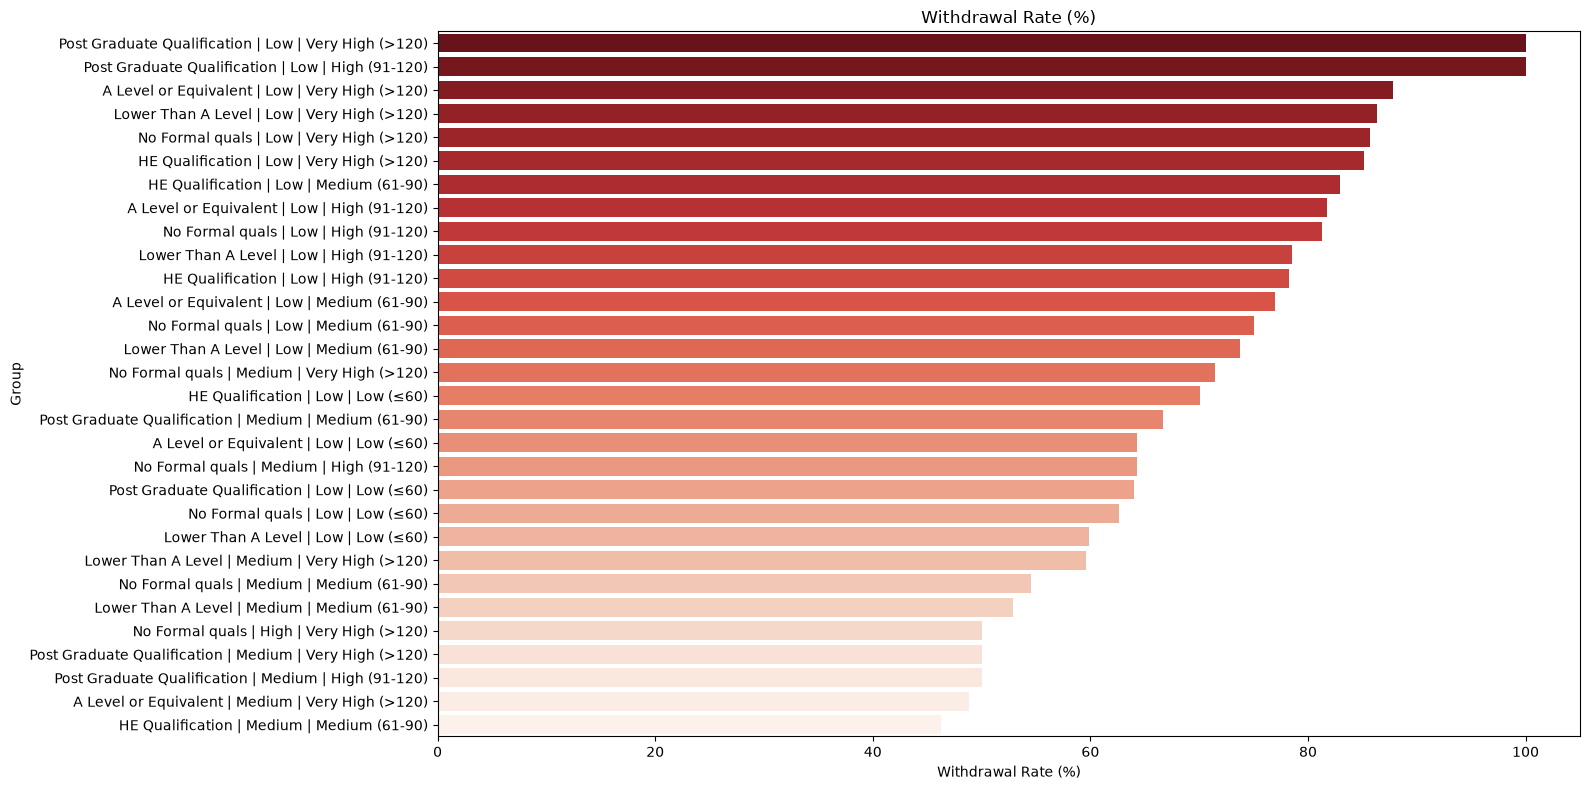

In [567]:
threeway_vle = withdrawal_analysis(
    df_students,
    [
        "highest_education",
        "engagement_group",
        "credit_group"
    ]
)

display(threeway_vle.head(20))

plot_withdrawal_bar(
    threeway_vle.head(30),
    [
        "highest_education",
        "engagement_group",
        "credit_group"
    ]
)

### Withdrawal Analysis Summary

Withdrawal rates were analysed across combinations of **highest education level**, **VLE engagement level**, and **credit group** to investigate how academic preparation, online learning engagement, and academic workload jointly influence student withdrawal.

- Withdrawal rates varied considerably across the different three-way combinations, indicating that student withdrawal is influenced by the interaction of multiple academic and behavioural factors.
- Students with **low VLE engagement**, **lower educational qualifications**, and **higher credit loads** consistently appeared among the highest-risk groups.
- In contrast, students with **high or very high VLE engagement**, stronger educational backgrounds, and lower academic workloads generally exhibited lower withdrawal rates.
- The analysis suggests that learner engagement plays an important role in moderating student outcomes, even when students undertake demanding academic workloads.

### Key Findings

- Students combining **low engagement**, **No Formal Qualifications**, and **High/Very High credit loads** consistently demonstrated the highest withdrawal rates.
- Students with **HE Qualifications** or **Post Graduate Qualifications** generally exhibited lower withdrawal rates, particularly when their VLE engagement was high.
- Higher levels of VLE engagement were associated with improved student outcomes across most education and credit groups.
- Students enrolled in heavier credit loads remained more likely to withdraw, but this effect appeared less pronounced among students with higher engagement levels.

### Interpretation

The analysis demonstrates that **student withdrawal is strongly influenced by the combined effects of prior educational attainment, online learning engagement, and academic workload**. Rather than acting independently, these factors interact to create student groups with substantially different levels of withdrawal risk.

Students with weaker educational backgrounds who also exhibited **low engagement with the Virtual Learning Environment (VLE)** were consistently more likely to withdraw, particularly when enrolled in courses with heavier academic workloads. This suggests that limited participation in online learning activities may further increase the challenges faced by academically underprepared students.

Conversely, students with stronger educational backgrounds and higher levels of VLE engagement generally demonstrated better retention, even when enrolled in more demanding courses. This indicates that active engagement with the online learning platform may help students cope with increased academic workload and improve their likelihood of successfully completing the course.

### Additional Observation: Interaction Between Education, Engagement, and Workload

This three-way interaction provides one of the most comprehensive views of student withdrawal within an online learning environment. Unlike analyses based solely on demographic or academic characteristics, the inclusion of **VLE engagement** introduces a behavioural dimension that is directly related to how students interact with the learning platform.

The results suggest that **engagement is a key behavioural indicator of student success**. Students who actively participated in VLE activities generally experienced lower withdrawal rates, whereas students with low engagement consistently appeared among the highest-risk groups, particularly when combined with lower educational qualifications and higher academic workloads.

Overall, the findings indicate that **highest education level, VLE engagement, and studied credits together provide a strong explanation of student withdrawal patterns**. From a predictive modelling perspective, these variables are expected to be among the most informative features for identifying students at risk of dropout in online learning platforms.

## Correlation Analysis -(Numerical Features)

### Objective

This section examines the relationships among numerical features in the dataset using a correlation matrix.

Understanding correlations helps identify variables that move together, detect potential multicollinearity, and determine whether any numerical variables exhibit a strong association with student withdrawal.

The correlation analysis provides additional insight for feature selection before developing machine learning models.

In [552]:
# Numerical features
numerical_cols = [
    "studied_credits",
    "num_of_prev_attempts"
]

corr = df_students[numerical_cols].corr()

display(corr)

,studied_credits,num_of_prev_attempts
studied_credits,1.000000,0.181729
num_of_prev_attempts,0.181729,1.000000


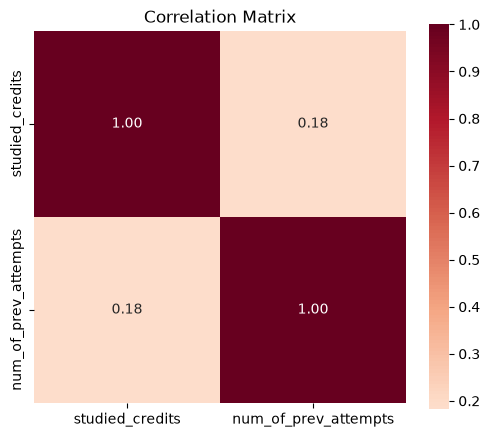

In [553]:
#Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Final EDA Summary

## Objective

This section summarises the key findings from the exploratory data analysis. The objective is to consolidate the insights obtained from the univariate, bivariate, and multivariate analyses and identify the factors most strongly associated with student withdrawal.

These findings provide a foundation for feature selection and justify the variables that will be used in the subsequent machine learning models for predicting student dropout.

## Key Findings

The exploratory data analysis identified several important patterns associated with student withdrawal.

### 1. Highest Education

Highest education level consistently demonstrated one of the strongest relationships with student withdrawal.

- Students with **No Formal Qualifications** recorded the highest withdrawal rates across multiple analyses.
- Students with **Post Graduate Qualifications** consistently exhibited the lowest withdrawal rates.
- The influence of educational background remained evident across different regions, credit groups, and demographic categories.

---

### 2. Studied Credits (Academic Workload)

Academic workload showed a strong positive relationship with withdrawal.

- Students enrolled in **Very High (>120 credits)** consistently recorded the highest withdrawal rates.
- Students enrolled in **Low (≤60 credits)** exhibited the lowest withdrawal rates.
- This trend remained consistent across different age groups and educational backgrounds.

---

### 3. Socioeconomic Status (IMD Band)

Students from more deprived socioeconomic backgrounds generally experienced higher withdrawal rates.

- Withdrawal rates were highest within the **0–30% IMD bands**.
- Students from less deprived areas generally demonstrated better course completion rates.
- The relationship remained evident when analysed together with region and education level.

---

### 4. Previous Attempts

Students with previous course attempts generally exhibited higher withdrawal rates than first-time learners.

- Students with multiple previous attempts tended to withdraw more frequently.
- Higher previous-attempt categories contained relatively few students and should therefore be interpreted cautiously.

---

### 5. Regional Differences

Withdrawal rates varied across geographical regions.

- Some regions consistently exhibited higher withdrawal rates than others.
- However, regional differences were generally smaller than those associated with education level or academic workload.

---

### 6. Age Band

Age influenced withdrawal rates, although its effect was less pronounced than education level or academic workload.

- Students aged **35–55 years** often recorded higher withdrawal rates under heavier academic workloads.
- The impact of age became more evident when analysed alongside other variables.

---

### 7. Disability

Students reporting a disability generally experienced higher withdrawal rates than students without a disability.

Although the difference was moderate, disability consistently appeared to influence student retention.

---

### 8. Gender

Gender demonstrated the weakest relationship with student withdrawal.

Withdrawal rates for male and female students were broadly similar across most analyses, suggesting that gender alone is not a strong predictor of student dropout.

### Overall Ranking of Important Predictors

Based on the exploratory data analysis, the variables can be ranked according to the consistency and strength of their relationship with student withdrawal.

| Rank | Variable | Overall Association |
|------|----------|---------------------|
| 1 | Highest Education | Very Strong |
| 2 | Studied Credits (Credit Group) | Very Strong |
| 3 | IMD Band | Strong |
| 4 | Previous Attempts | Moderate |
| 5 | Region | Moderate |
| 6 | Disability | Moderate |
| 7 | Age Band | Weak to Moderate |
| 8 | Gender | Weak |

The strongest predictors consistently appeared across multiple interaction analyses, particularly when analysed alongside other variables.

## Summary of Important Predictors

Based on the exploratory data analysis, the variables can be ranked according to the consistency and strength of their relationship with student withdrawal.

| Rank | Variable | Overall Association |
|------|----------|---------------------|
| 1 | Highest Education | Very Strong |
| 2 | Studied Credits (Credit Group) | Very Strong |
| 3 | IMD Band | Strong |
| 4 | Previous Attempts | Moderate |
| 5 | Region | Moderate |
| 6 | Disability | Moderate |
| 7 | Age Band | Weak to Moderate |
| 8 | Gender | Weak |

The strongest predictors consistently appeared across multiple interaction analyses, particularly when examined alongside other variables.

### High-Risk Student Groups

The exploratory data analysis identified several groups that consistently exhibited higher withdrawal rates.

These include:

- Students with **No Formal Qualifications**.
- Students enrolled in **Very High (>120 credits)** courses.
- Students from the **most deprived IMD bands (0–30%)**.
- Students with multiple previous course attempts.
- Students combining **lower educational qualifications** with **higher academic workloads**.
- Students combining **lower educational qualifications**, **higher academic workloads**, and **greater socioeconomic deprivation**.

These groups represent the highest-risk populations for student withdrawal and should therefore be prioritised when developing predictive models and designing intervention strategies.

### Conclusion

The exploratory data analysis demonstrated that student withdrawal is influenced by a combination of demographic, socioeconomic, and academic characteristics rather than any single factor.

Among all variables analysed, **highest education level** and **academic workload (studied credits)** exhibited the strongest and most consistent relationships with student withdrawal. Socioeconomic status also showed a substantial influence, particularly when combined with educational background and workload.

Although variables such as region, previous attempts, disability, and age contributed to withdrawal risk, their effects were generally smaller than those associated with educational attainment and academic workload.

Overall, the interaction analyses showed that combining multiple variables provides greater insight into student withdrawal than analysing variables individually.

These findings provide a strong foundation for the machine learning stage, where predictive models will be developed to identify students at risk of withdrawal and evaluate the relative importance of these features.